In [ ]:
# ============================================================
# GOOGLE DRIVE - SAFE MOUNT
# ============================================================

import os
from pathlib import Path
from google.colab import drive

DRIVE_PATH = Path("/content/drive")
MYDRIVE_PATH = DRIVE_PATH / "MyDrive"

# Cek apakah Drive sudah ter-mount
if MYDRIVE_PATH.exists():

    print("Google Drive sudah ter-mount.")
    print("MyDrive:", MYDRIVE_PATH)

else:

    print("Google Drive belum ter-mount.")

    # Jika /content/drive sudah berisi sesuatu,
    # gunakan mountpoint alternatif agar tidak error
    if DRIVE_PATH.exists() and len(os.listdir(DRIVE_PATH)) > 0:

        print(
            "/content/drive sudah berisi file."
        )

        print(
            "Mount menggunakan /content/gdrive ..."
        )

        drive.mount(
            "/content/gdrive"
        )

        MYDRIVE_PATH = Path(
            "/content/gdrive/MyDrive"
        )

    else:

        drive.mount(
            "/content/drive"
        )

        MYDRIVE_PATH = Path(
            "/content/drive/MyDrive"
        )


print("\nDrive aktif:")
print(MYDRIVE_PATH)


# Folder penelitian
BASE_DIR = (
    MYDRIVE_PATH
    /
    "GEE"
)

print("\nFolder GEE:")
print(BASE_DIR)

print(
    "\nFolder GEE tersedia:",
    BASE_DIR.exists()
)

Google Drive belum ter-mount.
Mounted at /content/drive

Drive aktif:
/content/drive/MyDrive

Folder GEE:
/content/drive/MyDrive/GEE

Folder GEE tersedia: True


In [ ]:
# ============================================================
# FASE 3D-A FINAL
# AUDIT + DOWNLOAD SUMBER DATA RESMI
# BAWANG MERAH NGANJUK 2025
#
# TUJUAN:
# 1. Safe mount Google Drive
# 2. Membaca ROI penelitian
# 3. Mengecek Dynamic World Jul-Aug 2025
# 4. Mengambil polygon SIMOTANDI Kementan jika tersedia
# 5. Mengambil polygon Bawang Merah Kementan jika tersedia
# 6. Mencoba download Satu Data Nganjuk 2025
# 7. Menyimpan semua sumber yang berhasil diperoleh
#
# BELUM TRAINING MODEL
# ============================================================


# ============================================================
# 0. INSTALL LIBRARY
# ============================================================

!pip -q install geopandas requests beautifulsoup4 openpyxl


# ============================================================
# 1. IMPORT
# ============================================================

import os
import re
import json
import math
import requests
import pandas as pd
import geopandas as gpd
import ee

from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from google.colab import drive
from IPython.display import display


# ============================================================
# 2. SAFE MOUNT GOOGLE DRIVE
# ============================================================

print(
    "=============================================="
)

print(
    "GOOGLE DRIVE"
)

print(
    "=============================================="
)


DRIVE_1 = Path(
    "/content/drive/MyDrive"
)

DRIVE_2 = Path(
    "/content/gdrive/MyDrive"
)


# ------------------------------------------------------------
# A. Drive sudah mounted di /content/drive
# ------------------------------------------------------------

if DRIVE_1.exists():

    MYDRIVE_PATH = DRIVE_1

    print(
        "Google Drive sudah ter-mount."
    )

    print(
        "Path:",
        MYDRIVE_PATH
    )


# ------------------------------------------------------------
# B. Drive sudah mounted di /content/gdrive
# ------------------------------------------------------------

elif DRIVE_2.exists():

    MYDRIVE_PATH = DRIVE_2

    print(
        "Google Drive sudah ter-mount."
    )

    print(
        "Path:",
        MYDRIVE_PATH
    )


# ------------------------------------------------------------
# C. Belum mounted
# ------------------------------------------------------------

else:

    default_mount = Path(
        "/content/drive"
    )


    # Kalau /content/drive sudah berisi file,
    # jangan paksa mount di sana
    if (
        default_mount.exists()
        and
        len(
            list(
                default_mount.iterdir()
            )
        ) > 0
    ):

        mount_point = (
            "/content/gdrive"
        )

    else:

        mount_point = (
            "/content/drive"
        )


    print(
        "Google Drive belum ter-mount."
    )

    print(
        "Mount ke:",
        mount_point
    )


    drive.mount(
        mount_point
    )


    MYDRIVE_PATH = (
        Path(
            mount_point
        )
        /
        "MyDrive"
    )


# ============================================================
# 3. FOLDER PENELITIAN
# ============================================================

BASE_DIR = (
    MYDRIVE_PATH
    /
    "GEE"
)


BASE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SOURCE_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


SOURCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\nFolder penelitian:"
)

print(
    BASE_DIR
)


print(
    "\nFolder sumber resmi:"
)

print(
    SOURCE_DIR
)


# ============================================================
# 4. PATH DATA PENELITIAN
# ============================================================

QC_SITE_PATH = (
    BASE_DIR
    /
    "qc_reference_site_nganjuk_v4.csv"
)


PROJECT_ID = (
    "risetbawang"
)


# ============================================================
# 5. URL SUMBER RESMI
# ============================================================

# ------------------------------------------------------------
# SIMOTANDI KEMENTAN
# ------------------------------------------------------------

SIMOTANDI_LAYER_URL = (
    "https://geoportal.pertanian.go.id/"
    "arcgis/rest/services/SIMOTANDI/"
    "FeatureServer/0"
)


# ------------------------------------------------------------
# BAWANG MERAH KEMENTAN
# ------------------------------------------------------------

BAWANG_LAYER_URL = (
    "https://geoportal.pertanian.go.id/"
    "arcgis/rest/services/BawangMerah/"
    "FeatureServer/0"
)


# ------------------------------------------------------------
# SATU DATA KABUPATEN NGANJUK
# ------------------------------------------------------------

SATUDATA_URL = (
    "https://dashboard.nganjukkab.go.id/"
    "menudataset/detail?"
    "data=NjRlZTYwNzMtOTk4Yi00MDE4LWEyNWEtOWE5NjE3YjBmMzc4"
)


# ============================================================
# 6. VALIDASI QC FILE
# ============================================================

print(
    "\n=============================================="
)

print(
    "VALIDASI DATA PENELITIAN"
)

print(
    "=============================================="
)


if not QC_SITE_PATH.exists():

    raise FileNotFoundError(
        "\nFile QC tidak ditemukan:\n"
        f"{QC_SITE_PATH}"
    )


print(
    "File QC ditemukan:"
)

print(
    QC_SITE_PATH
)


# ============================================================
# 7. LOAD QC SITE
# ============================================================

qc = pd.read_csv(
    QC_SITE_PATH
)


required_columns = [
    "Parent_Site",
    "Latitude",
    "Longitude"
]


missing_columns = [

    col

    for col in required_columns

    if col not in qc.columns
]


if missing_columns:

    raise ValueError(
        "Kolom QC tidak lengkap:\n"
        f"{missing_columns}"
    )


qc[
    "Latitude"
] = pd.to_numeric(
    qc[
        "Latitude"
    ],
    errors="coerce"
)


qc[
    "Longitude"
] = pd.to_numeric(
    qc[
        "Longitude"
    ],
    errors="coerce"
)


qc = (
    qc
    .dropna(
        subset=[
            "Latitude",
            "Longitude"
        ]
    )
    .copy()
)


print(
    "\nJumlah reference site:",
    qc[
        "Parent_Site"
    ].nunique()
)


# ============================================================
# 8. GOOGLE EARTH ENGINE
# ============================================================

print(
    "\n=============================================="
)

print(
    "GOOGLE EARTH ENGINE"
)

print(
    "=============================================="
)


try:

    ee.Initialize(
        project=PROJECT_ID
    )


except Exception:

    print(
        "Autentikasi GEE..."
    )


    ee.Authenticate()


    ee.Initialize(
        project=PROJECT_ID
    )


print(
    "Google Earth Engine aktif."
)


# ============================================================
# 9. ROI PENELITIAN
# ============================================================

# Tambahkan margin dari seluruh GT yang sudah ada

ROI_MARGIN = 0.05


min_lon = (
    float(
        qc[
            "Longitude"
        ].min()
    )
    -
    ROI_MARGIN
)


max_lon = (
    float(
        qc[
            "Longitude"
        ].max()
    )
    +
    ROI_MARGIN
)


min_lat = (
    float(
        qc[
            "Latitude"
        ].min()
    )
    -
    ROI_MARGIN
)


max_lat = (
    float(
        qc[
            "Latitude"
        ].max()
    )
    +
    ROI_MARGIN
)


ROI = ee.Geometry.Rectangle(
    [
        min_lon,
        min_lat,
        max_lon,
        max_lat
    ],
    proj="EPSG:4326",
    geodesic=False
)


print(
    "\n=============================================="
)

print(
    "ROI PENELITIAN"
)

print(
    "=============================================="
)


print(
    "Min Longitude:",
    round(
        min_lon,
        6
    )
)

print(
    "Max Longitude:",
    round(
        max_lon,
        6
    )
)

print(
    "Min Latitude :",
    round(
        min_lat,
        6
    )
)

print(
    "Max Latitude :",
    round(
        max_lat,
        6
    )
)


# ============================================================
# 10. DYNAMIC WORLD JULI-AGUSTUS 2025
# ============================================================

print(
    "\n=============================================="
)

print(
    "A. DYNAMIC WORLD JUL-AGU 2025"
)

print(
    "=============================================="
)


DW_BANDS = [
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare"
]


dw = (
    ee.ImageCollection(
        "GOOGLE/DYNAMICWORLD/V1"
    )
    .filterBounds(
        ROI
    )
    .filterDate(
        "2025-07-01",
        "2025-09-01"
    )
)


dw_count = (
    dw
    .size()
    .getInfo()
)


print(
    "Jumlah image Dynamic World:",
    dw_count
)


if dw_count == 0:

    print(
        "PERINGATAN:"
    )

    print(
        "Dynamic World tidak ditemukan pada ROI."
    )


    dw_probability = None


else:

    dw_probability = (
        dw
        .select(
            DW_BANDS
        )
        .median()
        .clip(
            ROI
        )
    )


    print(
        "Dynamic World tersedia."
    )


    print(
        "Band probability:"
    )

    print(
        DW_BANDS
    )


# ============================================================
# 11. SESSION REQUESTS
# ============================================================

session = requests.Session()


session.headers.update(
    {
        "User-Agent":
        (
            "Mozilla/5.0 "
            "(Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 "
            "(KHTML, like Gecko) "
            "Chrome/124 Safari/537.36"
        )
    }
)


# ============================================================
# 12. HELPER ARCGIS
# ============================================================

def get_arcgis_metadata(
    layer_url
):

    response = session.get(
        layer_url,
        params={
            "f":
            "json"
        },
        timeout=60
    )


    response.raise_for_status()


    return response.json()


# ============================================================
# 13. HELPER QUERY OBJECT IDS
# ============================================================

def get_arcgis_object_ids(
    layer_url,
    min_lon,
    min_lat,
    max_lon,
    max_lat
):

    query_url = (
        layer_url.rstrip("/")
        +
        "/query"
    )


    geometry = (
        f"{min_lon},"
        f"{min_lat},"
        f"{max_lon},"
        f"{max_lat}"
    )


    params = {

        "where":
        "1=1",

        "geometry":
        geometry,

        "geometryType":
        "esriGeometryEnvelope",

        "inSR":
        "4326",

        "spatialRel":
        "esriSpatialRelIntersects",

        "returnGeometry":
        "false",

        "returnIdsOnly":
        "true",

        "f":
        "json"
    }


    response = session.get(
        query_url,
        params=params,
        timeout=120
    )


    response.raise_for_status()


    data = response.json()


    if "error" in data:

        raise RuntimeError(
            data[
                "error"
            ]
        )


    return data.get(
        "objectIds",
        []
    )


# ============================================================
# 14. HELPER DOWNLOAD ARCGIS GEOJSON
# ============================================================

def download_arcgis_geojson(
    layer_url,
    min_lon,
    min_lat,
    max_lon,
    max_lat
):

    # --------------------------------------------------------
    # Metadata layer
    # --------------------------------------------------------

    metadata = (
        get_arcgis_metadata(
            layer_url
        )
    )


    max_record_count = int(
        metadata.get(
            "maxRecordCount",
            1000
        )
    )


    print(
        "Nama layer:",
        metadata.get(
            "name",
            "-"
        )
    )


    print(
        "Max records/request:",
        max_record_count
    )


    # --------------------------------------------------------
    # Query ID feature dalam ROI
    # --------------------------------------------------------

    object_ids = (
        get_arcgis_object_ids(

            layer_url,

            min_lon,
            min_lat,
            max_lon,
            max_lat
        )
    )


    print(
        "Jumlah object ID di ROI:",
        len(
            object_ids
        )
    )


    if len(
        object_ids
    ) == 0:

        return {
            "type":
            "FeatureCollection",

            "features":
            []
        }


    # --------------------------------------------------------
    # Download dalam batch
    # --------------------------------------------------------

    query_url = (
        layer_url.rstrip("/")
        +
        "/query"
    )


    all_features = []


    for start in range(
        0,
        len(
            object_ids
        ),
        max_record_count
    ):

        batch_ids = (
            object_ids[
                start:
                start
                +
                max_record_count
            ]
        )


        params = {

            "objectIds":
            ",".join(
                map(
                    str,
                    batch_ids
                )
            ),

            "outFields":
            "*",

            "returnGeometry":
            "true",

            "outSR":
            "4326",

            "f":
            "geojson"
        }


        response = session.get(
            query_url,
            params=params,
            timeout=180
        )


        response.raise_for_status()


        data = response.json()


        if "error" in data:

            raise RuntimeError(
                data[
                    "error"
                ]
            )


        features = data.get(
            "features",
            []
        )


        all_features.extend(
            features
        )


        print(
            f"Downloaded "
            f"{len(all_features)}/"
            f"{len(object_ids)}"
        )


    return {

        "type":
        "FeatureCollection",

        "features":
        all_features
    }


# ============================================================
# 15. SIMOTANDI KEMENTAN
# ============================================================

print(
    "\n=============================================="
)

print(
    "B. SIMOTANDI KEMENTAN"
)

print(
    "=============================================="
)


simotandi_geojson = None
simotandi_gdf = None
simotandi_count = 0


try:

    simotandi_geojson = (
        download_arcgis_geojson(

            SIMOTANDI_LAYER_URL,

            min_lon,
            min_lat,
            max_lon,
            max_lat
        )
    )


    simotandi_count = len(
        simotandi_geojson.get(
            "features",
            []
        )
    )


    print(
        "\nFeature SIMOTANDI di ROI:",
        simotandi_count
    )


    if simotandi_count > 0:

        SIMOTANDI_OUTPUT = (
            SOURCE_DIR
            /
            "SIMOTANDI_Nganjuk_ROI.geojson"
        )


        with open(
            SIMOTANDI_OUTPUT,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                simotandi_geojson,
                f,
                ensure_ascii=False
            )


        simotandi_gdf = (
            gpd.read_file(
                SIMOTANDI_OUTPUT
            )
        )


        print(
            "\nCRS:"
        )

        print(
            simotandi_gdf.crs
        )


        print(
            "\nKolom:"
        )

        print(
            list(
                simotandi_gdf.columns
            )
        )


        print(
            "\nPreview atribut:"
        )


        display(
            simotandi_gdf
            .drop(
                columns=[
                    "geometry"
                ]
            )
            .head(
                10
            )
        )


        # ----------------------------------------------------
        # Cari kemungkinan field kecamatan
        # ----------------------------------------------------

        possible_kec = [

            col

            for col in simotandi_gdf.columns

            if (
                "kec"
                in col.lower()
                or
                "district"
                in col.lower()
            )
        ]


        if possible_kec:

            print(
                "\nKemungkinan kolom kecamatan:"
            )


            for col in possible_kec:

                print(
                    "\n",
                    col
                )


                print(
                    simotandi_gdf[
                        col
                    ]
                    .astype(str)
                    .value_counts()
                    .head(
                        30
                    )
                )


        print(
            "\nSIMOTANDI disimpan:"
        )

        print(
            SIMOTANDI_OUTPUT
        )


    else:

        print(
            "Tidak ada polygon SIMOTANDI "
            "yang beririsan dengan ROI penelitian."
        )


except Exception as e:

    print(
        "SIMOTANDI gagal diakses."
    )

    print(
        "Error:"
    )

    print(
        repr(
            e
        )
    )


# ============================================================
# 16. BAWANG MERAH KEMENTAN
# ============================================================

print(
    "\n=============================================="
)

print(
    "C. BAWANG MERAH KEMENTAN"
)

print(
    "=============================================="
)


bawang_geojson = None
bawang_gdf = None
bawang_count = 0


try:

    bawang_geojson = (
        download_arcgis_geojson(

            BAWANG_LAYER_URL,

            min_lon,
            min_lat,
            max_lon,
            max_lat
        )
    )


    bawang_count = len(
        bawang_geojson.get(
            "features",
            []
        )
    )


    print(
        "\nFeature bawang merah di ROI:",
        bawang_count
    )


    if bawang_count > 0:

        BAWANG_OUTPUT = (
            SOURCE_DIR
            /
            "BawangMerah_Kementan_Nganjuk_ROI.geojson"
        )


        with open(
            BAWANG_OUTPUT,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                bawang_geojson,
                f,
                ensure_ascii=False
            )


        bawang_gdf = (
            gpd.read_file(
                BAWANG_OUTPUT
            )
        )


        print(
            "\nCRS:"
        )

        print(
            bawang_gdf.crs
        )


        print(
            "\nKolom:"
        )

        print(
            list(
                bawang_gdf.columns
            )
        )


        print(
            "\nPreview:"
        )


        display(
            bawang_gdf
            .drop(
                columns=[
                    "geometry"
                ]
            )
            .head(
                10
            )
        )


        print(
            "\nData bawang Kementan disimpan:"
        )

        print(
            BAWANG_OUTPUT
        )


    else:

        print(
            "Tidak ditemukan polygon bawang merah "
            "Kementan pada ROI penelitian."
        )

        print(
            "Ini bukan error."
        )


except Exception as e:

    print(
        "Service Bawang Merah gagal diakses."
    )

    print(
        "Error:"
    )

    print(
        repr(
            e
        )
    )


# ============================================================
# 17. SATU DATA NGANJUK
# ============================================================

print(
    "\n=============================================="
)

print(
    "D. SATU DATA KABUPATEN NGANJUK"
)

print(
    "=============================================="
)


download_candidates = []


try:

    response = session.get(
        SATUDATA_URL,
        timeout=120
    )


    print(
        "HTTP:",
        response.status_code
    )


    response.raise_for_status()


    html = response.text


    soup = BeautifulSoup(
        html,
        "html.parser"
    )


    # --------------------------------------------------------
    # Cari semua link
    # --------------------------------------------------------

    for tag in soup.find_all(
        "a"
    ):

        href = tag.get(
            "href"
        )


        if not href:

            continue


        anchor_text = (
            tag.get_text(
                " ",
                strip=True
            )
            .lower()
        )


        href_lower = (
            href.lower()
        )


        # Link file eksplisit
        if any(
            ext in href_lower
            for ext in [
                ".xlsx",
                ".xls",
                ".csv"
            ]
        ):

            download_candidates.append(
                urljoin(
                    SATUDATA_URL,
                    href
                )
            )


        # Link tombol download/unduh
        elif any(
            keyword in anchor_text
            for keyword in [
                "download",
                "unduh",
                "excel",
                "xlsx",
                "xls",
                "csv"
            ]
        ):

            download_candidates.append(
                urljoin(
                    SATUDATA_URL,
                    href
                )
            )


    # --------------------------------------------------------
    # Cari file di source HTML
    # --------------------------------------------------------

    regex_file_urls = re.findall(
        r'''["']([^"']+\.(?:xlsx|xls|csv)(?:\?[^"']*)?)["']''',
        html,
        flags=re.IGNORECASE
    )


    for url in regex_file_urls:

        download_candidates.append(
            urljoin(
                SATUDATA_URL,
                url
            )
        )


    # --------------------------------------------------------
    # Hilangkan duplicate
    # --------------------------------------------------------

    download_candidates = list(
        dict.fromkeys(
            download_candidates
        )
    )


    print(
        "Kandidat link download:",
        len(
            download_candidates
        )
    )


    for i, url in enumerate(
        download_candidates,
        start=1
    ):

        print(
            f"{i}. {url}"
        )


except Exception as e:

    print(
        "Halaman Satu Data gagal dibaca."
    )

    print(
        repr(
            e
        )
    )


# ============================================================
# 18. DOWNLOAD DATASET SATU DATA
# ============================================================

satudata_df = None
satudata_file = None


if len(
    download_candidates
) > 0:

    for number, url in enumerate(
        download_candidates,
        start=1
    ):

        try:

            print(
                "\nMencoba:"
            )

            print(
                url
            )


            response_file = session.get(
                url,
                timeout=180,
                allow_redirects=True
            )


            if response_file.status_code != 200:

                print(
                    "Skip. HTTP:",
                    response_file.status_code
                )

                continue


            content_type = (
                response_file.headers
                .get(
                    "Content-Type",
                    ""
                )
                .lower()
            )


            content_disposition = (
                response_file.headers
                .get(
                    "Content-Disposition",
                    ""
                )
                .lower()
            )


            url_lower = (
                response_file.url.lower()
            )


            # ------------------------------------------------
            # Tentukan format
            # ------------------------------------------------

            if (
                ".csv"
                in url_lower
                or
                "text/csv"
                in content_type
                or
                ".csv"
                in content_disposition
            ):

                extension = ".csv"


            elif (
                ".xlsx"
                in url_lower
                or
                ".xls"
                in url_lower
                or
                "spreadsheet"
                in content_type
                or
                "excel"
                in content_type
                or
                ".xlsx"
                in content_disposition
                or
                ".xls"
                in content_disposition
            ):

                extension = ".xlsx"


            else:

                print(
                    "Bukan CSV/XLSX yang jelas."
                )

                continue


            # ------------------------------------------------
            # Jangan simpan file HTML kecil
            # ------------------------------------------------

            if len(
                response_file.content
            ) < 500:

                print(
                    "File terlalu kecil. Skip."
                )

                continue


            output_file = (
                SOURCE_DIR
                /
                (
                    "SatuData_Nganjuk_"
                    "Hortikultura_2025"
                    +
                    extension
                )
            )


            with open(
                output_file,
                "wb"
            ) as f:

                f.write(
                    response_file.content
                )


            # ------------------------------------------------
            # Test read
            # ------------------------------------------------

            if extension == ".csv":

                try:

                    satudata_df = (
                        pd.read_csv(
                            output_file
                        )
                    )

                except Exception:

                    satudata_df = (
                        pd.read_csv(
                            output_file,
                            sep=";"
                        )
                    )


            else:

                satudata_df = (
                    pd.read_excel(
                        output_file
                    )
                )


            satudata_file = (
                output_file
            )


            print(
                "\nBERHASIL DOWNLOAD."
            )


            print(
                output_file
            )


            print(
                "Shape:",
                satudata_df.shape
            )


            print(
                "\nKolom:"
            )


            print(
                list(
                    satudata_df.columns
                )
            )


            print(
                "\nPreview:"
            )


            display(
                satudata_df.head(
                    20
                )
            )


            # Sudah berhasil, keluar dari loop
            break


        except Exception as e:

            print(
                "Gagal membaca kandidat ini."
            )

            print(
                repr(
                    e
                )
            )


else:

    print(
        "\nLink CSV/XLSX tidak ditemukan "
        "secara otomatis."
    )

    print(
        "Tidak menghentikan proses."
    )


# ============================================================
# 19. FILTER INFORMASI BAWANG DARI SATU DATA
# ============================================================

satudata_bawang = None


if satudata_df is not None:

    try:

        # Gabungkan seluruh kolom menjadi teks,
        # lalu cari baris yang mengandung "bawang"

        combined_text = (
            satudata_df
            .astype(str)
            .agg(
                " ".join,
                axis=1
            )
            .str.lower()
        )


        bawang_mask = (
            combined_text
            .str.contains(
                "bawang",
                na=False
            )
        )


        satudata_bawang = (
            satudata_df[
                bawang_mask
            ]
            .copy()
        )


        print(
            "\n=============================================="
        )

        print(
            "BARIS TERKAIT BAWANG"
        )

        print(
            "=============================================="
        )


        print(
            "Jumlah baris:",
            len(
                satudata_bawang
            )
        )


        if len(
            satudata_bawang
        ) > 0:

            display(
                satudata_bawang
            )


            bawang_csv_path = (
                SOURCE_DIR
                /
                "SatuData_Nganjuk_Bawang_2025_Filtered.csv"
            )


            satudata_bawang.to_csv(
                bawang_csv_path,
                index=False
            )


            print(
                "\nFiltered bawang disimpan:"
            )

            print(
                bawang_csv_path
            )


        else:

            print(
                "Tidak ditemukan teks 'bawang' "
                "pada dataset yang berhasil dibaca."
            )


    except Exception as e:

        print(
            "Filter bawang gagal:"
        )

        print(
            repr(
                e
            )
        )


# ============================================================
# 20. CEK 4 KECAMATAN PADA DATA SATU DATA
# ============================================================

TARGET_KECAMATAN = [
    "Sukomoro",
    "Rejoso",
    "Bagor",
    "Gondang"
]


if satudata_df is not None:

    print(
        "\n=============================================="
    )

    print(
        "CEK 4 KECAMATAN"
    )

    print(
        "=============================================="
    )


    combined_text = (
        satudata_df
        .astype(str)
        .agg(
            " ".join,
            axis=1
        )
        .str.lower()
    )


    for kecamatan in TARGET_KECAMATAN:

        mask = (
            combined_text
            .str.contains(
                kecamatan.lower(),
                na=False
            )
        )


        print(
            f"{kecamatan:10s}:",
            int(
                mask.sum()
            ),
            "baris"
        )


# ============================================================
# 21. SIMPAN METADATA DYNAMIC WORLD
# ============================================================

dw_metadata = {

    "dataset":
    "GOOGLE/DYNAMICWORLD/V1",

    "start_date":
    "2025-07-01",

    "end_date_exclusive":
    "2025-09-01",

    "image_count":
    int(
        dw_count
    ),

    "bands":
    DW_BANDS,

    "roi":
    {
        "min_lon":
        min_lon,

        "max_lon":
        max_lon,

        "min_lat":
        min_lat,

        "max_lat":
        max_lat
    }
}


DW_METADATA_PATH = (
    SOURCE_DIR
    /
    "DynamicWorld_JulAug2025_Metadata.json"
)


with open(
    DW_METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dw_metadata,
        f,
        indent=4
    )


# ============================================================
# 22. SIMPAN SUMMARY AUDIT
# ============================================================

summary = {

    "phase":
    "FASE_3D_A",

    "project":
    PROJECT_ID,

    "roi":
    {
        "min_lon":
        min_lon,

        "max_lon":
        max_lon,

        "min_lat":
        min_lat,

        "max_lat":
        max_lat
    },

    "dynamic_world":
    {
        "image_count":
        int(
            dw_count
        ),

        "available":
        bool(
            dw_count > 0
        )
    },

    "simotandi":
    {
        "feature_count":
        int(
            simotandi_count
        ),

        "available_in_roi":
        bool(
            simotandi_count > 0
        )
    },

    "bawang_kementan":
    {
        "feature_count":
        int(
            bawang_count
        ),

        "available_in_roi":
        bool(
            bawang_count > 0
        )
    },

    "satudata_nganjuk":
    {
        "downloaded":
        bool(
            satudata_df is not None
        ),

        "rows":
        (
            int(
                len(
                    satudata_df
                )
            )
            if satudata_df is not None
            else 0
        ),

        "columns":
        (
            int(
                len(
                    satudata_df.columns
                )
            )
            if satudata_df is not None
            else 0
        ),

        "bawang_rows":
        (
            int(
                len(
                    satudata_bawang
                )
            )
            if satudata_bawang is not None
            else 0
        )
    }
}


SUMMARY_PATH = (
    SOURCE_DIR
    /
    "FASE_3D_A_Official_Data_Audit.json"
)


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ============================================================
# 23. FINAL OUTPUT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 3D-A SELESAI"
)

print(
    "=============================================="
)


print(
    "\n1. Dynamic World:"
)

print(
    "Image Jul-Aug 2025 =",
    dw_count
)


print(
    "\n2. SIMOTANDI:"
)

print(
    "Feature dalam ROI =",
    simotandi_count
)


print(
    "\n3. Bawang Merah Kementan:"
)

print(
    "Feature dalam ROI =",
    bawang_count
)


print(
    "\n4. Satu Data Nganjuk:"
)


if satudata_df is not None:

    print(
        "BERHASIL"
    )

    print(
        "Shape =",
        satudata_df.shape
    )


    if satudata_bawang is not None:

        print(
            "Baris mengandung bawang =",
            len(
                satudata_bawang
            )
        )


else:

    print(
        "BELUM BERHASIL DOWNLOAD OTOMATIS"
    )


print(
    "\n5. Folder output:"
)

print(
    SOURCE_DIR
)


print(
    "\n6. Summary:"
)

print(
    SUMMARY_PATH
)


print(
    "\n=============================================="
)

print(
    "JANGAN TRAINING DULU"
)

print(
    "Kirim hasil ringkasan di atas."
)

print(
    "=============================================="
)

GOOGLE DRIVE
Google Drive sudah ter-mount.
Path: /content/drive/MyDrive

Folder penelitian:
/content/drive/MyDrive/GEE

Folder sumber resmi:
/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025

VALIDASI DATA PENELITIAN
File QC ditemukan:
/content/drive/MyDrive/GEE/qc_reference_site_nganjuk_v4.csv

Jumlah reference site: 42

GOOGLE EARTH ENGINE
Autentikasi GEE...
Google Earth Engine aktif.

ROI PENELITIAN
Min Longitude: 111.801617
Max Longitude: 112.011211
Min Latitude : -7.65635
Max Latitude : -7.395282

A. DYNAMIC WORLD JUL-AGU 2025
Jumlah image Dynamic World: 24
Dynamic World tersedia.
Band probability:
['water', 'trees', 'grass', 'flooded_vegetation', 'crops', 'shrub_and_scrub', 'built', 'bare']

B. SIMOTANDI KEMENTAN
Nama layer: SIMOTANDI
Max records/request: 1000
SIMOTANDI gagal diakses.
Error:
TypeError("object of type 'NoneType' has no len()")

C. BAWANG MERAH KEMENTAN
Nama layer: BawangMerah
Max records/request: 1000
Service Bawang Merah gagal diakses.
Error:
TypeError("object of typ

,Provinsi,Unnamed: 1,Kabupaten,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Tahun,Unnamed: 9,...,Unnamed: 28,Luas Panen\n(Ha),Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Produksi (Ton)
0,Jawa Timur,NaN,Nganjuk,NaN,NaN,NaN,NaN,NaN,2025,NaN,...,NaN,20.187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"22.309,24"
1,Jawa Timur,NaN,Nganjuk,NaN,NaN,NaN,NaN,NaN,2025,NaN,...,NaN,925.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"376,88"
2,Jawa Timur,NaN,Nganjuk,NaN,NaN,NaN,NaN,NaN,2025,NaN,...,NaN,120.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"24,60"



BARIS TERKAIT BAWANG
Jumlah baris: 1


,Provinsi,Unnamed: 1,Kabupaten,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Tahun,Unnamed: 9,...,Unnamed: 28,Luas Panen\n(Ha),Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Produksi (Ton)
0,Jawa Timur,NaN,Nganjuk,NaN,NaN,NaN,NaN,NaN,2025,NaN,...,NaN,20.187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"22.309,24"



Filtered bawang disimpan:
/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025/SatuData_Nganjuk_Bawang_2025_Filtered.csv

CEK 4 KECAMATAN
Sukomoro  : 0 baris
Rejoso    : 0 baris
Bagor     : 0 baris
Gondang   : 0 baris


FASE 3D-A SELESAI

1. Dynamic World:
Image Jul-Aug 2025 = 24

2. SIMOTANDI:
Feature dalam ROI = 0

3. Bawang Merah Kementan:
Feature dalam ROI = 0

4. Satu Data Nganjuk:
BERHASIL
Shape = (3, 38)
Baris mengandung bawang = 1

5. Folder output:
/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025

6. Summary:
/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025/FASE_3D_A_Official_Data_Audit.json

JANGAN TRAINING DULU
Kirim hasil ringkasan di atas.


In [ ]:
# ============================================================
# FASE 3D-B2 FINAL
# ROBUST DYNAMIC WORLD NEGATIVE PSEUDO-REFERENCE
# NGANJUK JUL-AUG 2025
#
# METODE:
# 1. Load batas resmi 4 kecamatan yang sudah dibuat
# 2. Dynamic World Jul-Aug 2025
# 3. Temporal MODE kelas
# 4. MEAN probability kelas
# 5. Temporal consistency kelas
# 6. Ranking candidate berdasarkan confidence score
# 7. Exclusion dari positive reference
# 8. Spatial thinning antar negative site
# 9. Target 30 independent negative sites
# 10. Extract 8 fitur Sentinel-2 V3
#
# TIDAK MENGGUNAKAN:
# - fixed threshold 0.90
# - geemap
# - dissolve
# - SIMOTANDI sebagai syarat
#
# BELUM TRAINING XGBOOST
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install geopandas rasterio shapely pyogrio


# ============================================================
# 1. IMPORT
# ============================================================

import json
import math
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import ee

from pathlib import Path
from shapely.geometry import Point, mapping
from rasterio.warp import transform as rio_transform
from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path("/content/drive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path("/content/gdrive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


OFFICIAL_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


BOUNDARY_PATH = (
    OFFICIAL_DIR
    /
    "Batas_4_Kecamatan_Nganjuk.geojson"
)


QC_PATH = (
    BASE_DIR
    /
    "qc_reference_site_nganjuk_v4.csv"
)


FEATURE_RASTER = (
    BASE_DIR
    /
    "FeatureStack_Nganjuk_V3_FINAL.tif"
)


OUTPUT_PATH = (
    BASE_DIR
    /
    "negative_dynamicworld_nganjuk_v4_1.csv"
)


SUMMARY_PATH = (
    OFFICIAL_DIR
    /
    "FASE_3D_B2_Summary.json"
)


PROJECT_ID = (
    "risetbawangnganjuk-503805"
)


# ============================================================
# 3. VALIDASI INPUT
# ============================================================

print(
    "=============================================="
)

print(
    "FASE 3D-B2"
)

print(
    "=============================================="
)


required_files = {

    "Batas 4 kecamatan":
    BOUNDARY_PATH,

    "QC reference":
    QC_PATH,

    "Feature raster":
    FEATURE_RASTER
}


for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} tidak ditemukan:\n{path}"
        )


    print(
        name,
        ": OK"
    )


# ============================================================
# 4. GOOGLE EARTH ENGINE
# ============================================================

try:

    ee.Initialize(
        project=PROJECT_ID
    )

except Exception:

    ee.Authenticate()

    ee.Initialize(
        project=PROJECT_ID
    )


print(
    "\nGoogle Earth Engine aktif."
)


# ============================================================
# 5. LOAD BATAS 4 KECAMATAN
# ============================================================

boundary_gdf = gpd.read_file(
    BOUNDARY_PATH
)


boundary_gdf = (
    boundary_gdf
    .to_crs(
        "EPSG:4326"
    )
)


print(
    "\nKecamatan:"
)


print(
    boundary_gdf[
        "Kecamatan"
    ].tolist()
)


print(
    "Jumlah:",
    len(
        boundary_gdf
    )
)


# ============================================================
# 6. CONVERT BATAS KE EARTH ENGINE
# ============================================================

ee_features = []


for _, row in boundary_gdf.iterrows():

    geometry_dict = mapping(
        row[
            "geometry"
        ]
    )


    ee_geometry = ee.Geometry(
        geometry_dict
    )


    ee_feature = ee.Feature(

        ee_geometry,

        {
            "Kecamatan":
            str(
                row[
                    "Kecamatan"
                ]
            )
        }
    )


    ee_features.append(
        ee_feature
    )


study_fc = ee.FeatureCollection(
    ee_features
)


study_region = (
    study_fc
    .geometry(
        maxError=10
    )
)


feature_count = (
    study_fc
    .size()
    .getInfo()
)


print(
    "\nFeature EE:",
    feature_count
)


if feature_count != 4:

    raise RuntimeError(
        "Feature EE seharusnya berjumlah 4."
    )


study_area_ha = (
    study_region
    .area(
        maxError=10
    )
    .divide(
        10000
    )
    .getInfo()
)


print(
    "Study area:",
    round(
        study_area_ha,
        2
    ),
    "ha"
)


# ============================================================
# 7. LOAD QC
# ============================================================

qc = pd.read_csv(
    QC_PATH
)


qc[
    "Latitude"
] = pd.to_numeric(
    qc[
        "Latitude"
    ],
    errors="coerce"
)


qc[
    "Longitude"
] = pd.to_numeric(
    qc[
        "Longitude"
    ],
    errors="coerce"
)


if "Label" in qc.columns:

    qc[
        "Label"
    ] = pd.to_numeric(
        qc[
            "Label"
        ],
        errors="coerce"
    )


qc = (
    qc
    .dropna(
        subset=[
            "Latitude",
            "Longitude"
        ]
    )
    .copy()
)


print(
    "\nQC reference:",
    len(
        qc
    )
)


# ============================================================
# 8. POSITIVE REFERENCE
# ============================================================

if "Label" in qc.columns:

    positive_qc = (
        qc[
            qc[
                "Label"
            ]
            ==
            1
        ]
        .copy()
    )

else:

    positive_qc = pd.DataFrame(
        columns=[
            "Latitude",
            "Longitude"
        ]
    )


print(
    "Positive reference:",
    len(
        positive_qc
    )
)


# ============================================================
# 9. DYNAMIC WORLD
# ============================================================

print(
    "\n=============================================="
)

print(
    "DYNAMIC WORLD JUL-AUG 2025"
)

print(
    "=============================================="
)


dw_collection = (
    ee.ImageCollection(
        "GOOGLE/DYNAMICWORLD/V1"
    )
    .filterBounds(
        study_region
    )
    .filterDate(
        "2025-07-01",
        "2025-09-01"
    )
)


dw_count = (
    dw_collection
    .size()
    .getInfo()
)


print(
    "Images:",
    dw_count
)


if dw_count == 0:

    raise RuntimeError(
        "Dynamic World tidak tersedia."
    )


# ============================================================
# 10. DYNAMIC WORLD CLASS DEFINITIONS
# ============================================================

# Dynamic World label:
#
# 0 water
# 1 trees
# 2 grass
# 3 flooded_vegetation
# 4 crops
# 5 shrub_and_scrub
# 6 built
# 7 bare
# 8 snow_and_ice

NEGATIVE_CLASSES = {

    "trees": {

        "code":
        1,

        "target":
        8,

        "seed":
        101
    },

    "built": {

        "code":
        6,

        "target":
        8,

        "seed":
        202
    },

    "bare": {

        "code":
        7,

        "target":
        8,

        "seed":
        303
    },

    "water": {

        "code":
        0,

        "target":
        6,

        "seed":
        404
    }
}


TARGET_TOTAL = sum(

    config[
        "target"
    ]

    for config
    in NEGATIVE_CLASSES.values()
)


print(
    "Target total:",
    TARGET_TOTAL
)


# ============================================================
# 11. TEMPORAL MODE
# ============================================================

label_mode = (
    dw_collection
    .select(
        "label"
    )
    .mode()
    .rename(
        "DW_Mode"
    )
)


# ============================================================
# 12. MEAN CLASS PROBABILITY
# ============================================================

DW_PROBABILITY_BANDS = [
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare",
    "snow_and_ice"
]


probability_mean = (
    dw_collection
    .select(
        DW_PROBABILITY_BANDS
    )
    .mean()
)


# ============================================================
# 13. FUNCTION TEMPORAL CONSISTENCY
# ============================================================

def make_consistency_image(
    class_code
):

    def classify(
        image
    ):

        return (
            image
            .select(
                "label"
            )
            .eq(
                class_code
            )
            .rename(
                "DW_Consistency"
            )
            .toFloat()
        )


    return (
        dw_collection
        .map(
            classify
        )
        .mean()
        .rename(
            "DW_Consistency"
        )
    )


# ============================================================
# 14. SAMPLE CANDIDATES
# ============================================================

print(
    "\n=============================================="
)

print(
    "GENERATE CANDIDATES"
)

print(
    "=============================================="
)


candidate_frames = []


for class_name, config in NEGATIVE_CLASSES.items():

    class_code = (
        config[
            "code"
        ]
    )


    seed = (
        config[
            "seed"
        ]
    )


    print(
        "\nClass:",
        class_name
    )


    class_probability = (
        probability_mean
        .select(
            class_name
        )
        .rename(
            "DW_Probability"
        )
    )


    consistency = (
        make_consistency_image(
            class_code
        )
    )


    # --------------------------------------------------------
    # Candidate condition
    #
    # Class harus menjadi temporal MODE.
    #
    # Consistency >= 0.40.
    #
    # Tidak memakai probability 0.90 lagi.
    # --------------------------------------------------------

    candidate_mask = (
        label_mode
        .eq(
            class_code
        )
        .And(
            consistency
            .gte(
                0.40
            )
        )
    )


    candidate_image = (
        ee.Image.pixelLonLat()
        .addBands(
            class_probability
        )
        .addBands(
            consistency
        )
        .updateMask(
            candidate_mask
        )
    )


    candidate_fc = (
        candidate_image
        .sample(

            region=study_region,

            scale=10,

            numPixels=1500,

            seed=seed,

            geometries=False,

            tileScale=4
        )
    )


    info = (
        candidate_fc
        .getInfo()
    )


    rows = []


    for feature in info.get(
        "features",
        []
    ):

        properties = (
            feature.get(
                "properties",
                {}
            )
        )


        required = [
            "longitude",
            "latitude",
            "DW_Probability",
            "DW_Consistency"
        ]


        if not all(
            key in properties
            for key in required
        ):

            continue


        rows.append(
            {

                "Longitude":
                float(
                    properties[
                        "longitude"
                    ]
                ),

                "Latitude":
                float(
                    properties[
                        "latitude"
                    ]
                ),

                "DW_Class":
                class_name,

                "DW_Code":
                class_code,

                "DW_Probability":
                float(
                    properties[
                        "DW_Probability"
                    ]
                ),

                "DW_Consistency":
                float(
                    properties[
                        "DW_Consistency"
                    ]
                )
            }
        )


    class_df = pd.DataFrame(
        rows
    )


    print(
        "Candidate:",
        len(
            class_df
        )
    )


    if len(
        class_df
    ) > 0:

        # ----------------------------------------------------
        # Confidence score
        #
        # 60% probability
        # 40% temporal consistency
        # ----------------------------------------------------

        class_df[
            "DW_Score"
        ] = (

            0.60
            *
            class_df[
                "DW_Probability"
            ]

            +

            0.40
            *
            class_df[
                "DW_Consistency"
            ]
        )


        print(
            "Probability:"
        )


        print(
            class_df[
                "DW_Probability"
            ]
            .describe(
                percentiles=[
                    0.50,
                    0.75,
                    0.90,
                    0.95
                ]
            )
            .round(
                3
            )
        )


        print(
            "Consistency:"
        )


        print(
            class_df[
                "DW_Consistency"
            ]
            .describe(
                percentiles=[
                    0.50,
                    0.75,
                    0.90
                ]
            )
            .round(
                3
            )
        )


        candidate_frames.append(
            class_df
        )


# ============================================================
# 15. COMBINE
# ============================================================

if len(
    candidate_frames
) == 0:

    raise RuntimeError(
        "Dynamic World tetap tidak menghasilkan "
        "candidate pada temporal mode."
    )


candidates = pd.concat(
    candidate_frames,
    ignore_index=True
)


candidates = (
    candidates
    .drop_duplicates(
        subset=[
            "Latitude",
            "Longitude"
        ]
    )
    .copy()
)


print(
    "\nTotal candidate:",
    len(
        candidates
    )
)


print(
    "\nCandidate per class:"
)


print(
    candidates[
        "DW_Class"
    ]
    .value_counts()
)


# ============================================================
# 16. ASSIGN KECAMATAN
# ============================================================

def get_kecamatan(
    lon,
    lat
):

    point = Point(
        lon,
        lat
    )


    for _, row in boundary_gdf.iterrows():

        try:

            if row[
                "geometry"
            ].covers(
                point
            ):

                return str(
                    row[
                        "Kecamatan"
                    ]
                )

        except Exception:

            continue


    return None


candidates[
    "Kecamatan"
] = candidates.apply(

    lambda row:
    get_kecamatan(

        float(
            row[
                "Longitude"
            ]
        ),

        float(
            row[
                "Latitude"
            ]
        )
    ),

    axis=1
)


candidates = (
    candidates[
        candidates[
            "Kecamatan"
        ]
        .notna()
    ]
    .copy()
)


print(
    "\nCandidate per kecamatan:"
)


print(
    candidates[
        "Kecamatan"
    ]
    .value_counts()
)


# ============================================================
# 17. HAVERSINE DISTANCE
# ============================================================

def haversine_m(
    lat1,
    lon1,
    lat2,
    lon2
):

    radius = (
        6371000.0
    )


    phi1 = math.radians(
        lat1
    )


    phi2 = math.radians(
        lat2
    )


    dphi = math.radians(
        lat2
        -
        lat1
    )


    dlambda = math.radians(
        lon2
        -
        lon1
    )


    a = (
        math.sin(
            dphi / 2
        ) ** 2

        +

        math.cos(
            phi1
        )
        *
        math.cos(
            phi2
        )
        *
        math.sin(
            dlambda / 2
        ) ** 2
    )


    return (
        2
        *
        radius
        *
        math.atan2(
            math.sqrt(
                a
            ),
            math.sqrt(
                1
                -
                a
            )
        )
    )


# ============================================================
# 18. DISTANCE TO POSITIVE
# ============================================================

MIN_DISTANCE_POSITIVE_M = 200


def distance_to_positive(
    lat,
    lon
):

    if len(
        positive_qc
    ) == 0:

        return 999999.0


    minimum = float(
        "inf"
    )


    for _, positive in positive_qc.iterrows():

        distance = haversine_m(

            lat,
            lon,

            float(
                positive[
                    "Latitude"
                ]
            ),

            float(
                positive[
                    "Longitude"
                ]
            )
        )


        minimum = min(
            minimum,
            distance
        )


    return minimum


candidates[
    "Distance_Positive_m"
] = candidates.apply(

    lambda row:
    distance_to_positive(

        float(
            row[
                "Latitude"
            ]
        ),

        float(
            row[
                "Longitude"
            ]
        )
    ),

    axis=1
)


candidates = (
    candidates[
        candidates[
            "Distance_Positive_m"
        ]
        >=
        MIN_DISTANCE_POSITIVE_M
    ]
    .copy()
)


print(
    "\nSetelah exclusion positive:",
    len(
        candidates
    )
)


# ============================================================
# 19. SORT BY SCORE
# ============================================================

candidates = (
    candidates
    .sort_values(
        [

            "DW_Score",

            "DW_Consistency",

            "DW_Probability"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 20. SPATIAL THINNING
# ============================================================

MIN_DISTANCE_NEGATIVE_M = 250


selected_rows = []


def valid_distance(
    lat,
    lon
):

    if len(
        selected_rows
    ) == 0:

        return True


    for existing in selected_rows:

        distance = haversine_m(

            lat,
            lon,

            float(
                existing[
                    "Latitude"
                ]
            ),

            float(
                existing[
                    "Longitude"
                ]
            )
        )


        if (
            distance
            <
            MIN_DISTANCE_NEGATIVE_M
        ):

            return False


    return True


# ============================================================
# 21. TARGET CLASS SELECTION
# ============================================================

print(
    "\n=============================================="
)

print(
    "SELECT FINAL NEGATIVE"
)

print(
    "=============================================="
)


for class_name, config in NEGATIVE_CLASSES.items():

    target_n = (
        config[
            "target"
        ]
    )


    subset = (
        candidates[
            candidates[
                "DW_Class"
            ]
            ==
            class_name
        ]
        .copy()
    )


    class_selected = 0


    # --------------------------------------------------------
    # Coba sebar antar kecamatan
    # --------------------------------------------------------

    districts = [
        "Sukomoro",
        "Rejoso",
        "Bagor",
        "Gondang"
    ]


    # Round 1
    # satu per kecamatan terlebih dahulu

    for district in districts:

        if class_selected >= target_n:

            break


        district_subset = (
            subset[
                subset[
                    "Kecamatan"
                ]
                .astype(str)
                .str.lower()
                ==
                district.lower()
            ]
        )


        for _, row in district_subset.iterrows():

            lat = float(
                row[
                    "Latitude"
                ]
            )


            lon = float(
                row[
                    "Longitude"
                ]
            )


            if valid_distance(
                lat,
                lon
            ):

                selected_rows.append(
                    row.to_dict()
                )


                class_selected += 1

                break


    # --------------------------------------------------------
    # Isi sisa target dari score tertinggi
    # --------------------------------------------------------

    selected_coordinates = {

        (
            float(
                item[
                    "Latitude"
                ]
            ),

            float(
                item[
                    "Longitude"
                ]
            )
        )

        for item
        in selected_rows
    }


    for _, row in subset.iterrows():

        if class_selected >= target_n:

            break


        lat = float(
            row[
                "Latitude"
            ]
        )


        lon = float(
            row[
                "Longitude"
            ]
        )


        coordinate = (
            lat,
            lon
        )


        if coordinate in selected_coordinates:

            continue


        if valid_distance(
            lat,
            lon
        ):

            selected_rows.append(
                row.to_dict()
            )


            selected_coordinates.add(
                coordinate
            )


            class_selected += 1


    print(
        f"{class_name:10s}: "
        f"{class_selected}/{target_n}"
    )


# ============================================================
# 22. FILL SHORTFALL
# ============================================================

if len(
    selected_rows
) < TARGET_TOTAL:

    selected_coordinates = {

        (
            float(
                item[
                    "Latitude"
                ]
            ),

            float(
                item[
                    "Longitude"
                ]
            )
        )

        for item
        in selected_rows
    }


    for _, row in candidates.iterrows():

        if len(
            selected_rows
        ) >= TARGET_TOTAL:

            break


        lat = float(
            row[
                "Latitude"
            ]
        )


        lon = float(
            row[
                "Longitude"
            ]
        )


        coordinate = (
            lat,
            lon
        )


        if coordinate in selected_coordinates:

            continue


        if valid_distance(
            lat,
            lon
        ):

            selected_rows.append(
                row.to_dict()
            )


            selected_coordinates.add(
                coordinate
            )


selected = pd.DataFrame(
    selected_rows
)


print(
    "\nSelected:",
    len(
        selected
    )
)


if len(
    selected
) == 0:

    raise RuntimeError(
        "Tidak ada final negative sample."
    )


print(
    "\nSelected per class:"
)


print(
    selected[
        "DW_Class"
    ]
    .value_counts()
)


print(
    "\nSelected per kecamatan:"
)


print(
    selected[
        "Kecamatan"
    ]
    .value_counts()
)


# ============================================================
# 23. EXTRACT 8 SENTINEL-2 FEATURES
# ============================================================

print(
    "\n=============================================="
)

print(
    "EXTRACT FEATURE STACK V3"
)

print(
    "=============================================="
)


FEATURE_NAMES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


coordinates_wgs84 = list(
    zip(
        selected[
            "Longitude"
        ].astype(float),

        selected[
            "Latitude"
        ].astype(float)
    )
)


with rasterio.open(
    FEATURE_RASTER
) as src:

    print(
        "CRS:",
        src.crs
    )


    print(
        "Bands:",
        src.count
    )


    print(
        "NoData:",
        src.nodata
    )


    if src.count < 8:

        raise RuntimeError(
            "Raster tidak memiliki 8 band."
        )


    nodata = (
        src.nodata
    )


    if (
        src.crs is not None
        and
        src.crs.to_string().upper()
        !=
        "EPSG:4326"
    ):

        longitude = [

            item[
                0
            ]

            for item
            in coordinates_wgs84
        ]


        latitude = [

            item[
                1
            ]

            for item
            in coordinates_wgs84
        ]


        x_transformed, y_transformed = (
            rio_transform(

                "EPSG:4326",

                src.crs,

                longitude,

                latitude
            )
        )


        sample_coordinates = list(
            zip(
                x_transformed,
                y_transformed
            )
        )


    else:

        sample_coordinates = (
            coordinates_wgs84
        )


    sampled_values = list(
        src.sample(
            sample_coordinates
        )
    )


# ============================================================
# 24. ADD FEATURES
# ============================================================

for index, feature_name in enumerate(
    FEATURE_NAMES
):

    selected[
        feature_name
    ] = [

        float(
            values[
                index
            ]
        )

        for values
        in sampled_values
    ]


# ============================================================
# 25. FILTER NODATA
# ============================================================

valid_mask = np.ones(
    len(
        selected
    ),
    dtype=bool
)


for feature_name in FEATURE_NAMES:

    values = pd.to_numeric(
        selected[
            feature_name
        ],
        errors="coerce"
    )


    valid_mask &= (
        np.isfinite(
            values
        )
    )


    if nodata is not None:

        valid_mask &= (
            ~np.isclose(
                values,
                nodata
            )
        )


selected = (
    selected[
        valid_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "Valid feature samples:",
    len(
        selected
    )
)


# ============================================================
# 26. CONFIDENCE CATEGORY
# ============================================================

def confidence_category(
    row
):

    if (
        row[
            "DW_Score"
        ]
        >=
        0.75
        and
        row[
            "DW_Consistency"
        ]
        >=
        0.70
    ):

        return (
            "Pseudo_High"
        )


    elif (
        row[
            "DW_Score"
        ]
        >=
        0.60
    ):

        return (
            "Pseudo_Medium"
        )


    else:

        return (
            "Pseudo_Lower"
        )


selected[
    "Confidence"
] = (
    selected.apply(
        confidence_category,
        axis=1
    )
)


# ============================================================
# 27. FINAL FORMAT
# ============================================================

selected[
    "Parent_Site"
] = [

    f"DWN{i:03d}"

    for i in range(
        1,
        len(
            selected
        )
        +
        1
    )
]


selected[
    "Label"
] = 0


selected[
    "Lokasi"
] = (
    "Dynamic World temporal "
    +
    selected[
        "DW_Class"
    ].astype(str)
)


selected[
    "Reference_Type"
] = (
    "DynamicWorld_PseudoReference"
)


selected[
    "Source"
] = (
    "GOOGLE/DYNAMICWORLD/V1"
)


selected[
    "Period"
] = (
    "Jul-Aug 2025"
)


selected[
    "Use_For_Training"
] = True


FINAL_COLUMNS = [

    "Parent_Site",

    "Label",

    "Lokasi",

    "DW_Class",

    "DW_Probability",

    "DW_Consistency",

    "DW_Score",

    "Kecamatan",

    "Latitude",

    "Longitude",

    "Distance_Positive_m",

    "Confidence",

    "Reference_Type",

    "Source",

    "Period",

    "Use_For_Training",

    "B2",

    "B3",

    "B4",

    "B8",

    "B11",

    "B12",

    "NDVI",

    "NDWI"
]


negative_final = (
    selected[
        FINAL_COLUMNS
    ]
    .copy()
)


# ============================================================
# 28. DUPLICATE CHECK
# ============================================================

duplicate_count = int(

    negative_final
    .duplicated(
        subset=[
            "Latitude",
            "Longitude"
        ]
    )
    .sum()
)


# ============================================================
# 29. MINIMUM DISTANCE CHECK
# ============================================================

minimum_distance = float(
    "inf"
)


if len(
    negative_final
) > 1:

    for i in range(
        len(
            negative_final
        )
    ):

        for j in range(
            i + 1,
            len(
                negative_final
            )
        ):

            distance = haversine_m(

                float(
                    negative_final.iloc[
                        i
                    ][
                        "Latitude"
                    ]
                ),

                float(
                    negative_final.iloc[
                        i
                    ][
                        "Longitude"
                    ]
                ),

                float(
                    negative_final.iloc[
                        j
                    ][
                        "Latitude"
                    ]
                ),

                float(
                    negative_final.iloc[
                        j
                    ][
                        "Longitude"
                    ]
                )
            )


            minimum_distance = min(
                minimum_distance,
                distance
            )


# ============================================================
# 30. SAVE CSV
# ============================================================

negative_final.to_csv(
    OUTPUT_PATH,
    index=False
)


# ============================================================
# 31. SUMMARY
# ============================================================

print(
    "\n=============================================="
)

print(
    "FINAL NEGATIVE PSEUDO-REFERENCE"
)

print(
    "=============================================="
)


print(
    "Jumlah:",
    len(
        negative_final
    )
)


print(
    "\nPer class:"
)


print(
    negative_final[
        "DW_Class"
    ]
    .value_counts()
)


print(
    "\nPer kecamatan:"
)


print(
    negative_final[
        "Kecamatan"
    ]
    .value_counts()
)


print(
    "\nConfidence:"
)


print(
    negative_final[
        "Confidence"
    ]
    .value_counts()
)


print(
    "\nProbability:"
)


print(
    negative_final[
        "DW_Probability"
    ]
    .describe()
    .round(
        4
    )
)


print(
    "\nTemporal consistency:"
)


print(
    negative_final[
        "DW_Consistency"
    ]
    .describe()
    .round(
        4
    )
)


print(
    "\nScore:"
)


print(
    negative_final[
        "DW_Score"
    ]
    .describe()
    .round(
        4
    )
)


print(
    "\nDuplicate:",
    duplicate_count
)


if math.isfinite(
    minimum_distance
):

    print(
        "Minimum distance:",
        round(
            minimum_distance,
            1
        ),
        "m"
    )


print(
    "\nOutput:"
)

print(
    OUTPUT_PATH
)


display(
    negative_final
)


# ============================================================
# 32. SAVE SUMMARY JSON
# ============================================================

summary = {

    "Phase":
    "FASE_3D_B2",

    "Method":
    (
        "Dynamic World temporal mode, mean probability, "
        "temporal consistency, spatial thinning"
    ),

    "Dynamic_World_Images":
    int(
        dw_count
    ),

    "Study_Area_ha":
    float(
        study_area_ha
    ),

    "Negative_Sites":
    int(
        len(
            negative_final
        )
    ),

    "Negative_By_Class":
    (
        negative_final[
            "DW_Class"
        ]
        .value_counts()
        .to_dict()
    ),

    "Negative_By_Kecamatan":
    (
        negative_final[
            "Kecamatan"
        ]
        .value_counts()
        .to_dict()
    ),

    "Confidence":
    (
        negative_final[
            "Confidence"
        ]
        .value_counts()
        .to_dict()
    ),

    "Mean_Probability":
    float(
        negative_final[
            "DW_Probability"
        ]
        .mean()
    ),

    "Mean_Consistency":
    float(
        negative_final[
            "DW_Consistency"
        ]
        .mean()
    ),

    "Mean_Score":
    float(
        negative_final[
            "DW_Score"
        ]
        .mean()
    ),

    "Duplicate":
    int(
        duplicate_count
    ),

    "Minimum_Distance_m":
    (
        float(
            minimum_distance
        )

        if math.isfinite(
            minimum_distance
        )

        else None
    ),

    "Features":
    FEATURE_NAMES,

    "Output":
    str(
        OUTPUT_PATH
    )
}


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 33. FINAL REPORT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 3D-B2 SELESAI"
)

print(
    "=============================================="
)


print(
    "\n1. Dynamic World:"
)

print(
    dw_count,
    "images"
)


print(
    "\n2. Study region:"
)

print(
    round(
        study_area_ha,
        2
    ),
    "ha"
)


print(
    "\n3. Negative reference:"
)

print(
    len(
        negative_final
    ),
    "sites"
)


print(
    "\n4. Negative per class:"
)

print(
    negative_final[
        "DW_Class"
    ]
    .value_counts()
)


print(
    "\n5. Negative per kecamatan:"
)

print(
    negative_final[
        "Kecamatan"
    ]
    .value_counts()
)


print(
    "\n6. Confidence:"
)

print(
    negative_final[
        "Confidence"
    ]
    .value_counts()
)


print(
    "\n7. Mean probability:"
)

print(
    round(
        float(
            negative_final[
                "DW_Probability"
            ].mean()
        ),
        4
    )
)


print(
    "\n8. Mean consistency:"
)

print(
    round(
        float(
            negative_final[
                "DW_Consistency"
            ].mean()
        ),
        4
    )
)


print(
    "\n9. Mean score:"
)

print(
    round(
        float(
            negative_final[
                "DW_Score"
            ].mean()
        ),
        4
    )
)


print(
    "\n10. Duplicate:"
)

print(
    duplicate_count
)


print(
    "\n11. Minimum distance:"
)


if math.isfinite(
    minimum_distance
):

    print(
        round(
            minimum_distance,
            1
        ),
        "meter"
    )


print(
    "\n12. Dataset:"
)

print(
    OUTPUT_PATH
)


print(
    "\n13. Summary:"
)

print(
    SUMMARY_PATH
)


print(
    "\n=============================================="
)

print(
    "BELUM RETRAIN XGBOOST"
)

print(
    "KIRIM FINAL REPORT INI"
)

print(
    "=============================================="
)

FASE 3D-B2
Batas 4 kecamatan : OK
QC reference : OK
Feature raster : OK

Google Earth Engine aktif.

Kecamatan:
['Bagor', 'Gondang', 'Rejoso', 'Sukomoro']
Jumlah: 4

Feature EE: 4
Study area: 39101.11 ha

QC reference: 42
Positive reference: 34

DYNAMIC WORLD JUL-AUG 2025
Images: 24
Target total: 30

GENERATE CANDIDATES

Class: trees
Candidate: 754
Probability:
count    754.000
mean       0.505
std        0.149
min        0.190
50%        0.517
75%        0.640
90%        0.695
95%        0.714
max        0.753
Name: DW_Probability, dtype: float64
Consistency:
count    754.000
mean       0.840
std        0.185
min        0.400
50%        0.923
75%        1.000
90%        1.000
max        1.000
Name: DW_Consistency, dtype: float64

Class: built
Candidate: 209
Probability:
count    209.000
mean       0.582
std        0.154
min        0.178
50%        0.645
75%        0.713
90%        0.730
95%        0.737
max        0.756
Name: DW_Probability, dtype: float64
Consistency:
count    209.00

,Parent_Site,Label,Lokasi,DW_Class,DW_Probability,DW_Consistency,DW_Score,Kecamatan,Latitude,Longitude,...,Period,Use_For_Training,B2,B3,B4,B8,B11,B12,NDVI,NDWI
0,DWN001,0,Dynamic World temporal trees,trees,0.378639,0.933333,0.600517,Sukomoro,-7.605901,111.984657,...,Jul-Aug 2025,True,0.03800,0.06930,0.04280,0.38880,0.20470,0.10455,0.800259,-0.711182
1,DWN002,0,Dynamic World temporal trees,trees,0.752818,1.000000,0.851691,Rejoso,-7.483640,111.823859,...,Jul-Aug 2025,True,0.02885,0.05060,0.03565,0.26190,0.16885,0.08575,0.756028,-0.670036
2,DWN003,0,Dynamic World temporal trees,trees,0.691807,1.000000,0.815084,Bagor,-7.629257,111.816403,...,Jul-Aug 2025,True,0.02920,0.04640,0.02960,0.28555,0.18050,0.08280,0.806082,-0.712141
3,DWN004,0,Dynamic World temporal trees,trees,0.733119,1.000000,0.839872,Rejoso,-7.492174,111.873895,...,Jul-Aug 2025,True,0.03030,0.05300,0.03490,0.31430,0.19960,0.10340,0.806648,-0.711408
4,DWN005,0,Dynamic World temporal trees,trees,0.730488,1.000000,0.838293,Rejoso,-7.442857,111.865900,...,Jul-Aug 2025,True,0.02650,0.04720,0.02530,0.36520,0.16440,0.07100,0.872570,-0.772899
5,DWN006,0,Dynamic World temporal trees,trees,0.729790,1.000000,0.837874,Rejoso,-7.483910,111.821433,...,Jul-Aug 2025,True,0.03730,0.06110,0.03840,0.28620,0.18010,0.09320,0.750715,-0.640064
6,DWN007,0,Dynamic World temporal built,built,0.745218,1.000000,0.847131,Sukomoro,-7.623328,111.931567,...,Jul-Aug 2025,True,0.05920,0.07025,0.08315,0.13910,0.26670,0.24525,0.240524,-0.332982
7,DWN008,0,Dynamic World temporal built,built,0.739800,1.000000,0.843880,Rejoso,-7.540414,111.879195,...,Jul-Aug 2025,True,0.08580,0.08680,0.10900,0.18120,0.28280,0.24790,0.241863,-0.343164
8,DWN009,0,Dynamic World temporal built,built,0.755651,1.000000,0.853390,Bagor,-7.603206,111.850449,...,Jul-Aug 2025,True,0.07300,0.09140,0.10880,0.19040,0.25860,0.22210,0.275633,-0.356220
9,DWN010,0,Dynamic World temporal built,built,0.748393,1.000000,0.849036,Bagor,-7.587126,111.884136,...,Jul-Aug 2025,True,0.06680,0.08400,0.11640,0.16900,0.23280,0.21140,0.189729,-0.335968




FASE 3D-B2 SELESAI

1. Dynamic World:
24 images

2. Study region:
39101.11 ha

3. Negative reference:
27 sites

4. Negative per class:
DW_Class
built    14
water     7
trees     6
Name: count, dtype: int64

5. Negative per kecamatan:
Kecamatan
Rejoso      13
Sukomoro     7
Bagor        6
Gondang      1
Name: count, dtype: int64

6. Confidence:
Confidence
Pseudo_High      24
Pseudo_Medium     2
Pseudo_Lower      1
Name: count, dtype: int64

7. Mean probability:
0.697

8. Mean consistency:
0.9801

9. Mean score:
0.8102

10. Duplicate:
0

11. Minimum distance:
269.1 meter

12. Dataset:
/content/drive/MyDrive/GEE/negative_dynamicworld_nganjuk_v4_1.csv

13. Summary:
/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025/FASE_3D_B2_Summary.json

BELUM RETRAIN XGBOOST
KIRIM FINAL REPORT INI


In [ ]:
# ============================================================
# FASE 3D-C
# FINAL DATASET ASSEMBLY V4.1
#
# OUTPUT:
# 1. V4.1 STRICT
#    Positive reference + Pseudo_High negative
#
# 2. V4.1 EXTENDED
#    Positive reference + Pseudo_High + Pseudo_Medium negative
#
# Pseudo_Lower TIDAK digunakan.
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display


# ============================================================
# 1. PATH
# ============================================================

if Path(
    "/content/drive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path(
    "/content/gdrive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


OFFICIAL_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


OLD_DATASET_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_qc.csv"
)


NEGATIVE_PATH = (
    BASE_DIR
    /
    "negative_dynamicworld_nganjuk_v4_1.csv"
)


STRICT_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_STRICT.csv"
)


EXTENDED_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_EXTENDED.csv"
)


SUMMARY_PATH = (
    OFFICIAL_DIR
    /
    "FASE_3D_C_Dataset_V4_1_Summary.json"
)


# ============================================================
# 2. FITUR
# ============================================================

FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


# ============================================================
# 3. VALIDASI FILE
# ============================================================

print(
    "=============================================="
)

print(
    "FASE 3D-C"
)

print(
    "=============================================="
)


for name, path in {

    "Old QC dataset":
    OLD_DATASET_PATH,

    "Dynamic World negative":
    NEGATIVE_PATH

}.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} tidak ditemukan:\n{path}"
        )


    print(
        name,
        ": OK"
    )


# ============================================================
# 4. LOAD
# ============================================================

old = pd.read_csv(
    OLD_DATASET_PATH
)


negative = pd.read_csv(
    NEGATIVE_PATH
)


print(
    "\nOld dataset shape:",
    old.shape
)


print(
    "Dynamic World negative shape:",
    negative.shape
)


# ============================================================
# 5. VALIDASI FITUR
# ============================================================

for feature in FEATURES:

    if feature not in old.columns:

        raise ValueError(
            f"{feature} tidak ada di old dataset."
        )


    if feature not in negative.columns:

        raise ValueError(
            f"{feature} tidak ada di negative dataset."
        )


# ============================================================
# 6. NORMALISASI LABEL
# ============================================================

old[
    "Label"
] = pd.to_numeric(
    old[
        "Label"
    ],
    errors="coerce"
)


negative[
    "Label"
] = pd.to_numeric(
    negative[
        "Label"
    ],
    errors="coerce"
)


# ============================================================
# 7. AMBIL POSITIVE REFERENCE SAJA
# ============================================================

positive = (
    old[
        old[
            "Label"
        ]
        ==
        1
    ]
    .copy()
)


# ============================================================
# 8. EXCLUDE SITE REVIEW PRIORITY
# ============================================================

EXCLUDE_POSITIVE = [
    "BW013",
    "BW016"
]


if (
    "Parent_Site"
    in positive.columns
):

    positive = (
        positive[
            ~positive[
                "Parent_Site"
            ]
            .isin(
                EXCLUDE_POSITIVE
            )
        ]
        .copy()
    )


# ============================================================
# 9. FILTER USE_FOR_TRAINING JIKA ADA
# ============================================================

if (
    "Use_For_Training"
    in positive.columns
):

    training_text = (
        positive[
            "Use_For_Training"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
    )


    usable = (
        training_text
        .isin(
            [
                "true",
                "1",
                "yes"
            ]
        )
    )


    # Hanya filter kalau setidaknya ada True
    if usable.any():

        positive = (
            positive[
                usable
            ]
            .copy()
        )


# ============================================================
# 10. CLEAN POSITIVE FEATURES
# ============================================================

for feature in FEATURES:

    positive[
        feature
    ] = pd.to_numeric(
        positive[
            feature
        ],
        errors="coerce"
    )


positive = (
    positive
    .dropna(
        subset=FEATURES
    )
    .copy()
)


# ============================================================
# 11. METADATA POSITIVE
# ============================================================

if (
    "Confidence"
    not in positive.columns
):

    positive[
        "Confidence"
    ] = (
        "Original"
    )


if (
    "Reference_Type"
    not in positive.columns
):

    positive[
        "Reference_Type"
    ] = (
        "Positive_Reference"
    )

else:

    positive[
        "Reference_Type"
    ] = (
        "Positive_Reference"
    )


if (
    "Source"
    not in positive.columns
):

    positive[
        "Source"
    ] = (
        "Original_Positive_Reference"
    )


# ============================================================
# 12. VALIDASI POSITIVE
# ============================================================

print(
    "\n=============================================="
)

print(
    "POSITIVE REFERENCE"
)

print(
    "=============================================="
)


print(
    "Pixel rows:",
    len(
        positive
    )
)


if (
    "Parent_Site"
    in positive.columns
):

    print(
        "Independent sites:",
        positive[
            "Parent_Site"
        ].nunique()
    )


print(
    "Label:"
)


print(
    positive[
        "Label"
    ]
    .value_counts()
)


# ============================================================
# 13. CLEAN NEGATIVE
# ============================================================

for feature in FEATURES:

    negative[
        feature
    ] = pd.to_numeric(
        negative[
            feature
        ],
        errors="coerce"
    )


negative = (
    negative
    .dropna(
        subset=FEATURES
    )
    .copy()
)


# ============================================================
# 14. CEK CONFIDENCE NEGATIVE
# ============================================================

if (
    "Confidence"
    not in negative.columns
):

    raise ValueError(
        "Kolom Confidence tidak ada "
        "pada negative dataset."
    )


print(
    "\n=============================================="
)

print(
    "NEGATIVE PSEUDO-REFERENCE"
)

print(
    "=============================================="
)


print(
    negative[
        "Confidence"
    ]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 15. IDENTIFIKASI PSEUDO LOWER
# ============================================================

negative_lower = (
    negative[
        negative[
            "Confidence"
        ]
        ==
        "Pseudo_Lower"
    ]
    .copy()
)


print(
    "\nPseudo_Lower yang DITOLAK:"
)


if len(
    negative_lower
) > 0:

    columns_show = [

        col

        for col in [
            "Parent_Site",
            "DW_Class",
            "Kecamatan",
            "DW_Probability",
            "DW_Consistency",
            "DW_Score"
        ]

        if col
        in negative_lower.columns
    ]


    display(
        negative_lower[
            columns_show
        ]
    )

else:

    print(
        "Tidak ada."
    )


# ============================================================
# 16. STRICT NEGATIVE
# ============================================================

negative_strict = (
    negative[
        negative[
            "Confidence"
        ]
        ==
        "Pseudo_High"
    ]
    .copy()
)


# ============================================================
# 17. EXTENDED NEGATIVE
# ============================================================

negative_extended = (
    negative[
        negative[
            "Confidence"
        ]
        .isin(
            [
                "Pseudo_High",
                "Pseudo_Medium"
            ]
        )
    ]
    .copy()
)


# ============================================================
# 18. HARMONISASI KOLOM
# ============================================================

CORE_COLUMNS = [

    "Parent_Site",
    "Label",
    "Lokasi",
    "Kecamatan",
    "Latitude",
    "Longitude",
    "Confidence",
    "Reference_Type",
    "Source",

    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


def prepare_columns(
    df
):

    result = (
        df.copy()
    )


    for col in CORE_COLUMNS:

        if col not in result.columns:

            result[
                col
            ] = np.nan


    return (
        result[
            CORE_COLUMNS
        ]
        .copy()
    )


positive_final = (
    prepare_columns(
        positive
    )
)


strict_negative_final = (
    prepare_columns(
        negative_strict
    )
)


extended_negative_final = (
    prepare_columns(
        negative_extended
    )
)


# ============================================================
# 19. BUILD STRICT
# ============================================================

dataset_strict = pd.concat(

    [
        positive_final,
        strict_negative_final
    ],

    ignore_index=True
)


dataset_strict[
    "Dataset_Version"
] = (
    "V4.1_STRICT"
)


# ============================================================
# 20. BUILD EXTENDED
# ============================================================

dataset_extended = pd.concat(

    [
        positive_final,
        extended_negative_final
    ],

    ignore_index=True
)


dataset_extended[
    "Dataset_Version"
] = (
    "V4.1_EXTENDED"
)


# ============================================================
# 21. LABEL INT
# ============================================================

dataset_strict[
    "Label"
] = (
    dataset_strict[
        "Label"
    ]
    .astype(int)
)


dataset_extended[
    "Label"
] = (
    dataset_extended[
        "Label"
    ]
    .astype(int)
)


# ============================================================
# 22. DUPLICATE SITE CHECK
# ============================================================

strict_duplicate_sites = int(

    dataset_strict
    .duplicated(
        subset=[
            "Parent_Site"
        ]
    )
    .sum()
)


extended_duplicate_sites = int(

    dataset_extended
    .duplicated(
        subset=[
            "Parent_Site"
        ]
    )
    .sum()
)


# ============================================================
# 23. SAVE
# ============================================================

dataset_strict.to_csv(
    STRICT_PATH,
    index=False
)


dataset_extended.to_csv(
    EXTENDED_PATH,
    index=False
)


# ============================================================
# 24. SUMMARY FUNCTION
# ============================================================

def summarize_dataset(
    df,
    name
):

    print(
        "\n=============================================="
    )

    print(
        name
    )

    print(
        "=============================================="
    )


    print(
        "Rows:",
        len(
            df
        )
    )


    print(
        "Independent sites:",
        df[
            "Parent_Site"
        ].nunique()
    )


    print(
        "\nClass:"
    )


    print(
        df[
            "Label"
        ]
        .value_counts()
        .sort_index()
    )


    print(
        "\nSites per class:"
    )


    print(
        df[
            [
                "Parent_Site",
                "Label"
            ]
        ]
        .drop_duplicates()
        [
            "Label"
        ]
        .value_counts()
        .sort_index()
    )


    print(
        "\nConfidence:"
    )


    print(
        df[
            "Confidence"
        ]
        .value_counts(
            dropna=False
        )
    )


    print(
        "\nReference type:"
    )


    print(
        df[
            "Reference_Type"
        ]
        .value_counts(
            dropna=False
        )
    )


    if (
        "Kecamatan"
        in df.columns
    ):

        print(
            "\nKecamatan:"
        )


        print(
            df[
                "Kecamatan"
            ]
            .value_counts(
                dropna=False
            )
        )


# ============================================================
# 25. DISPLAY SUMMARY
# ============================================================

summarize_dataset(
    dataset_strict,
    "V4.1 STRICT"
)


summarize_dataset(
    dataset_extended,
    "V4.1 EXTENDED"
)


# ============================================================
# 26. CLASS BALANCE
# ============================================================

strict_sites = (
    dataset_strict[
        [
            "Parent_Site",
            "Label"
        ]
    ]
    .drop_duplicates()
)


extended_sites = (
    dataset_extended[
        [
            "Parent_Site",
            "Label"
        ]
    ]
    .drop_duplicates()
)


strict_positive = int(
    (
        strict_sites[
            "Label"
        ]
        ==
        1
    ).sum()
)


strict_negative = int(
    (
        strict_sites[
            "Label"
        ]
        ==
        0
    ).sum()
)


extended_positive = int(
    (
        extended_sites[
            "Label"
        ]
        ==
        1
    ).sum()
)


extended_negative = int(
    (
        extended_sites[
            "Label"
        ]
        ==
        0
    ).sum()
)


# ============================================================
# 27. SAVE SUMMARY JSON
# ============================================================

summary = {

    "Phase":
    "FASE_3D_C",

    "Features":
    FEATURES,

    "Excluded_Positive_Sites":
    EXCLUDE_POSITIVE,

    "Strict":
    {

        "Rows":
        int(
            len(
                dataset_strict
            )
        ),

        "Sites":
        int(
            dataset_strict[
                "Parent_Site"
            ].nunique()
        ),

        "Positive_Sites":
        strict_positive,

        "Negative_Sites":
        strict_negative,

        "Duplicate_Sites":
        strict_duplicate_sites,

        "Output":
        str(
            STRICT_PATH
        )
    },

    "Extended":
    {

        "Rows":
        int(
            len(
                dataset_extended
            )
        ),

        "Sites":
        int(
            dataset_extended[
                "Parent_Site"
            ].nunique()
        ),

        "Positive_Sites":
        extended_positive,

        "Negative_Sites":
        extended_negative,

        "Duplicate_Sites":
        extended_duplicate_sites,

        "Output":
        str(
            EXTENDED_PATH
        )
    }
}


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 28. FINAL REPORT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 3D-C SELESAI"
)

print(
    "=============================================="
)


print(
    "\nSTRICT"
)

print(
    "Positive sites:",
    strict_positive
)

print(
    "Negative sites:",
    strict_negative
)

print(
    "Total sites:",
    len(
        strict_sites
    )
)

print(
    "Duplicate sites:",
    strict_duplicate_sites
)


print(
    "\nEXTENDED"
)

print(
    "Positive sites:",
    extended_positive
)

print(
    "Negative sites:",
    extended_negative
)

print(
    "Total sites:",
    len(
        extended_sites
    )
)

print(
    "Duplicate sites:",
    extended_duplicate_sites
)


print(
    "\nSTRICT dataset:"
)

print(
    STRICT_PATH
)


print(
    "\nEXTENDED dataset:"
)

print(
    EXTENDED_PATH
)


print(
    "\nSummary:"
)

print(
    SUMMARY_PATH
)


print(
    "\n=============================================="
)

print(
    "DATASET V4.1 SIAP"
)

print(
    "LANGKAH BERIKUTNYA:"
)

print(
    "4-FOLD SITE-LEVEL XGBOOST CV"
)

print(
    "STRICT vs EXTENDED"
)

print(
    "=============================================="
)

FASE 3D-C
Old QC dataset : OK
Dynamic World negative : OK

Old dataset shape: (74, 32)
Dynamic World negative shape: (27, 24)

POSITIVE REFERENCE
Pixel rows: 32
Independent sites: 32
Label:
Label
1    32
Name: count, dtype: int64

NEGATIVE PSEUDO-REFERENCE
Confidence
Pseudo_High      24
Pseudo_Medium     2
Pseudo_Lower      1
Name: count, dtype: int64

Pseudo_Lower yang DITOLAK:


,Parent_Site,DW_Class,Kecamatan,DW_Probability,DW_Consistency,DW_Score
13,DWN014,water,Sukomoro,0.235164,0.529412,0.352863



V4.1 STRICT
Rows: 56
Independent sites: 56

Class:
Label
0    24
1    32
Name: count, dtype: int64

Sites per class:
Label
0    24
1    32
Name: count, dtype: int64

Confidence:
Confidence
High           26
Pseudo_High    24
Medium          6
Name: count, dtype: int64

Reference type:
Reference_Type
Positive_Reference              32
DynamicWorld_PseudoReference    24
Name: count, dtype: int64

Kecamatan:
Kecamatan
Rejoso      20
Bagor       15
Sukomoro    14
Gondang      7
Name: count, dtype: int64

V4.1 EXTENDED
Rows: 58
Independent sites: 58

Class:
Label
0    26
1    32
Name: count, dtype: int64

Sites per class:
Label
0    26
1    32
Name: count, dtype: int64

Confidence:
Confidence
High             26
Pseudo_High      24
Medium            6
Pseudo_Medium     2
Name: count, dtype: int64

Reference type:
Reference_Type
Positive_Reference              32
DynamicWorld_PseudoReference    26
Name: count, dtype: int64

Kecamatan:
Kecamatan
Rejoso      20
Sukomoro    15
Bagor       15
G

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 24.7 MB/s eta 0:00:00
FASE 4A
XGBOOST V4.1
STRICT : OK
EXTENDED : OK

STRICT: (56, 18)
EXTENDED: (58, 18)

STRICT
Rows: 56
Sites: 56

Class rows:
Label
0    24
1    32
Name: count, dtype: int64

Class sites:
Label
0    24
1    32
Name: count, dtype: int64

EXTENDED
Rows: 58
Sites: 58

Class rows:
Label
0    26
1    32
Name: count, dtype: int64

Class sites:
Label
0    26
1    32
Name: count, dtype: int64


4-FOLD CV: STRICT

Fold 1
Train sites: 42
Test sites: 14
Test class: {0: np.int64(6), 1: np.int64(8)}
Balanced Accuracy: 0.6875
Specificity: 0.5
Recall: 0.875
MCC: 0.4108

Fold 2
Train sites: 42
Test sites: 14
Test class: {0: np.int64(6), 1: np.int64(8)}
Balanced Accuracy: 0.7708
Specificity: 0.6667
Recall: 0.875
MCC: 0.5594

Fold 3
Train sites: 42
Test sites: 14
Test class: {0: np.int64(6), 1: np.int64(8)}
Balanced Accuracy: 0.75
Specificity: 0.5
Recall: 1.0
MCC: 0.603

Fold 4
Train sites: 42
Test sites: 14
Test class: {0: np.in

,Dataset,Balanced_Accuracy,Specificity,Recall,Precision,F1,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Selection_Score
0,EXTENDED,0.740385,0.730769,0.7500,0.774194,0.761905,0.479331,0.882812,0.908694,19,7,8,24,0.769881
1,STRICT,0.739583,0.666667,0.8125,0.764706,0.787879,0.485530,0.879557,0.911383,16,8,6,26,0.765911



MODEL VERSION TERPILIH: EXTENDED

Feature importance:


,Feature,Importance
0,NDVI,0.204988
1,B2,0.163563
2,B4,0.136004
3,NDWI,0.129514
4,B3,0.112250
5,B12,0.106666
6,B8,0.097255
7,B11,0.049759


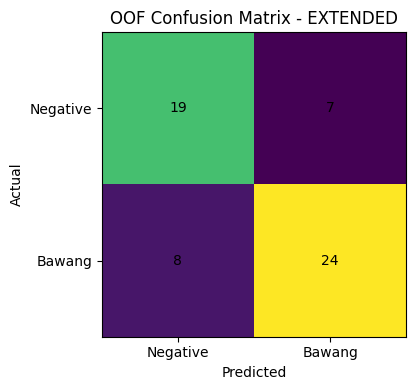

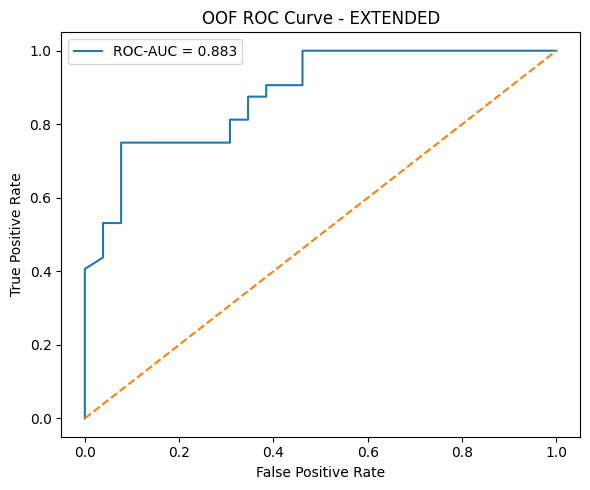

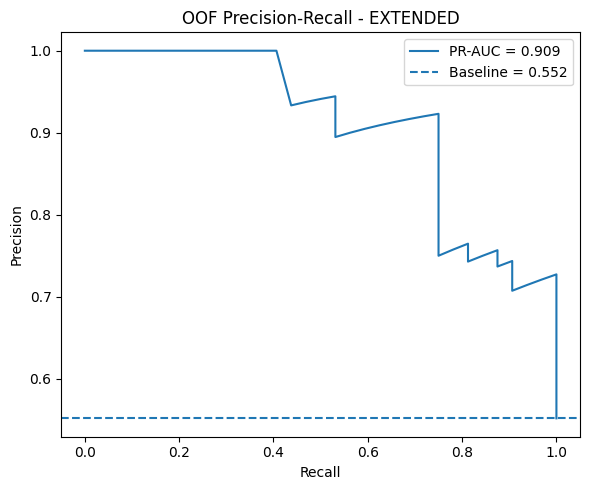


OOF ERROR ANALYSIS


,Parent_Site,Label,Lokasi,Kecamatan,Confidence,Reference_Type,OOF_Probability,OOF_Prediction,OOF_Error_Type
44,DWN013,0,Dynamic World temporal built,Rejoso,Pseudo_High,DynamicWorld_PseudoReference,0.858642,1,FP
51,DWN021,0,Dynamic World temporal built,Sukomoro,Pseudo_High,DynamicWorld_PseudoReference,0.822488,1,FP
38,DWN007,0,Dynamic World temporal built,Sukomoro,Pseudo_High,DynamicWorld_PseudoReference,0.590162,1,FP
57,DWN027,0,Dynamic World temporal built,Sukomoro,Pseudo_High,DynamicWorld_PseudoReference,0.537328,1,FP
36,DWN005,0,Dynamic World temporal trees,Rejoso,Pseudo_High,DynamicWorld_PseudoReference,0.537171,1,FP
33,DWN002,0,Dynamic World temporal trees,Rejoso,Pseudo_High,DynamicWorld_PseudoReference,0.537171,1,FP
35,DWN004,0,Dynamic World temporal trees,Rejoso,Pseudo_High,DynamicWorld_PseudoReference,0.530241,1,FP
31,BW040,1,Sawah Dekat Hutan,Gondang,High,Positive_Reference,0.487953,0,FN
21,BW026,1,Sawah Desa Ngumpul,Bagor,High,Positive_Reference,0.463298,0,FN
1,BW002,1,Persawahan Desa Nglundo,Sukomoro,High,Positive_Reference,0.433678,0,FN




FASE 4A SELESAI

MODEL TERPILIH:
EXTENDED

OOF METRICS:
Accuracy          : 0.7414
Balanced Accuracy : 0.7404
Precision         : 0.7742
Recall            : 0.75
Specificity       : 0.7308
F1                : 0.7619
MCC               : 0.4793
ROC-AUC           : 0.8828
PR-AUC            : 0.9087

Confusion:
TN: 19
FP: 7
FN: 8
TP: 24

Selection Score:
0.7699

Model:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/XGBoost_Bawang_Nganjuk_V4_1_SELECTED.json

Comparison:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Model_Comparison_V4_1.csv

Feature importance:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Feature_Importance_Selected_V4_1.csv

Metadata:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/XGBoost_Bawang_Nganjuk_V4_1_metadata.json

JANGAN HITUNG LUAS DULU
KIRIM HASIL FASE 4A INI


In [ ]:
# ============================================================
# FASE 4A FINAL
# XGBOOST V4.1
# 4-FOLD SITE-LEVEL CROSS VALIDATION
# STRICT vs EXTENDED
#
# INPUT:
# dataset_ml_nganjuk_v4_1_STRICT.csv
# dataset_ml_nganjuk_v4_1_EXTENDED.csv
#
# OUTPUT:
# - OOF prediction STRICT
# - OOF prediction EXTENDED
# - fold metrics
# - summary comparison
# - feature importance
# - confusion matrix
# - ROC curve
# - PR curve
# - final selected XGBoost model
#
# CATATAN:
# - Split berdasarkan Parent_Site
# - Threshold evaluasi = 0.50
# - Tidak melakukan threshold optimization
# - Class balancing melalui sample_weight
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install -U xgboost scikit-learn


# ============================================================
# 1. IMPORT
# ============================================================

import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from pathlib import Path

from sklearn.model_selection import (
    StratifiedGroupKFold
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path(
    "/content/drive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path(
    "/content/gdrive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


OUTPUT_DIR = (
    BASE_DIR
    /
    "XGBOOST_V4_1"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


STRICT_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_STRICT.csv"
)


EXTENDED_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_EXTENDED.csv"
)


# ============================================================
# 3. OUTPUT PATHS
# ============================================================

STRICT_OOF_PATH = (
    OUTPUT_DIR
    /
    "OOF_STRICT_V4_1.csv"
)


EXTENDED_OOF_PATH = (
    OUTPUT_DIR
    /
    "OOF_EXTENDED_V4_1.csv"
)


STRICT_FOLD_PATH = (
    OUTPUT_DIR
    /
    "Fold_Metrics_STRICT_V4_1.csv"
)


EXTENDED_FOLD_PATH = (
    OUTPUT_DIR
    /
    "Fold_Metrics_EXTENDED_V4_1.csv"
)


COMPARISON_PATH = (
    OUTPUT_DIR
    /
    "Model_Comparison_V4_1.csv"
)


IMPORTANCE_PATH = (
    OUTPUT_DIR
    /
    "Feature_Importance_Selected_V4_1.csv"
)


MODEL_PATH = (
    OUTPUT_DIR
    /
    "XGBoost_Bawang_Nganjuk_V4_1_SELECTED.json"
)


METADATA_PATH = (
    OUTPUT_DIR
    /
    "XGBoost_Bawang_Nganjuk_V4_1_metadata.json"
)


CONFUSION_PATH = (
    OUTPUT_DIR
    /
    "Confusion_Matrix_Selected_V4_1.png"
)


ROC_PATH = (
    OUTPUT_DIR
    /
    "ROC_Selected_V4_1.png"
)


PR_PATH = (
    OUTPUT_DIR
    /
    "PR_Selected_V4_1.png"
)


# ============================================================
# 4. FEATURES
# ============================================================

FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


TARGET = (
    "Label"
)


GROUP = (
    "Parent_Site"
)


# ============================================================
# 5. VALIDASI FILE
# ============================================================

print(
    "=============================================="
)

print(
    "FASE 4A"
)

print(
    "XGBOOST V4.1"
)

print(
    "=============================================="
)


for name, path in {

    "STRICT":
    STRICT_PATH,

    "EXTENDED":
    EXTENDED_PATH

}.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} tidak ditemukan:\n{path}"
        )


    print(
        name,
        ": OK"
    )


# ============================================================
# 6. LOAD DATA
# ============================================================

strict_df = pd.read_csv(
    STRICT_PATH
)


extended_df = pd.read_csv(
    EXTENDED_PATH
)


print(
    "\nSTRICT:",
    strict_df.shape
)


print(
    "EXTENDED:",
    extended_df.shape
)


# ============================================================
# 7. DATA CLEANING
# ============================================================

def clean_dataset(
    df,
    dataset_name
):

    data = (
        df.copy()
    )


    required = (
        FEATURES
        +
        [
            TARGET,
            GROUP
        ]
    )


    missing = [

        col

        for col in required

        if col not in data.columns
    ]


    if missing:

        raise ValueError(
            f"{dataset_name}: "
            f"kolom hilang {missing}"
        )


    for feature in FEATURES:

        data[
            feature
        ] = pd.to_numeric(
            data[
                feature
            ],
            errors="coerce"
        )


    data[
        TARGET
    ] = pd.to_numeric(
        data[
            TARGET
        ],
        errors="coerce"
    )


    data = (
        data
        .dropna(
            subset=(
                FEATURES
                +
                [
                    TARGET,
                    GROUP
                ]
            )
        )
        .copy()
    )


    data[
        TARGET
    ] = (
        data[
            TARGET
        ]
        .astype(int)
    )


    # --------------------------------------------------------
    # Validasi label
    # --------------------------------------------------------

    labels = sorted(
        data[
            TARGET
        ].unique()
    )


    if labels != [
        0,
        1
    ]:

        raise ValueError(
            f"{dataset_name}: "
            f"label tidak valid {labels}"
        )


    # --------------------------------------------------------
    # Pastikan satu Parent_Site tidak punya dua label
    # --------------------------------------------------------

    site_label_count = (
        data
        .groupby(
            GROUP
        )[
            TARGET
        ]
        .nunique()
    )


    conflict_sites = (
        site_label_count[
            site_label_count
            >
            1
        ]
    )


    if len(
        conflict_sites
    ) > 0:

        raise RuntimeError(
            f"{dataset_name}: "
            "ada Parent_Site dengan label konflik."
        )


    return data


strict_df = clean_dataset(
    strict_df,
    "STRICT"
)


extended_df = clean_dataset(
    extended_df,
    "EXTENDED"
)


# ============================================================
# 8. REPORT DATA
# ============================================================

def dataset_report(
    df,
    name
):

    print(
        "\n=============================================="
    )

    print(
        name
    )

    print(
        "=============================================="
    )


    print(
        "Rows:",
        len(
            df
        )
    )


    print(
        "Sites:",
        df[
            GROUP
        ].nunique()
    )


    print(
        "\nClass rows:"
    )


    print(
        df[
            TARGET
        ]
        .value_counts()
        .sort_index()
    )


    site_labels = (
        df[
            [
                GROUP,
                TARGET
            ]
        ]
        .drop_duplicates()
    )


    print(
        "\nClass sites:"
    )


    print(
        site_labels[
            TARGET
        ]
        .value_counts()
        .sort_index()
    )


dataset_report(
    strict_df,
    "STRICT"
)


dataset_report(
    extended_df,
    "EXTENDED"
)


# ============================================================
# 9. CONFIDENCE WEIGHT
# ============================================================

# Positive reference:
# High = 1.00
# Medium = 0.80
#
# Dynamic World:
# Pseudo_High = 0.90
# Pseudo_Medium = 0.75
#
# Tidak ada Pseudo_Lower pada dataset training.

CONFIDENCE_WEIGHT = {

    "High":
    1.00,

    "Medium":
    0.80,

    "Pseudo_High":
    0.90,

    "Pseudo_Medium":
    0.75
}


def get_confidence_weight(
    value
):

    if pd.isna(
        value
    ):

        return 1.0


    return float(
        CONFIDENCE_WEIGHT.get(
            str(
                value
            ),
            1.0
        )
    )


# ============================================================
# 10. CLASS-BALANCED SAMPLE WEIGHTS
# ============================================================

def build_sample_weights(
    train_df
):

    y = (
        train_df[
            TARGET
        ]
        .astype(int)
        .values
    )


    n_total = len(
        y
    )


    n_negative = int(
        (
            y
            ==
            0
        )
        .sum()
    )


    n_positive = int(
        (
            y
            ==
            1
        )
        .sum()
    )


    if (
        n_negative
        ==
        0
        or
        n_positive
        ==
        0
    ):

        raise RuntimeError(
            "Training fold kehilangan salah satu kelas."
        )


    # --------------------------------------------------------
    # Balanced class weights
    # --------------------------------------------------------

    weight_negative = (
        n_total
        /
        (
            2.0
            *
            n_negative
        )
    )


    weight_positive = (
        n_total
        /
        (
            2.0
            *
            n_positive
        )
    )


    class_weights = np.where(

        y
        ==
        0,

        weight_negative,

        weight_positive
    )


    # --------------------------------------------------------
    # Confidence weights
    # --------------------------------------------------------

    if (
        "Confidence"
        in train_df.columns
    ):

        confidence_weights = (
            train_df[
                "Confidence"
            ]
            .apply(
                get_confidence_weight
            )
            .values
        )


    else:

        confidence_weights = np.ones(
            len(
                train_df
            )
        )


    weights = (
        class_weights
        *
        confidence_weights
    )


    # --------------------------------------------------------
    # Normalisasi mean weight = 1
    # --------------------------------------------------------

    weights = (
        weights
        /
        np.mean(
            weights
        )
    )


    return (
        weights
    )


# ============================================================
# 11. XGBOOST CONFIG
# ============================================================

XGB_PARAMS = {

    "n_estimators":
    180,

    "max_depth":
    3,

    "learning_rate":
    0.035,

    "subsample":
    0.85,

    "colsample_bytree":
    0.85,

    "min_child_weight":
    2,

    "gamma":
    0.10,

    "reg_alpha":
    0.20,

    "reg_lambda":
    2.0,

    "objective":
    "binary:logistic",

    "eval_metric":
    "logloss",

    "tree_method":
    "hist",

    "random_state":
    42,

    "n_jobs":
    -1
}


THRESHOLD = (
    0.50
)


N_SPLITS = (
    4
)


# ============================================================
# 12. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    probability,
    threshold=0.50
):

    y_true = np.asarray(
        y_true
    ).astype(int)


    probability = np.asarray(
        probability
    ).astype(float)


    prediction = (
        probability
        >=
        threshold
    ).astype(int)


    cm = confusion_matrix(
        y_true,
        prediction,
        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    specificity = (

        tn
        /
        (
            tn
            +
            fp
        )

        if (
            tn
            +
            fp
        )
        >
        0

        else np.nan
    )


    metrics = {

        "Accuracy":
        accuracy_score(
            y_true,
            prediction
        ),

        "Balanced_Accuracy":
        balanced_accuracy_score(
            y_true,
            prediction
        ),

        "Precision":
        precision_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "Recall":
        recall_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "Specificity":
        specificity,

        "F1":
        f1_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "MCC":
        matthews_corrcoef(
            y_true,
            prediction
        ),

        "ROC_AUC":
        roc_auc_score(
            y_true,
            probability
        ),

        "PR_AUC":
        average_precision_score(
            y_true,
            probability
        ),

        "TN":
        int(
            tn
        ),

        "FP":
        int(
            fp
        ),

        "FN":
        int(
            fn
        ),

        "TP":
        int(
            tp
        )
    }


    return (
        metrics,
        prediction
    )


# ============================================================
# 13. CROSS VALIDATION FUNCTION
# ============================================================

def run_site_cv(
    df,
    dataset_name
):

    print(
        "\n\n=============================================="
    )

    print(
        "4-FOLD CV:",
        dataset_name
    )

    print(
        "=============================================="
    )


    data = (
        df
        .copy()
        .reset_index(
            drop=True
        )
    )


    X = (
        data[
            FEATURES
        ]
        .astype(float)
    )


    y = (
        data[
            TARGET
        ]
        .astype(int)
    )


    groups = (
        data[
            GROUP
        ]
        .astype(str)
    )


    cv = StratifiedGroupKFold(

        n_splits=N_SPLITS,

        shuffle=True,

        random_state=42
    )


    oof_probability = np.full(
        len(
            data
        ),
        np.nan
    )


    fold_assignment = np.full(
        len(
            data
        ),
        -1,
        dtype=int
    )


    fold_results = []


    split_iterator = cv.split(
        X,
        y,
        groups
    )


    for fold_number, (
        train_index,
        test_index
    ) in enumerate(
        split_iterator,
        start=1
    ):

        train_df = (
            data.iloc[
                train_index
            ]
            .copy()
        )


        test_df = (
            data.iloc[
                test_index
            ]
            .copy()
        )


        train_sites = set(
            train_df[
                GROUP
            ]
            .astype(str)
        )


        test_sites = set(
            test_df[
                GROUP
            ]
            .astype(str)
        )


        leakage = (
            train_sites
            &
            test_sites
        )


        if leakage:

            raise RuntimeError(
                f"Site leakage fold {fold_number}: "
                f"{leakage}"
            )


        X_train = (
            train_df[
                FEATURES
            ]
            .astype(float)
        )


        y_train = (
            train_df[
                TARGET
            ]
            .astype(int)
        )


        X_test = (
            test_df[
                FEATURES
            ]
            .astype(float)
        )


        y_test = (
            test_df[
                TARGET
            ]
            .astype(int)
        )


        sample_weight = (
            build_sample_weights(
                train_df
            )
        )


        model = xgb.XGBClassifier(
            **XGB_PARAMS
        )


        model.fit(

            X_train,

            y_train,

            sample_weight=sample_weight,

            verbose=False
        )


        probability = (
            model
            .predict_proba(
                X_test
            )[
                :,
                1
            ]
        )


        oof_probability[
            test_index
        ] = (
            probability
        )


        fold_assignment[
            test_index
        ] = (
            fold_number
        )


        fold_metrics, fold_prediction = (
            calculate_metrics(

                y_test,

                probability,

                threshold=THRESHOLD
            )
        )


        fold_metrics[
            "Dataset"
        ] = (
            dataset_name
        )


        fold_metrics[
            "Fold"
        ] = (
            fold_number
        )


        fold_metrics[
            "Train_Rows"
        ] = (
            len(
                train_df
            )
        )


        fold_metrics[
            "Test_Rows"
        ] = (
            len(
                test_df
            )
        )


        fold_metrics[
            "Train_Sites"
        ] = (
            train_df[
                GROUP
            ].nunique()
        )


        fold_metrics[
            "Test_Sites"
        ] = (
            test_df[
                GROUP
            ].nunique()
        )


        fold_metrics[
            "Train_Positive"
        ] = int(
            (
                y_train
                ==
                1
            ).sum()
        )


        fold_metrics[
            "Train_Negative"
        ] = int(
            (
                y_train
                ==
                0
            ).sum()
        )


        fold_metrics[
            "Test_Positive"
        ] = int(
            (
                y_test
                ==
                1
            ).sum()
        )


        fold_metrics[
            "Test_Negative"
        ] = int(
            (
                y_test
                ==
                0
            ).sum()
        )


        fold_results.append(
            fold_metrics
        )


        print(
            "\nFold",
            fold_number
        )


        print(
            "Train sites:",
            len(
                train_sites
            )
        )


        print(
            "Test sites:",
            len(
                test_sites
            )
        )


        print(
            "Test class:",
            dict(
                y_test
                .value_counts()
                .sort_index()
            )
        )


        print(
            "Balanced Accuracy:",
            round(
                fold_metrics[
                    "Balanced_Accuracy"
                ],
                4
            )
        )


        print(
            "Specificity:",
            round(
                fold_metrics[
                    "Specificity"
                ],
                4
            )
        )


        print(
            "Recall:",
            round(
                fold_metrics[
                    "Recall"
                ],
                4
            )
        )


        print(
            "MCC:",
            round(
                fold_metrics[
                    "MCC"
                ],
                4
            )
        )


    # --------------------------------------------------------
    # Validasi semua mendapat OOF prediction
    # --------------------------------------------------------

    if np.isnan(
        oof_probability
    ).any():

        raise RuntimeError(
            f"{dataset_name}: "
            "ada row tanpa OOF probability."
        )


    # ========================================================
    # OOF METRICS
    # ========================================================

    oof_metrics, oof_prediction = (
        calculate_metrics(

            y,

            oof_probability,

            threshold=THRESHOLD
        )
    )


    oof_metrics[
        "Dataset"
    ] = (
        dataset_name
    )


    oof_metrics[
        "Rows"
    ] = (
        len(
            data
        )
    )


    oof_metrics[
        "Sites"
    ] = (
        data[
            GROUP
        ].nunique()
    )


    oof_metrics[
        "Positive"
    ] = int(
        (
            y
            ==
            1
        ).sum()
    )


    oof_metrics[
        "Negative"
    ] = int(
        (
            y
            ==
            0
        ).sum()
    )


    # ========================================================
    # OOF DATAFRAME
    # ========================================================

    oof_df = (
        data.copy()
    )


    oof_df[
        "CV_Fold"
    ] = (
        fold_assignment
    )


    oof_df[
        "OOF_Probability"
    ] = (
        oof_probability
    )


    oof_df[
        "OOF_Prediction"
    ] = (
        oof_prediction
    )


    oof_df[
        "OOF_Correct"
    ] = (
        oof_df[
            TARGET
        ]
        ==
        oof_df[
            "OOF_Prediction"
        ]
    )


    oof_df[
        "OOF_Error_Type"
    ] = (
        "CORRECT"
    )


    oof_df.loc[

        (
            oof_df[
                TARGET
            ]
            ==
            1
        )
        &
        (
            oof_df[
                "OOF_Prediction"
            ]
            ==
            0
        ),

        "OOF_Error_Type"

    ] = "FN"


    oof_df.loc[

        (
            oof_df[
                TARGET
            ]
            ==
            0
        )
        &
        (
            oof_df[
                "OOF_Prediction"
            ]
            ==
            1
        ),

        "OOF_Error_Type"

    ] = "FP"


    fold_df = pd.DataFrame(
        fold_results
    )


    print(
        "\n----------------------------------------------"
    )

    print(
        "OOF RESULT:",
        dataset_name
    )

    print(
        "----------------------------------------------"
    )


    for metric_name in [

        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "MCC",
        "ROC_AUC",
        "PR_AUC"

    ]:

        print(
            f"{metric_name:20s}:",
            round(
                float(
                    oof_metrics[
                        metric_name
                    ]
                ),
                4
            )
        )


    print(
        "\nConfusion matrix:"
    )


    print(
        np.array(
            [
                [
                    oof_metrics[
                        "TN"
                    ],
                    oof_metrics[
                        "FP"
                    ]
                ],

                [
                    oof_metrics[
                        "FN"
                    ],
                    oof_metrics[
                        "TP"
                    ]
                ]
            ]
        )
    )


    return {

        "data":
        data,

        "oof":
        oof_df,

        "fold":
        fold_df,

        "metrics":
        oof_metrics
    }


# ============================================================
# 14. RUN STRICT
# ============================================================

strict_result = run_site_cv(
    strict_df,
    "STRICT"
)


# ============================================================
# 15. RUN EXTENDED
# ============================================================

extended_result = run_site_cv(
    extended_df,
    "EXTENDED"
)


# ============================================================
# 16. SAVE OOF + FOLD RESULTS
# ============================================================

strict_result[
    "oof"
].to_csv(
    STRICT_OOF_PATH,
    index=False
)


extended_result[
    "oof"
].to_csv(
    EXTENDED_OOF_PATH,
    index=False
)


strict_result[
    "fold"
].to_csv(
    STRICT_FOLD_PATH,
    index=False
)


extended_result[
    "fold"
].to_csv(
    EXTENDED_FOLD_PATH,
    index=False
)


# ============================================================
# 17. MODEL COMPARISON
# ============================================================

comparison_rows = []


for result in [

    strict_result,

    extended_result

]:

    metrics = (
        result[
            "metrics"
        ]
    )


    comparison_rows.append(
        {

            "Dataset":
            metrics[
                "Dataset"
            ],

            "Rows":
            metrics[
                "Rows"
            ],

            "Sites":
            metrics[
                "Sites"
            ],

            "Positive":
            metrics[
                "Positive"
            ],

            "Negative":
            metrics[
                "Negative"
            ],

            "Accuracy":
            metrics[
                "Accuracy"
            ],

            "Balanced_Accuracy":
            metrics[
                "Balanced_Accuracy"
            ],

            "Precision":
            metrics[
                "Precision"
            ],

            "Recall":
            metrics[
                "Recall"
            ],

            "Specificity":
            metrics[
                "Specificity"
            ],

            "F1":
            metrics[
                "F1"
            ],

            "MCC":
            metrics[
                "MCC"
            ],

            "ROC_AUC":
            metrics[
                "ROC_AUC"
            ],

            "PR_AUC":
            metrics[
                "PR_AUC"
            ],

            "TN":
            metrics[
                "TN"
            ],

            "FP":
            metrics[
                "FP"
            ],

            "FN":
            metrics[
                "FN"
            ],

            "TP":
            metrics[
                "TP"
            ]
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 18. SELECTION SCORE
# ============================================================

# Pemilihan tidak berdasarkan accuracy saja.
#
# Bobot:
# 35% Balanced Accuracy
# 25% MCC yang dipetakan ke 0-1
# 20% ROC-AUC
# 10% Specificity
# 10% F1

comparison_df[
    "MCC_01"
] = (
    comparison_df[
        "MCC"
    ]
    +
    1
) / 2


comparison_df[
    "Selection_Score"
] = (

    0.35
    *
    comparison_df[
        "Balanced_Accuracy"
    ]

    +

    0.25
    *
    comparison_df[
        "MCC_01"
    ]

    +

    0.20
    *
    comparison_df[
        "ROC_AUC"
    ]

    +

    0.10
    *
    comparison_df[
        "Specificity"
    ]

    +

    0.10
    *
    comparison_df[
        "F1"
    ]
)


comparison_df = (
    comparison_df
    .sort_values(
        "Selection_Score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)


print(
    "\n\n=============================================="
)

print(
    "STRICT vs EXTENDED"
)

print(
    "=============================================="
)


display(
    comparison_df[
        [
            "Dataset",
            "Balanced_Accuracy",
            "Specificity",
            "Recall",
            "Precision",
            "F1",
            "MCC",
            "ROC_AUC",
            "PR_AUC",
            "TN",
            "FP",
            "FN",
            "TP",
            "Selection_Score"
        ]
    ]
)


# ============================================================
# 19. SELECT MODEL
# ============================================================

selected_name = str(
    comparison_df.iloc[
        0
    ][
        "Dataset"
    ]
)


if selected_name == "STRICT":

    selected_result = (
        strict_result
    )


else:

    selected_result = (
        extended_result
    )


selected_data = (
    selected_result[
        "data"
    ]
    .copy()
)


selected_oof = (
    selected_result[
        "oof"
    ]
    .copy()
)


selected_metrics = (
    selected_result[
        "metrics"
    ]
)


print(
    "\nMODEL VERSION TERPILIH:",
    selected_name
)


# ============================================================
# 20. FIT FINAL MODEL ON FULL SELECTED DATA
# ============================================================

X_final = (
    selected_data[
        FEATURES
    ]
    .astype(float)
)


y_final = (
    selected_data[
        TARGET
    ]
    .astype(int)
)


final_weights = (
    build_sample_weights(
        selected_data
    )
)


final_model = xgb.XGBClassifier(
    **XGB_PARAMS
)


final_model.fit(

    X_final,

    y_final,

    sample_weight=final_weights,

    verbose=False
)


# ============================================================
# 21. SAVE MODEL
# ============================================================

final_model.save_model(
    str(
        MODEL_PATH
    )
)


# ============================================================
# 22. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame(
    {

        "Feature":
        FEATURES,

        "Importance":
        final_model.feature_importances_
    }
)


importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)


print(
    "\nFeature importance:"
)


display(
    importance_df
)


# ============================================================
# 23. CONFUSION MATRIX PLOT
# ============================================================

cm = confusion_matrix(

    selected_oof[
        TARGET
    ],

    selected_oof[
        "OOF_Prediction"
    ],

    labels=[
        0,
        1
    ]
)


fig = plt.figure(
    figsize=(
        5,
        4
    )
)


ax = fig.add_subplot(
    111
)


image = ax.imshow(
    cm
)


ax.set_xticks(
    [
        0,
        1
    ]
)


ax.set_yticks(
    [
        0,
        1
    ]
)


ax.set_xticklabels(
    [
        "Negative",
        "Bawang"
    ]
)


ax.set_yticklabels(
    [
        "Negative",
        "Bawang"
    ]
)


ax.set_xlabel(
    "Predicted"
)


ax.set_ylabel(
    "Actual"
)


ax.set_title(
    f"OOF Confusion Matrix - {selected_name}"
)


for i in range(
    2
):

    for j in range(
        2
    ):

        ax.text(
            j,
            i,
            str(
                cm[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center"
        )


plt.tight_layout()


plt.savefig(
    CONFUSION_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 24. ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(

    selected_oof[
        TARGET
    ],

    selected_oof[
        "OOF_Probability"
    ]
)


roc_auc_value = auc(
    fpr,
    tpr
)


fig = plt.figure(
    figsize=(
        6,
        5
    )
)


ax = fig.add_subplot(
    111
)


ax.plot(
    fpr,
    tpr,
    label=(
        f"ROC-AUC = "
        f"{roc_auc_value:.3f}"
    )
)


ax.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


ax.set_title(
    f"OOF ROC Curve - {selected_name}"
)


ax.legend()


plt.tight_layout()


plt.savefig(
    ROC_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 25. PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(

        selected_oof[
            TARGET
        ],

        selected_oof[
            "OOF_Probability"
        ]
    )
)


pr_auc_value = average_precision_score(

    selected_oof[
        TARGET
    ],

    selected_oof[
        "OOF_Probability"
    ]
)


fig = plt.figure(
    figsize=(
        6,
        5
    )
)


ax = fig.add_subplot(
    111
)


ax.plot(
    recall_curve,
    precision_curve,
    label=(
        f"PR-AUC = "
        f"{pr_auc_value:.3f}"
    )
)


baseline = (
    selected_oof[
        TARGET
    ].mean()
)


ax.axhline(
    baseline,
    linestyle="--",
    label=(
        f"Baseline = "
        f"{baseline:.3f}"
    )
)


ax.set_xlabel(
    "Recall"
)


ax.set_ylabel(
    "Precision"
)


ax.set_title(
    f"OOF Precision-Recall - {selected_name}"
)


ax.legend()


plt.tight_layout()


plt.savefig(
    PR_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 26. ERROR ANALYSIS
# ============================================================

print(
    "\n=============================================="
)

print(
    "OOF ERROR ANALYSIS"
)

print(
    "=============================================="
)


error_columns = [

    col

    for col in [

        "Parent_Site",
        "Label",
        "Lokasi",
        "Kecamatan",
        "Confidence",
        "Reference_Type",
        "OOF_Probability",
        "OOF_Prediction",
        "OOF_Error_Type"

    ]

    if col in selected_oof.columns
]


errors_df = (
    selected_oof[
        selected_oof[
            "OOF_Error_Type"
        ]
        !=
        "CORRECT"
    ][
        error_columns
    ]
    .copy()
)


errors_df = (
    errors_df
    .sort_values(
        "OOF_Probability",
        ascending=False
    )
)


display(
    errors_df
)


# ============================================================
# 27. METADATA
# ============================================================

metadata = {

    "Model_Version":
    "XGBoost_Bawang_Nganjuk_V4_1",

    "Selected_Dataset":
    selected_name,

    "Threshold":
    THRESHOLD,

    "CV":
    "4-fold StratifiedGroupKFold by Parent_Site",

    "Features":
    FEATURES,

    "Hyperparameters":
    XGB_PARAMS,

    "Confidence_Weights":
    CONFIDENCE_WEIGHT,

    "Selected_Metrics":
    {

        "Accuracy":
        float(
            selected_metrics[
                "Accuracy"
            ]
        ),

        "Balanced_Accuracy":
        float(
            selected_metrics[
                "Balanced_Accuracy"
            ]
        ),

        "Precision":
        float(
            selected_metrics[
                "Precision"
            ]
        ),

        "Recall":
        float(
            selected_metrics[
                "Recall"
            ]
        ),

        "Specificity":
        float(
            selected_metrics[
                "Specificity"
            ]
        ),

        "F1":
        float(
            selected_metrics[
                "F1"
            ]
        ),

        "MCC":
        float(
            selected_metrics[
                "MCC"
            ]
        ),

        "ROC_AUC":
        float(
            selected_metrics[
                "ROC_AUC"
            ]
        ),

        "PR_AUC":
        float(
            selected_metrics[
                "PR_AUC"
            ]
        ),

        "TN":
        int(
            selected_metrics[
                "TN"
            ]
        ),

        "FP":
        int(
            selected_metrics[
                "FP"
            ]
        ),

        "FN":
        int(
            selected_metrics[
                "FN"
            ]
        ),

        "TP":
        int(
            selected_metrics[
                "TP"
            ]
        )
    },

    "Selection_Method":
    (
        "Primary comparison using Balanced Accuracy, "
        "MCC, ROC-AUC, Specificity, and F1. "
        "Threshold fixed at 0.50."
    ),

    "Important_Limitation":
    (
        "Dynamic World negative samples are "
        "high-confidence pseudo-references, "
        "not field-survey ground truth."
    ),

    "Model_Path":
    str(
        MODEL_PATH
    )
}


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 28. FINAL REPORT
# ============================================================

winner_row = (
    comparison_df.iloc[
        0
    ]
)


print(
    "\n\n=============================================="
)

print(
    "FASE 4A SELESAI"
)

print(
    "=============================================="
)


print(
    "\nMODEL TERPILIH:"
)

print(
    selected_name
)


print(
    "\nOOF METRICS:"
)


print(
    "Accuracy          :",
    round(
        float(
            winner_row[
                "Accuracy"
            ]
        ),
        4
    )
)


print(
    "Balanced Accuracy :",
    round(
        float(
            winner_row[
                "Balanced_Accuracy"
            ]
        ),
        4
    )
)


print(
    "Precision         :",
    round(
        float(
            winner_row[
                "Precision"
            ]
        ),
        4
    )
)


print(
    "Recall            :",
    round(
        float(
            winner_row[
                "Recall"
            ]
        ),
        4
    )
)


print(
    "Specificity       :",
    round(
        float(
            winner_row[
                "Specificity"
            ]
        ),
        4
    )
)


print(
    "F1                :",
    round(
        float(
            winner_row[
                "F1"
            ]
        ),
        4
    )
)


print(
    "MCC               :",
    round(
        float(
            winner_row[
                "MCC"
            ]
        ),
        4
    )
)


print(
    "ROC-AUC           :",
    round(
        float(
            winner_row[
                "ROC_AUC"
            ]
        ),
        4
    )
)


print(
    "PR-AUC            :",
    round(
        float(
            winner_row[
                "PR_AUC"
            ]
        ),
        4
    )
)


print(
    "\nConfusion:"
)


print(
    "TN:",
    int(
        winner_row[
            "TN"
        ]
    )
)


print(
    "FP:",
    int(
        winner_row[
            "FP"
        ]
    )
)


print(
    "FN:",
    int(
        winner_row[
            "FN"
        ]
    )
)


print(
    "TP:",
    int(
        winner_row[
            "TP"
        ]
    )
)


print(
    "\nSelection Score:"
)

print(
    round(
        float(
            winner_row[
                "Selection_Score"
            ]
        ),
        4
    )
)


print(
    "\nModel:"
)

print(
    MODEL_PATH
)


print(
    "\nComparison:"
)

print(
    COMPARISON_PATH
)


print(
    "\nFeature importance:"
)

print(
    IMPORTANCE_PATH
)


print(
    "\nMetadata:"
)

print(
    METADATA_PATH
)


print(
    "\n=============================================="
)

print(
    "JANGAN HITUNG LUAS DULU"
)

print(
    "KIRIM HASIL FASE 4A INI"
)

print(
    "=============================================="
)

In [ ]:
# ============================================================
# FASE 4A-2
# REPEATED SITE-LEVEL CROSS VALIDATION
# XGBOOST V4.1
#
# TUJUAN:
# - Menguji apakah hasil STRICT dan EXTENDED stabil
#   terhadap perubahan pembagian fold.
#
# METODE:
# - 10 random seeds
# - 4-fold StratifiedGroupKFold per seed
# - total 40 fold per dataset
# - threshold tetap 0.50
#
# OUTPUT:
# 1. Semua fold metrics
# 2. Summary mean/std
# 3. Repeat-level OOF metrics
# 4. Comparison STRICT vs EXTENDED
#
# BELUM MENGHITUNG LUAS
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install -U xgboost scikit-learn


# ============================================================
# 1. IMPORT
# ============================================================

import json
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb

from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path(
    "/content/drive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path(
    "/content/gdrive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


OUTPUT_DIR = (
    BASE_DIR
    /
    "XGBOOST_V4_1"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


STRICT_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_STRICT.csv"
)


EXTENDED_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_EXTENDED.csv"
)


ALL_FOLD_PATH = (
    OUTPUT_DIR
    /
    "RepeatedCV_All_Folds_V4_1.csv"
)


REPEAT_METRICS_PATH = (
    OUTPUT_DIR
    /
    "RepeatedCV_Repeat_Metrics_V4_1.csv"
)


SUMMARY_PATH = (
    OUTPUT_DIR
    /
    "RepeatedCV_Summary_V4_1.csv"
)


JSON_PATH = (
    OUTPUT_DIR
    /
    "RepeatedCV_Summary_V4_1.json"
)


# ============================================================
# 3. FEATURES
# ============================================================

FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


TARGET = (
    "Label"
)


GROUP = (
    "Parent_Site"
)


THRESHOLD = (
    0.50
)


N_SPLITS = (
    4
)


# ============================================================
# 4. RANDOM SEEDS
# ============================================================

SEEDS = [
    11,
    22,
    33,
    44,
    55,
    66,
    77,
    88,
    99,
    111
]


print(
    "=============================================="
)

print(
    "FASE 4A-2"
)

print(
    "REPEATED SITE-LEVEL CV"
)

print(
    "=============================================="
)


print(
    "Repeats:",
    len(
        SEEDS
    )
)


print(
    "Folds per repeat:",
    N_SPLITS
)


# ============================================================
# 5. LOAD DATA
# ============================================================

strict = pd.read_csv(
    STRICT_PATH
)


extended = pd.read_csv(
    EXTENDED_PATH
)


DATASETS = {

    "STRICT":
    strict,

    "EXTENDED":
    extended
}


# ============================================================
# 6. CLEAN FUNCTION
# ============================================================

def clean_dataset(
    df
):

    data = (
        df.copy()
    )


    for feature in FEATURES:

        data[
            feature
        ] = pd.to_numeric(
            data[
                feature
            ],
            errors="coerce"
        )


    data[
        TARGET
    ] = pd.to_numeric(
        data[
            TARGET
        ],
        errors="coerce"
    )


    data = (
        data
        .dropna(
            subset=(
                FEATURES
                +
                [
                    TARGET,
                    GROUP
                ]
            )
        )
        .copy()
        .reset_index(
            drop=True
        )
    )


    data[
        TARGET
    ] = (
        data[
            TARGET
        ]
        .astype(int)
    )


    return data


# ============================================================
# 7. CONFIDENCE WEIGHTS
# ============================================================

CONFIDENCE_WEIGHT = {

    "High":
    1.00,

    "Medium":
    0.80,

    "Pseudo_High":
    0.90,

    "Pseudo_Medium":
    0.75
}


def confidence_weight(
    value
):

    if pd.isna(
        value
    ):

        return 1.0


    return float(
        CONFIDENCE_WEIGHT.get(
            str(
                value
            ),
            1.0
        )
    )


# ============================================================
# 8. SAMPLE WEIGHTS
# ============================================================

def build_weights(
    df
):

    y = (
        df[
            TARGET
        ]
        .astype(int)
        .values
    )


    n = len(
        y
    )


    n0 = int(
        (
            y
            ==
            0
        )
        .sum()
    )


    n1 = int(
        (
            y
            ==
            1
        )
        .sum()
    )


    class_weight_0 = (
        n
        /
        (
            2
            *
            n0
        )
    )


    class_weight_1 = (
        n
        /
        (
            2
            *
            n1
        )
    )


    class_weights = np.where(

        y
        ==
        0,

        class_weight_0,

        class_weight_1
    )


    if (
        "Confidence"
        in df.columns
    ):

        confidence_weights = (
            df[
                "Confidence"
            ]
            .apply(
                confidence_weight
            )
            .values
        )


    else:

        confidence_weights = np.ones(
            len(
                df
            )
        )


    weights = (
        class_weights
        *
        confidence_weights
    )


    weights = (
        weights
        /
        np.mean(
            weights
        )
    )


    return weights


# ============================================================
# 9. MODEL PARAMS
# ============================================================

XGB_PARAMS = {

    "n_estimators":
    180,

    "max_depth":
    3,

    "learning_rate":
    0.035,

    "subsample":
    0.85,

    "colsample_bytree":
    0.85,

    "min_child_weight":
    2,

    "gamma":
    0.10,

    "reg_alpha":
    0.20,

    "reg_lambda":
    2.0,

    "objective":
    "binary:logistic",

    "eval_metric":
    "logloss",

    "tree_method":
    "hist",

    "n_jobs":
    -1
}


# ============================================================
# 10. METRIC FUNCTION
# ============================================================

def metrics_from_probability(
    y_true,
    probability
):

    y_true = np.asarray(
        y_true
    ).astype(int)


    probability = np.asarray(
        probability
    ).astype(float)


    prediction = (
        probability
        >=
        THRESHOLD
    ).astype(int)


    cm = confusion_matrix(

        y_true,

        prediction,

        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    specificity = (

        tn
        /
        (
            tn
            +
            fp
        )

        if (
            tn
            +
            fp
        )
        >
        0

        else np.nan
    )


    return {

        "Accuracy":
        accuracy_score(
            y_true,
            prediction
        ),

        "Balanced_Accuracy":
        balanced_accuracy_score(
            y_true,
            prediction
        ),

        "Precision":
        precision_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "Recall":
        recall_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "Specificity":
        specificity,

        "F1":
        f1_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "MCC":
        matthews_corrcoef(
            y_true,
            prediction
        ),

        "ROC_AUC":
        roc_auc_score(
            y_true,
            probability
        ),

        "PR_AUC":
        average_precision_score(
            y_true,
            probability
        ),

        "TN":
        int(
            tn
        ),

        "FP":
        int(
            fp
        ),

        "FN":
        int(
            fn
        ),

        "TP":
        int(
            tp
        )
    }


# ============================================================
# 11. STORAGE
# ============================================================

all_fold_results = []
all_repeat_results = []


# ============================================================
# 12. LOOP DATASETS
# ============================================================

for dataset_name, raw_data in DATASETS.items():

    print(
        "\n\n=============================================="
    )

    print(
        dataset_name
    )

    print(
        "=============================================="
    )


    data = clean_dataset(
        raw_data
    )


    X = (
        data[
            FEATURES
        ]
        .astype(float)
    )


    y = (
        data[
            TARGET
        ]
        .astype(int)
    )


    groups = (
        data[
            GROUP
        ]
        .astype(str)
    )


    print(
        "Rows:",
        len(
            data
        )
    )


    print(
        "Sites:",
        data[
            GROUP
        ].nunique()
    )


    # ========================================================
    # REPEAT LOOP
    # ========================================================

    for repeat_number, seed in enumerate(
        SEEDS,
        start=1
    ):

        cv = StratifiedGroupKFold(

            n_splits=N_SPLITS,

            shuffle=True,

            random_state=seed
        )


        oof_probability = np.full(
            len(
                data
            ),
            np.nan
        )


        # ====================================================
        # FOLD LOOP
        # ====================================================

        for fold_number, (
            train_index,
            test_index
        ) in enumerate(

            cv.split(
                X,
                y,
                groups
            ),

            start=1
        ):

            train_df = (
                data.iloc[
                    train_index
                ]
                .copy()
            )


            test_df = (
                data.iloc[
                    test_index
                ]
                .copy()
            )


            train_sites = set(
                train_df[
                    GROUP
                ]
                .astype(str)
            )


            test_sites = set(
                test_df[
                    GROUP
                ]
                .astype(str)
            )


            if (
                train_sites
                &
                test_sites
            ):

                raise RuntimeError(
                    "Site leakage ditemukan."
                )


            X_train = (
                train_df[
                    FEATURES
                ]
                .astype(float)
            )


            y_train = (
                train_df[
                    TARGET
                ]
                .astype(int)
            )


            X_test = (
                test_df[
                    FEATURES
                ]
                .astype(float)
            )


            y_test = (
                test_df[
                    TARGET
                ]
                .astype(int)
            )


            weights = (
                build_weights(
                    train_df
                )
            )


            model_params = (
                XGB_PARAMS.copy()
            )


            model_params[
                "random_state"
            ] = seed


            model = xgb.XGBClassifier(
                **model_params
            )


            model.fit(

                X_train,

                y_train,

                sample_weight=weights,

                verbose=False
            )


            probability = (
                model
                .predict_proba(
                    X_test
                )[
                    :,
                    1
                ]
            )


            oof_probability[
                test_index
            ] = (
                probability
            )


            fold_metric = (
                metrics_from_probability(
                    y_test,
                    probability
                )
            )


            fold_metric[
                "Dataset"
            ] = (
                dataset_name
            )


            fold_metric[
                "Repeat"
            ] = (
                repeat_number
            )


            fold_metric[
                "Seed"
            ] = (
                seed
            )


            fold_metric[
                "Fold"
            ] = (
                fold_number
            )


            fold_metric[
                "Train_Sites"
            ] = len(
                train_sites
            )


            fold_metric[
                "Test_Sites"
            ] = len(
                test_sites
            )


            all_fold_results.append(
                fold_metric
            )


        # ====================================================
        # REPEAT OOF RESULT
        # ====================================================

        if np.isnan(
            oof_probability
        ).any():

            raise RuntimeError(
                "OOF probability tidak lengkap."
            )


        repeat_metric = (
            metrics_from_probability(
                y,
                oof_probability
            )
        )


        repeat_metric[
            "Dataset"
        ] = (
            dataset_name
        )


        repeat_metric[
            "Repeat"
        ] = (
            repeat_number
        )


        repeat_metric[
            "Seed"
        ] = (
            seed
        )


        all_repeat_results.append(
            repeat_metric
        )


        print(
            f"Repeat {repeat_number:02d} | "
            f"Seed {seed:3d} | "
            f"BAcc "
            f"{repeat_metric['Balanced_Accuracy']:.3f} | "
            f"Spec "
            f"{repeat_metric['Specificity']:.3f} | "
            f"ROC "
            f"{repeat_metric['ROC_AUC']:.3f} | "
            f"MCC "
            f"{repeat_metric['MCC']:.3f}"
        )


# ============================================================
# 13. DATAFRAMES
# ============================================================

fold_df = pd.DataFrame(
    all_fold_results
)


repeat_df = pd.DataFrame(
    all_repeat_results
)


# ============================================================
# 14. SAVE RAW RESULTS
# ============================================================

fold_df.to_csv(
    ALL_FOLD_PATH,
    index=False
)


repeat_df.to_csv(
    REPEAT_METRICS_PATH,
    index=False
)


# ============================================================
# 15. SUMMARY METRICS
# ============================================================

METRIC_COLUMNS = [

    "Accuracy",

    "Balanced_Accuracy",

    "Precision",

    "Recall",

    "Specificity",

    "F1",

    "MCC",

    "ROC_AUC",

    "PR_AUC"
]


summary_rows = []


for dataset_name in [

    "STRICT",

    "EXTENDED"

]:

    subset = (
        repeat_df[
            repeat_df[
                "Dataset"
            ]
            ==
            dataset_name
        ]
    )


    row = {

        "Dataset":
        dataset_name,

        "Repeats":
        len(
            subset
        )
    }


    for metric in METRIC_COLUMNS:

        row[
            f"{metric}_Mean"
        ] = float(
            subset[
                metric
            ]
            .mean()
        )


        row[
            f"{metric}_SD"
        ] = float(
            subset[
                metric
            ]
            .std(
                ddof=1
            )
        )


        row[
            f"{metric}_Min"
        ] = float(
            subset[
                metric
            ]
            .min()
        )


        row[
            f"{metric}_Max"
        ] = float(
            subset[
                metric
            ]
            .max()
        )


    summary_rows.append(
        row
    )


summary_df = pd.DataFrame(
    summary_rows
)


summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)


# ============================================================
# 16. DISPLAY KEY SUMMARY
# ============================================================

KEY_COLUMNS = [

    "Dataset",

    "Balanced_Accuracy_Mean",
    "Balanced_Accuracy_SD",

    "Specificity_Mean",
    "Specificity_SD",

    "Recall_Mean",
    "Recall_SD",

    "F1_Mean",
    "F1_SD",

    "MCC_Mean",
    "MCC_SD",

    "ROC_AUC_Mean",
    "ROC_AUC_SD",

    "PR_AUC_Mean",
    "PR_AUC_SD"
]


print(
    "\n\n=============================================="
)

print(
    "REPEATED CV SUMMARY"
)

print(
    "=============================================="
)


display(
    summary_df[
        KEY_COLUMNS
    ]
    .round(
        4
    )
)


# ============================================================
# 17. SIMPLE ROBUSTNESS COMPARISON
# ============================================================

strict_summary = (
    summary_df[
        summary_df[
            "Dataset"
        ]
        ==
        "STRICT"
    ]
    .iloc[
        0
    ]
)


extended_summary = (
    summary_df[
        summary_df[
            "Dataset"
        ]
        ==
        "EXTENDED"
    ]
    .iloc[
        0
    ]
)


print(
    "\n=============================================="
)

print(
    "PRIMARY COMPARISON"
)

print(
    "=============================================="
)


for metric in [

    "Balanced_Accuracy",

    "Specificity",

    "Recall",

    "F1",

    "MCC",

    "ROC_AUC",

    "PR_AUC"

]:

    print(
        f"\n{metric}"
    )


    print(
        "STRICT   :",
        round(
            float(
                strict_summary[
                    f"{metric}_Mean"
                ]
            ),
            4
        ),
        "±",
        round(
            float(
                strict_summary[
                    f"{metric}_SD"
                ]
            ),
            4
        )
    )


    print(
        "EXTENDED :",
        round(
            float(
                extended_summary[
                    f"{metric}_Mean"
                ]
            ),
            4
        ),
        "±",
        round(
            float(
                extended_summary[
                    f"{metric}_SD"
                ]
            ),
            4
        )
    )


# ============================================================
# 18. RECOMMEND PRIMARY DATASET
# ============================================================

# Primary criterion:
# 1. Balanced Accuracy
# 2. Specificity
# 3. ROC-AUC
#
# Tidak menggunakan weighted selection score lagi.

strict_bacc = float(
    strict_summary[
        "Balanced_Accuracy_Mean"
    ]
)


extended_bacc = float(
    extended_summary[
        "Balanced_Accuracy_Mean"
    ]
)


strict_spec = float(
    strict_summary[
        "Specificity_Mean"
    ]
)


extended_spec = float(
    extended_summary[
        "Specificity_Mean"
    ]
)


strict_roc = float(
    strict_summary[
        "ROC_AUC_Mean"
    ]
)


extended_roc = float(
    extended_summary[
        "ROC_AUC_Mean"
    ]
)


# ============================================================
# 19. DECISION
# ============================================================

if (
    extended_bacc
    >=
    strict_bacc
    and
    extended_spec
    >=
    strict_spec
):

    recommended = (
        "EXTENDED"
    )


elif (
    strict_bacc
    >=
    extended_bacc
    and
    strict_spec
    >=
    extended_spec
):

    recommended = (
        "STRICT"
    )


else:

    # Kalau trade-off, prioritaskan
    # Balanced Accuracy

    if (
        extended_bacc
        >
        strict_bacc
    ):

        recommended = (
            "EXTENDED"
        )

    else:

        recommended = (
            "STRICT"
        )


# ============================================================
# 20. JSON SUMMARY
# ============================================================

json_summary = {

    "Phase":
    "FASE_4A_2",

    "Method":
    (
        "10-repeat 4-fold StratifiedGroupKFold "
        "site-level cross-validation"
    ),

    "Seeds":
    SEEDS,

    "Threshold":
    THRESHOLD,

    "Recommended_Dataset":
    recommended,

    "Strict":
    {

        "Balanced_Accuracy_Mean":
        strict_bacc,

        "Specificity_Mean":
        strict_spec,

        "ROC_AUC_Mean":
        strict_roc
    },

    "Extended":
    {

        "Balanced_Accuracy_Mean":
        extended_bacc,

        "Specificity_Mean":
        extended_spec,

        "ROC_AUC_Mean":
        extended_roc
    }
}


with open(
    JSON_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        json_summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 21. FINAL REPORT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 4A-2 SELESAI"
)

print(
    "=============================================="
)


print(
    "\nRECOMMENDED DATASET:"
)

print(
    recommended
)


print(
    "\nSTRICT"
)

print(
    "Balanced Accuracy:",
    round(
        strict_bacc,
        4
    ),
    "±",
    round(
        float(
            strict_summary[
                "Balanced_Accuracy_SD"
            ]
        ),
        4
    )
)


print(
    "Specificity:",
    round(
        strict_spec,
        4
    ),
    "±",
    round(
        float(
            strict_summary[
                "Specificity_SD"
            ]
        ),
        4
    )
)


print(
    "ROC-AUC:",
    round(
        strict_roc,
        4
    ),
    "±",
    round(
        float(
            strict_summary[
                "ROC_AUC_SD"
            ]
        ),
        4
    )
)


print(
    "MCC:",
    round(
        float(
            strict_summary[
                "MCC_Mean"
            ]
        ),
        4
    ),
    "±",
    round(
        float(
            strict_summary[
                "MCC_SD"
            ]
        ),
        4
    )
)


print(
    "\nEXTENDED"
)

print(
    "Balanced Accuracy:",
    round(
        extended_bacc,
        4
    ),
    "±",
    round(
        float(
            extended_summary[
                "Balanced_Accuracy_SD"
            ]
        ),
        4
    )
)


print(
    "Specificity:",
    round(
        extended_spec,
        4
    ),
    "±",
    round(
        float(
            extended_summary[
                "Specificity_SD"
            ]
        ),
        4
    )
)


print(
    "ROC-AUC:",
    round(
        extended_roc,
        4
    ),
    "±",
    round(
        float(
            extended_summary[
                "ROC_AUC_SD"
            ]
        ),
        4
    )
)


print(
    "MCC:",
    round(
        float(
            extended_summary[
                "MCC_Mean"
            ]
        ),
        4
    ),
    "±",
    round(
        float(
            extended_summary[
                "MCC_SD"
            ]
        ),
        4
    )
)


print(
    "\nAll folds:"
)

print(
    ALL_FOLD_PATH
)


print(
    "\nRepeat metrics:"
)

print(
    REPEAT_METRICS_PATH
)


print(
    "\nSummary:"
)

print(
    SUMMARY_PATH
)


print(
    "\n=============================================="
)

print(
    "KIRIM FINAL REPORT INI"
)

print(
    "SETELAH ITU LANGSUNG FASE 4B PEMETAAN"
)

print(
    "=============================================="
)

FASE 4A-2
REPEATED SITE-LEVEL CV
Repeats: 10
Folds per repeat: 4


STRICT
Rows: 56
Sites: 56
Repeat 01 | Seed  11 | BAcc 0.839 | Spec 0.833 | ROC 0.928 | MCC 0.674
Repeat 02 | Seed  22 | BAcc 0.844 | Spec 0.875 | ROC 0.906 | MCC 0.681
Repeat 03 | Seed  33 | BAcc 0.797 | Spec 0.750 | ROC 0.896 | MCC 0.597
Repeat 04 | Seed  44 | BAcc 0.833 | Spec 0.792 | ROC 0.919 | MCC 0.671
Repeat 05 | Seed  55 | BAcc 0.781 | Spec 0.750 | ROC 0.906 | MCC 0.562
Repeat 06 | Seed  66 | BAcc 0.833 | Spec 0.792 | ROC 0.932 | MCC 0.671
Repeat 07 | Seed  77 | BAcc 0.859 | Spec 0.875 | ROC 0.938 | MCC 0.713
Repeat 08 | Seed  88 | BAcc 0.755 | Spec 0.792 | ROC 0.879 | MCC 0.505
Repeat 09 | Seed  99 | BAcc 0.812 | Spec 0.750 | ROC 0.910 | MCC 0.633
Repeat 10 | Seed 111 | BAcc 0.823 | Spec 0.833 | ROC 0.877 | MCC 0.641


EXTENDED
Rows: 58
Sites: 58
Repeat 01 | Seed  11 | BAcc 0.756 | Spec 0.731 | ROC 0.886 | MCC 0.512
Repeat 02 | Seed  22 | BAcc 0.791 | Spec 0.769 | ROC 0.898 | MCC 0.582
Repeat 03 | Seed  33 | BA

,Dataset,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,Specificity_Mean,Specificity_SD,Recall_Mean,Recall_SD,F1_Mean,F1_SD,MCC_Mean,MCC_SD,ROC_AUC_Mean,ROC_AUC_SD,PR_AUC_Mean,PR_AUC_SD
0,STRICT,0.8177,0.0317,0.8042,0.0483,0.8312,0.0470,0.8401,0.031,0.6348,0.0631,0.9090,0.0210,0.9298,0.0179
1,EXTENDED,0.7757,0.0311,0.7577,0.0514,0.7938,0.0302,0.7976,0.026,0.5515,0.0613,0.8934,0.0096,0.9202,0.0094



PRIMARY COMPARISON

Balanced_Accuracy
STRICT   : 0.8177 ± 0.0317
EXTENDED : 0.7757 ± 0.0311

Specificity
STRICT   : 0.8042 ± 0.0483
EXTENDED : 0.7577 ± 0.0514

Recall
STRICT   : 0.8313 ± 0.047
EXTENDED : 0.7937 ± 0.0302

F1
STRICT   : 0.8401 ± 0.031
EXTENDED : 0.7976 ± 0.026

MCC
STRICT   : 0.6348 ± 0.0631
EXTENDED : 0.5515 ± 0.0613

ROC_AUC
STRICT   : 0.909 ± 0.021
EXTENDED : 0.8934 ± 0.0096

PR_AUC
STRICT   : 0.9298 ± 0.0179
EXTENDED : 0.9202 ± 0.0094


FASE 4A-2 SELESAI

RECOMMENDED DATASET:
STRICT

STRICT
Balanced Accuracy: 0.8177 ± 0.0317
Specificity: 0.8042 ± 0.0483
ROC-AUC: 0.909 ± 0.021
MCC: 0.6348 ± 0.0631

EXTENDED
Balanced Accuracy: 0.7757 ± 0.0311
Specificity: 0.7577 ± 0.0514
ROC-AUC: 0.8934 ± 0.0096
MCC: 0.5515 ± 0.0613

All folds:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/RepeatedCV_All_Folds_V4_1.csv

Repeat metrics:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/RepeatedCV_Repeat_Metrics_V4_1.csv

Summary:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/RepeatedCV_Summary_V4_1.csv

KIR

In [ ]:
# ============================================================
# FASE 4B FINAL
# STRICT XGBOOST FINAL MODEL
# SPATIAL INFERENCE + PROBABILITY MAP + AREA ESTIMATION
#
# MODEL:
# dataset_ml_nganjuk_v4_1_STRICT.csv
#
# STUDY AREA:
# Bagor, Gondang, Rejoso, Sukomoro
#
# OUTPUT:
# 1. Final STRICT XGBoost model
# 2. Probability GeoTIFF
# 3. Binary GeoTIFF threshold 0.50
# 4. Area estimate per kecamatan
# 5. Threshold sensitivity 0.40 / 0.50 / 0.60
# 6. Feature importance
#
# CATATAN:
# - Prediction dilakukan secara block/window
#   agar tidak memenuhi RAM.
# - Area dihitung menggunakan geodesic pixel area
#   karena raster berada di EPSG:4326.
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install -U xgboost rasterio geopandas shapely pyproj


# ============================================================
# 1. IMPORT
# ============================================================

import os
import json
import math
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import xgboost as xgb

from pathlib import Path

from rasterio.features import geometry_mask
from rasterio.windows import Window
from pyproj import Geod

from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path(
    "/content/drive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path(
    "/content/gdrive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


MODEL_DIR = (
    BASE_DIR
    /
    "XGBOOST_V4_1"
)


MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OFFICIAL_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


# ============================================================
# 3. INPUT
# ============================================================

STRICT_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_STRICT.csv"
)


FEATURE_RASTER = (
    BASE_DIR
    /
    "FeatureStack_Nganjuk_V3_FINAL.tif"
)


BOUNDARY_PATH = (
    OFFICIAL_DIR
    /
    "Batas_4_Kecamatan_Nganjuk.geojson"
)


# ============================================================
# 4. OUTPUT
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    /
    "XGBoost_Bawang_Nganjuk_V4_1_STRICT_FINAL.json"
)


PROBABILITY_PATH = (
    MODEL_DIR
    /
    "Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif"
)


BINARY_PATH = (
    MODEL_DIR
    /
    "Binary_Bawang_Nganjuk_4Kec_V4_1_STRICT_T050.tif"
)


IMPORTANCE_PATH = (
    MODEL_DIR
    /
    "Feature_Importance_STRICT_FINAL.csv"
)


AREA_PATH = (
    MODEL_DIR
    /
    "Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv"
)


SUMMARY_PATH = (
    MODEL_DIR
    /
    "FASE_4B_STRICT_Mapping_Summary.json"
)


# ============================================================
# 5. CONFIG
# ============================================================

FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


TARGET = (
    "Label"
)


MAIN_THRESHOLD = (
    0.50
)


AREA_THRESHOLDS = [
    0.40,
    0.50,
    0.60
]


BLOCK_ROWS = (
    256
)


PROB_NODATA = (
    -9999.0
)


BINARY_NODATA = (
    255
)


# ============================================================
# 6. MODEL CONFIG
# HARUS SAMA DENGAN FASE 4A
# ============================================================

XGB_PARAMS = {

    "n_estimators":
    180,

    "max_depth":
    3,

    "learning_rate":
    0.035,

    "subsample":
    0.85,

    "colsample_bytree":
    0.85,

    "min_child_weight":
    2,

    "gamma":
    0.10,

    "reg_alpha":
    0.20,

    "reg_lambda":
    2.0,

    "objective":
    "binary:logistic",

    "eval_metric":
    "logloss",

    "tree_method":
    "hist",

    "random_state":
    42,

    "n_jobs":
    -1
}


CONFIDENCE_WEIGHT = {

    "High":
    1.00,

    "Medium":
    0.80,

    "Pseudo_High":
    0.90,

    "Pseudo_Medium":
    0.75
}


# ============================================================
# 7. VALIDASI FILE
# ============================================================

print(
    "=============================================="
)

print(
    "FASE 4B"
)

print(
    "STRICT FINAL SPATIAL INFERENCE"
)

print(
    "=============================================="
)


for name, path in {

    "STRICT dataset":
    STRICT_PATH,

    "Feature raster":
    FEATURE_RASTER,

    "Batas 4 kecamatan":
    BOUNDARY_PATH

}.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} tidak ditemukan:\n{path}"
        )


    print(
        name,
        ": OK"
    )


# ============================================================
# 8. LOAD STRICT DATASET
# ============================================================

data = pd.read_csv(
    STRICT_PATH
)


for feature in FEATURES:

    data[
        feature
    ] = pd.to_numeric(
        data[
            feature
        ],
        errors="coerce"
    )


data[
    TARGET
] = pd.to_numeric(
    data[
        TARGET
    ],
    errors="coerce"
)


data = (
    data
    .dropna(
        subset=(
            FEATURES
            +
            [
                TARGET,
                "Parent_Site"
            ]
        )
    )
    .copy()
    .reset_index(
        drop=True
    )
)


data[
    TARGET
] = (
    data[
        TARGET
    ]
    .astype(int)
)


print(
    "\nTraining rows:",
    len(
        data
    )
)


print(
    "Training sites:",
    data[
        "Parent_Site"
    ].nunique()
)


print(
    "\nClass:"
)


print(
    data[
        TARGET
    ]
    .value_counts()
    .sort_index()
)


# ============================================================
# 9. SAMPLE WEIGHTS
# ============================================================

def confidence_weight(
    value
):

    if pd.isna(
        value
    ):

        return (
            1.0
        )


    return float(

        CONFIDENCE_WEIGHT.get(

            str(
                value
            ),

            1.0
        )
    )


def build_weights(
    df
):

    y = (
        df[
            TARGET
        ]
        .astype(int)
        .values
    )


    n = len(
        y
    )


    n0 = int(
        (
            y
            ==
            0
        )
        .sum()
    )


    n1 = int(
        (
            y
            ==
            1
        )
        .sum()
    )


    if (
        n0
        ==
        0
        or
        n1
        ==
        0
    ):

        raise RuntimeError(
            "Salah satu kelas kosong."
        )


    w0 = (
        n
        /
        (
            2.0
            *
            n0
        )
    )


    w1 = (
        n
        /
        (
            2.0
            *
            n1
        )
    )


    class_weights = np.where(

        y
        ==
        0,

        w0,

        w1
    )


    if (
        "Confidence"
        in df.columns
    ):

        confidence_weights = (

            df[
                "Confidence"
            ]
            .apply(
                confidence_weight
            )
            .values
        )

    else:

        confidence_weights = np.ones(
            len(
                df
            )
        )


    weights = (
        class_weights
        *
        confidence_weights
    )


    weights = (
        weights
        /
        np.mean(
            weights
        )
    )


    return (
        weights
    )


# ============================================================
# 10. TRAIN FINAL STRICT MODEL
# ============================================================

print(
    "\n=============================================="
)

print(
    "TRAIN FINAL STRICT MODEL"
)

print(
    "=============================================="
)


X = (
    data[
        FEATURES
    ]
    .astype(float)
)


y = (
    data[
        TARGET
    ]
    .astype(int)
)


weights = build_weights(
    data
)


model = xgb.XGBClassifier(
    **XGB_PARAMS
)


model.fit(

    X,

    y,

    sample_weight=weights,

    verbose=False
)


model.save_model(
    str(
        MODEL_PATH
    )
)


print(
    "Model saved:"
)

print(
    MODEL_PATH
)


# ============================================================
# 11. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame(
    {

        "Feature":
        FEATURES,

        "Importance":
        model.feature_importances_
    }
)


importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)


print(
    "\nFeature importance:"
)


display(
    importance_df
)


# ============================================================
# 12. LOAD BOUNDARY
# ============================================================

boundary = gpd.read_file(
    BOUNDARY_PATH
)


if (
    "Kecamatan"
    not in boundary.columns
):

    raise ValueError(
        "Field Kecamatan tidak ditemukan."
    )


print(
    "\nKecamatan:"
)


print(
    boundary[
        "Kecamatan"
    ].tolist()
)


# ============================================================
# 13. PREPARE RASTER + BOUNDARY
# ============================================================

with rasterio.open(
    FEATURE_RASTER
) as src:

    raster_crs = (
        src.crs
    )


    raster_transform = (
        src.transform
    )


    raster_width = (
        src.width
    )


    raster_height = (
        src.height
    )


    raster_count = (
        src.count
    )


    raster_nodata = (
        src.nodata
    )


print(
    "\nRaster CRS:",
    raster_crs
)


print(
    "Raster size:",
    raster_width,
    "x",
    raster_height
)


print(
    "Raster bands:",
    raster_count
)


print(
    "Raster nodata:",
    raster_nodata
)


if raster_count < 8:

    raise RuntimeError(
        "Raster tidak memiliki 8 band."
    )


boundary = (
    boundary
    .to_crs(
        raster_crs
    )
)


study_geometries = [

    geom

    for geom
    in boundary.geometry

    if (
        geom is not None
        and
        not geom.is_empty
    )
]


# ============================================================
# 14. STUDY AREA MASK
# ============================================================

study_mask = geometry_mask(

    study_geometries,

    out_shape=(
        raster_height,
        raster_width
    ),

    transform=raster_transform,

    invert=True,

    all_touched=False
)


print(
    "\nPixels inside 4 kecamatan:",
    int(
        study_mask.sum()
    )
)


# ============================================================
# 15. OUTPUT RASTER PROFILE
# ============================================================

with rasterio.open(
    FEATURE_RASTER
) as src:

    base_profile = (
        src.profile.copy()
    )


prob_profile = (
    base_profile.copy()
)


prob_profile.update(
    {

        "count":
        1,

        "dtype":
        "float32",

        "nodata":
        PROB_NODATA,

        "compress":
        "deflate",

        "predictor":
        3
    }
)


binary_profile = (
    base_profile.copy()
)


binary_profile.update(
    {

        "count":
        1,

        "dtype":
        "uint8",

        "nodata":
        BINARY_NODATA,

        "compress":
        "deflate"
    }
)


# ============================================================
# 16. WINDOW INFERENCE
# ============================================================

print(
    "\n=============================================="
)

print(
    "SPATIAL PREDICTION"
)

print(
    "=============================================="
)


total_predicted_pixels = (
    0
)


with rasterio.open(
    FEATURE_RASTER
) as src, \
     rasterio.open(
         PROBABILITY_PATH,
         "w",
         **prob_profile
     ) as prob_dst, \
     rasterio.open(
         BINARY_PATH,
         "w",
         **binary_profile
     ) as bin_dst:


    for row_start in range(
        0,
        raster_height,
        BLOCK_ROWS
    ):

        current_rows = min(

            BLOCK_ROWS,

            raster_height
            -
            row_start
        )


        window = Window(

            col_off=0,

            row_off=row_start,

            width=raster_width,

            height=current_rows
        )


        block = src.read(
            indexes=list(
                range(
                    1,
                    9
                )
            ),
            window=window
        )


        # band, row, col
        block = (
            block
            .astype(
                np.float32
            )
        )


        mask_block = study_mask[
            row_start:
            row_start
            +
            current_rows,
            :
        ]


        # ----------------------------------------
        # Valid feature mask
        # ----------------------------------------

        valid = (
            mask_block.copy()
        )


        for band_index in range(
            8
        ):

            band = (
                block[
                    band_index
                ]
            )


            valid &= np.isfinite(
                band
            )


            if raster_nodata is not None:

                valid &= (
                    ~np.isclose(
                        band,
                        raster_nodata
                    )
                )


        # ----------------------------------------
        # Output arrays
        # ----------------------------------------

        probability_block = np.full(

            (
                current_rows,
                raster_width
            ),

            PROB_NODATA,

            dtype=np.float32
        )


        binary_block = np.full(

            (
                current_rows,
                raster_width
            ),

            BINARY_NODATA,

            dtype=np.uint8
        )


        valid_count = int(
            valid.sum()
        )


        if valid_count > 0:

            # ------------------------------------
            # pixels x features
            # ------------------------------------

            X_pixels = (

                block[
                    :,
                    valid
                ]
                .T
            )


            probabilities = (

                model
                .predict_proba(
                    X_pixels
                )[
                    :,
                    1
                ]
                .astype(
                    np.float32
                )
            )


            probability_block[
                valid
            ] = (
                probabilities
            )


            binary_block[
                valid
            ] = (

                probabilities
                >=
                MAIN_THRESHOLD
            ).astype(
                np.uint8
            )


            total_predicted_pixels += (
                valid_count
            )


        prob_dst.write(

            probability_block,

            1,

            window=window
        )


        bin_dst.write(

            binary_block,

            1,

            window=window
        )


        progress = (

            (
                row_start
                +
                current_rows
            )

            /
            raster_height

            *
            100
        )


        print(
            f"Progress: "
            f"{progress:6.2f}% | "
            f"valid pixels: "
            f"{valid_count}"
        )


print(
    "\nPrediction selesai."
)


print(
    "Total valid predicted pixels:",
    total_predicted_pixels
)


print(
    "\nProbability raster:"
)

print(
    PROBABILITY_PATH
)


print(
    "\nBinary raster:"
)

print(
    BINARY_PATH
)


# ============================================================
# 17. GEODESIC PIXEL AREA
# ============================================================

print(
    "\n=============================================="
)

print(
    "PIXEL AREA CALCULATION"
)

print(
    "=============================================="
)


if (
    raster_crs is None
    or
    raster_crs.to_epsg()
    !=
    4326
):

    raise RuntimeError(
        "Area function ini dirancang untuk raster EPSG:4326."
    )


geod = Geod(
    ellps="WGS84"
)


# ------------------------------------------------------------
# Pixel area per raster row.
# Karena grid EPSG:4326 memiliki ukuran longitude sama,
# luas piksel pada satu row praktis sama.
# ------------------------------------------------------------

pixel_area_ha_by_row = np.zeros(
    raster_height,
    dtype=np.float64
)


for row in range(
    raster_height
):

    # pixel col 0
    lon_left = (
        raster_transform.c
    )


    lon_right = (
        raster_transform.c
        +
        raster_transform.a
    )


    lat_top = (
        raster_transform.f
        +
        row
        *
        raster_transform.e
    )


    lat_bottom = (
        raster_transform.f
        +
        (
            row
            +
            1
        )
        *
        raster_transform.e
    )


    polygon_lons = [
        lon_left,
        lon_right,
        lon_right,
        lon_left
    ]


    polygon_lats = [
        lat_top,
        lat_top,
        lat_bottom,
        lat_bottom
    ]


    pixel_area_m2, _ = (
        geod.polygon_area_perimeter(
            polygon_lons,
            polygon_lats
        )
    )


    pixel_area_ha_by_row[
        row
    ] = (
        abs(
            pixel_area_m2
        )
        /
        10000.0
    )


print(
    "Mean pixel area:",
    round(
        float(
            pixel_area_ha_by_row.mean()
        ),
        6
    ),
    "ha"
)


# ============================================================
# 18. READ PROBABILITY RASTER
# ============================================================

print(
    "\n=============================================="
)

print(
    "AREA BY KECAMATAN"
)

print(
    "=============================================="
)


with rasterio.open(
    PROBABILITY_PATH
) as prob_src:

    probability = prob_src.read(
        1
    )


valid_probability = (
    probability
    !=
    PROB_NODATA
)


# ============================================================
# 19. AREA CALCULATION FUNCTION
# ============================================================

def calculate_mask_area_ha(
    boolean_mask
):

    total_area = (
        0.0
    )


    for row in range(
        raster_height
    ):

        pixel_count = int(
            boolean_mask[
                row,
                :
            ].sum()
        )


        if pixel_count > 0:

            total_area += (

                pixel_count
                *
                pixel_area_ha_by_row[
                    row
                ]
            )


    return float(
        total_area
    )


# ============================================================
# 20. AREA PER DISTRICT
# ============================================================

area_rows = []


for _, district_row in boundary.iterrows():

    district_name = str(
        district_row[
            "Kecamatan"
        ]
    )


    geometry = (
        district_row[
            "geometry"
        ]
    )


    district_mask = geometry_mask(

        [
            geometry
        ],

        out_shape=(
            raster_height,
            raster_width
        ),

        transform=raster_transform,

        invert=True,

        all_touched=False
    )


    district_valid = (

        district_mask

        &
        valid_probability
    )


    district_valid_area_ha = (
        calculate_mask_area_ha(
            district_valid
        )
    )


    row_result = {

        "Kecamatan":
        district_name,

        "Valid_Area_Ha":
        district_valid_area_ha
    }


    for threshold in AREA_THRESHOLDS:

        predicted_mask = (

            district_valid

            &
            (
                probability
                >=
                threshold
            )
        )


        predicted_area_ha = (
            calculate_mask_area_ha(
                predicted_mask
            )
        )


        fraction = (

            predicted_area_ha
            /
            district_valid_area_ha

            if district_valid_area_ha
            >
            0

            else np.nan
        )


        threshold_code = str(
            threshold
        ).replace(
            ".",
            "_"
        )


        row_result[
            f"Area_Ha_T{threshold_code}"
        ] = (
            predicted_area_ha
        )


        row_result[
            f"Percent_T{threshold_code}"
        ] = (
            fraction
            *
            100
        )


    area_rows.append(
        row_result
    )


area_df = pd.DataFrame(
    area_rows
)


# ============================================================
# 21. TOTAL ROW
# ============================================================

total_row = {

    "Kecamatan":
    "TOTAL_4_KECAMATAN",

    "Valid_Area_Ha":
    area_df[
        "Valid_Area_Ha"
    ].sum()
}


for threshold in AREA_THRESHOLDS:

    threshold_code = str(
        threshold
    ).replace(
        ".",
        "_"
    )


    area_column = (
        f"Area_Ha_T{threshold_code}"
    )


    percent_column = (
        f"Percent_T{threshold_code}"
    )


    total_area = (
        area_df[
            area_column
        ].sum()
    )


    total_row[
        area_column
    ] = (
        total_area
    )


    total_row[
        percent_column
    ] = (

        total_area

        /
        total_row[
            "Valid_Area_Ha"
        ]

        *
        100

        if total_row[
            "Valid_Area_Ha"
        ]
        >
        0

        else np.nan
    )


area_df = pd.concat(

    [

        area_df,

        pd.DataFrame(
            [
                total_row
            ]
        )
    ],

    ignore_index=True
)


# ============================================================
# 22. ROUND DISPLAY COPY
# ============================================================

display_area = (
    area_df.copy()
)


numeric_columns = (

    display_area
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
)


display_area[
    numeric_columns
] = (

    display_area[
        numeric_columns
    ]
    .round(
        2
    )
)


print(
    "\nEstimated candidate shallot area:"
)


display(
    display_area
)


# ============================================================
# 23. SAVE AREA TABLE
# ============================================================

area_df.to_csv(
    AREA_PATH,
    index=False
)


print(
    "\nArea table:"
)

print(
    AREA_PATH
)


# ============================================================
# 24. PROBABILITY DISTRIBUTION
# ============================================================

prob_values = (
    probability[
        valid_probability
    ]
)


probability_summary = {

    "Min":
    float(
        np.min(
            prob_values
        )
    ),

    "P25":
    float(
        np.percentile(
            prob_values,
            25
        )
    ),

    "Median":
    float(
        np.median(
            prob_values
        )
    ),

    "P75":
    float(
        np.percentile(
            prob_values,
            75
        )
    ),

    "P90":
    float(
        np.percentile(
            prob_values,
            90
        )
    ),

    "P95":
    float(
        np.percentile(
            prob_values,
            95
        )
    ),

    "Max":
    float(
        np.max(
            prob_values
        )
    )
}


print(
    "\nProbability distribution:"
)


for key, value in probability_summary.items():

    print(
        key,
        ":",
        round(
            value,
            4
        )
    )


# ============================================================
# 25. SUMMARY JSON
# ============================================================

summary = {

    "Phase":
    "FASE_4B",

    "Primary_Dataset":
    "STRICT",

    "Model":
    "XGBoost V4.1 STRICT FINAL",

    "Repeated_CV":
    {

        "Balanced_Accuracy_Mean":
        0.8177,

        "Balanced_Accuracy_SD":
        0.0317,

        "Specificity_Mean":
        0.8042,

        "Specificity_SD":
        0.0483,

        "ROC_AUC_Mean":
        0.9090,

        "ROC_AUC_SD":
        0.0210,

        "MCC_Mean":
        0.6348,

        "MCC_SD":
        0.0631
    },

    "Features":
    FEATURES,

    "Main_Threshold":
    MAIN_THRESHOLD,

    "Sensitivity_Thresholds":
    AREA_THRESHOLDS,

    "Valid_Predicted_Pixels":
    int(
        total_predicted_pixels
    ),

    "Probability_Summary":
    probability_summary,

    "Model_Path":
    str(
        MODEL_PATH
    ),

    "Probability_Raster":
    str(
        PROBABILITY_PATH
    ),

    "Binary_Raster":
    str(
        BINARY_PATH
    ),

    "Area_Table":
    str(
        AREA_PATH
    ),

    "Important_Limitation":
    (
        "Mapped areas represent model-estimated candidate "
        "shallot areas. Dynamic World negatives are "
        "pseudo-reference samples rather than independent "
        "field-survey ground truth."
    )
}


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 26. FINAL REPORT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 4B SELESAI"
)

print(
    "=============================================="
)


print(
    "\nMODEL:"
)

print(
    "STRICT"
)


print(
    "\nRepeated CV:"
)

print(
    "Balanced Accuracy = 0.8177 ± 0.0317"
)

print(
    "Specificity       = 0.8042 ± 0.0483"
)

print(
    "ROC-AUC           = 0.9090 ± 0.0210"
)

print(
    "MCC               = 0.6348 ± 0.0631"
)


print(
    "\nValid predicted pixels:"
)

print(
    total_predicted_pixels
)


print(
    "\nAREA ESTIMATE:"
)


display(
    display_area
)


print(
    "\nModel:"
)

print(
    MODEL_PATH
)


print(
    "\nProbability map:"
)

print(
    PROBABILITY_PATH
)


print(
    "\nBinary map T=0.50:"
)

print(
    BINARY_PATH
)


print(
    "\nArea table:"
)

print(
    AREA_PATH
)


print(
    "\nSummary:"
)

print(
    SUMMARY_PATH
)


print(
    "\n=============================================="
)

print(
    "KIRIM OUTPUT AREA ESTIMATE +"
)

print(
    "PROBABILITY DISTRIBUTION"
)

print(
    "=============================================="
)

FASE 4B
STRICT FINAL SPATIAL INFERENCE
STRICT dataset : OK
Feature raster : OK
Batas 4 kecamatan : OK

Training rows: 56
Training sites: 56

Class:
Label
0    24
1    32
Name: count, dtype: int64

TRAIN FINAL STRICT MODEL
Model saved:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/XGBoost_Bawang_Nganjuk_V4_1_STRICT_FINAL.json

Feature importance:


,Feature,Importance
0,NDVI,0.221710
1,NDWI,0.142631
2,B2,0.139600
3,B3,0.118167
4,B4,0.111956
5,B8,0.108963
6,B12,0.103941
7,B11,0.053030



Kecamatan:
['Bagor', 'Gondang', 'Rejoso', 'Sukomoro']

Raster CRS: EPSG:4326
Raster size: 4940 x 4928
Raster bands: 8
Raster nodata: -9999.0

Pixels inside 4 kecamatan: 3943908

SPATIAL PREDICTION
Progress:   5.19% | valid pixels: 0
Progress:  10.39% | valid pixels: 29475
Progress:  15.58% | valid pixels: 326792
Progress:  20.78% | valid pixels: 438745
Progress:  25.97% | valid pixels: 494385
Progress:  31.17% | valid pixels: 475171
Progress:  36.36% | valid pixels: 450747
Progress:  41.56% | valid pixels: 442150
Progress:  46.75% | valid pixels: 383437
Progress:  51.95% | valid pixels: 304122
Progress:  57.14% | valid pixels: 19546
Progress:  62.34% | valid pixels: 0
Progress:  67.53% | valid pixels: 0
Progress:  72.73% | valid pixels: 0
Progress:  77.92% | valid pixels: 0
Progress:  83.12% | valid pixels: 0
Progress:  88.31% | valid pixels: 0
Progress:  93.51% | valid pixels: 0
Progress:  98.70% | valid pixels: 0
Progress: 100.00% | valid pixels: 0

Prediction selesai.
Total valid p

,Kecamatan,Valid_Area_Ha,Area_Ha_T0_4,Percent_T0_4,Area_Ha_T0_5,Percent_T0_5,Area_Ha_T0_6,Percent_T0_6
0,Bagor,5328.85,4840.14,90.83,4591.06,86.15,4174.42,78.34
1,Gondang,7839.14,7030.36,89.68,6355.45,81.07,5402.40,68.92
2,Rejoso,16389.79,14171.86,86.47,12975.04,79.17,10689.12,65.22
3,Sukomoro,3666.74,3125.83,85.25,2932.89,79.99,2610.87,71.20
4,TOTAL_4_KECAMATAN,33224.52,29168.19,87.79,26854.45,80.83,22876.81,68.86



Area table:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv

Probability distribution:
Min : 0.0663
P25 : 0.5357
Median : 0.7947
P75 : 0.9176
P90 : 0.9504
P95 : 0.9552
Max : 0.9669


FASE 4B SELESAI

MODEL:
STRICT

Repeated CV:
Balanced Accuracy = 0.8177 ± 0.0317
Specificity       = 0.8042 ± 0.0483
ROC-AUC           = 0.9090 ± 0.0210
MCC               = 0.6348 ± 0.0631

Valid predicted pixels:
3364570

AREA ESTIMATE:


,Kecamatan,Valid_Area_Ha,Area_Ha_T0_4,Percent_T0_4,Area_Ha_T0_5,Percent_T0_5,Area_Ha_T0_6,Percent_T0_6
0,Bagor,5328.85,4840.14,90.83,4591.06,86.15,4174.42,78.34
1,Gondang,7839.14,7030.36,89.68,6355.45,81.07,5402.40,68.92
2,Rejoso,16389.79,14171.86,86.47,12975.04,79.17,10689.12,65.22
3,Sukomoro,3666.74,3125.83,85.25,2932.89,79.99,2610.87,71.20
4,TOTAL_4_KECAMATAN,33224.52,29168.19,87.79,26854.45,80.83,22876.81,68.86



Model:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/XGBoost_Bawang_Nganjuk_V4_1_STRICT_FINAL.json

Probability map:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif

Binary map T=0.50:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Binary_Bawang_Nganjuk_4Kec_V4_1_STRICT_T050.tif

Area table:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv

Summary:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/FASE_4B_STRICT_Mapping_Summary.json

KIRIM OUTPUT AREA ESTIMATE +
PROBABILITY DISTRIBUTION


In [ ]:
# ============================================================
# FASE 4B FINAL
# STRICT XGBOOST FINAL MODEL
# SPATIAL INFERENCE + PROBABILITY MAP + AREA ESTIMATION
#
# MODEL:
# dataset_ml_nganjuk_v4_1_STRICT.csv
#
# STUDY AREA:
# Bagor, Gondang, Rejoso, Sukomoro
#
# OUTPUT:
# 1. Final STRICT XGBoost model
# 2. Probability GeoTIFF
# 3. Binary GeoTIFF threshold 0.50
# 4. Area estimate per kecamatan
# 5. Threshold sensitivity 0.40 / 0.50 / 0.60
# 6. Feature importance
#
# CATATAN:
# - Prediction dilakukan secara block/window
#   agar tidak memenuhi RAM.
# - Area dihitung menggunakan geodesic pixel area
#   karena raster berada di EPSG:4326.
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install -U xgboost rasterio geopandas shapely pyproj


# ============================================================
# 1. IMPORT
# ============================================================

import os
import json
import math
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import xgboost as xgb

from pathlib import Path

from rasterio.features import geometry_mask
from rasterio.windows import Window
from pyproj import Geod

from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path(
    "/content/drive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path(
    "/content/gdrive/MyDrive"
).exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


MODEL_DIR = (
    BASE_DIR
    /
    "XGBOOST_V4_1"
)


MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OFFICIAL_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


# ============================================================
# 3. INPUT
# ============================================================

STRICT_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_STRICT.csv"
)


FEATURE_RASTER = (
    BASE_DIR
    /
    "FeatureStack_Nganjuk_V3_FINAL.tif"
)


BOUNDARY_PATH = (
    OFFICIAL_DIR
    /
    "Batas_4_Kecamatan_Nganjuk.geojson"
)


# ============================================================
# 4. OUTPUT
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    /
    "XGBoost_Bawang_Nganjuk_V4_1_STRICT_FINAL.json"
)


PROBABILITY_PATH = (
    MODEL_DIR
    /
    "Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif"
)


BINARY_PATH = (
    MODEL_DIR
    /
    "Binary_Bawang_Nganjuk_4Kec_V4_1_STRICT_T050.tif"
)


IMPORTANCE_PATH = (
    MODEL_DIR
    /
    "Feature_Importance_STRICT_FINAL.csv"
)


AREA_PATH = (
    MODEL_DIR
    /
    "Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv"
)


SUMMARY_PATH = (
    MODEL_DIR
    /
    "FASE_4B_STRICT_Mapping_Summary.json"
)


# ============================================================
# 5. CONFIG
# ============================================================

FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


TARGET = (
    "Label"
)


MAIN_THRESHOLD = (
    0.50
)


AREA_THRESHOLDS = [
    0.40,
    0.50,
    0.60
]


BLOCK_ROWS = (
    256
)


PROB_NODATA = (
    -9999.0
)


BINARY_NODATA = (
    255
)


# ============================================================
# 6. MODEL CONFIG
# HARUS SAMA DENGAN FASE 4A
# ============================================================

XGB_PARAMS = {

    "n_estimators":
    180,

    "max_depth":
    3,

    "learning_rate":
    0.035,

    "subsample":
    0.85,

    "colsample_bytree":
    0.85,

    "min_child_weight":
    2,

    "gamma":
    0.10,

    "reg_alpha":
    0.20,

    "reg_lambda":
    2.0,

    "objective":
    "binary:logistic",

    "eval_metric":
    "logloss",

    "tree_method":
    "hist",

    "random_state":
    42,

    "n_jobs":
    -1
}


CONFIDENCE_WEIGHT = {

    "High":
    1.00,

    "Medium":
    0.80,

    "Pseudo_High":
    0.90,

    "Pseudo_Medium":
    0.75
}


# ============================================================
# 7. VALIDASI FILE
# ============================================================

print(
    "=============================================="
)

print(
    "FASE 4B"
)

print(
    "STRICT FINAL SPATIAL INFERENCE"
)

print(
    "=============================================="
)


for name, path in {

    "STRICT dataset":
    STRICT_PATH,

    "Feature raster":
    FEATURE_RASTER,

    "Batas 4 kecamatan":
    BOUNDARY_PATH

}.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} tidak ditemukan:\n{path}"
        )


    print(
        name,
        ": OK"
    )


# ============================================================
# 8. LOAD STRICT DATASET
# ============================================================

data = pd.read_csv(
    STRICT_PATH
)


for feature in FEATURES:

    data[
        feature
    ] = pd.to_numeric(
        data[
            feature
        ],
        errors="coerce"
    )


data[
    TARGET
] = pd.to_numeric(
    data[
        TARGET
    ],
    errors="coerce"
)


data = (
    data
    .dropna(
        subset=(
            FEATURES
            +
            [
                TARGET,
                "Parent_Site"
            ]
        )
    )
    .copy()
    .reset_index(
        drop=True
    )
)


data[
    TARGET
] = (
    data[
        TARGET
    ]
    .astype(int)
)


print(
    "\nTraining rows:",
    len(
        data
    )
)


print(
    "Training sites:",
    data[
        "Parent_Site"
    ].nunique()
)


print(
    "\nClass:"
)


print(
    data[
        TARGET
    ]
    .value_counts()
    .sort_index()
)


# ============================================================
# 9. SAMPLE WEIGHTS
# ============================================================

def confidence_weight(
    value
):

    if pd.isna(
        value
    ):

        return (
            1.0
        )


    return float(

        CONFIDENCE_WEIGHT.get(

            str(
                value
            ),

            1.0
        )
    )


def build_weights(
    df
):

    y = (
        df[
            TARGET
        ]
        .astype(int)
        .values
    )


    n = len(
        y
    )


    n0 = int(
        (
            y
            ==
            0
        )
        .sum()
    )


    n1 = int(
        (
            y
            ==
            1
        )
        .sum()
    )


    if (
        n0
        ==
        0
        or
        n1
        ==
        0
    ):

        raise RuntimeError(
            "Salah satu kelas kosong."
        )


    w0 = (
        n
        /
        (
            2.0
            *
            n0
        )
    )


    w1 = (
        n
        /
        (
            2.0
            *
            n1
        )
    )


    class_weights = np.where(

        y
        ==
        0,

        w0,

        w1
    )


    if (
        "Confidence"
        in df.columns
    ):

        confidence_weights = (

            df[
                "Confidence"
            ]
            .apply(
                confidence_weight
            )
            .values
        )

    else:

        confidence_weights = np.ones(
            len(
                df
            )
        )


    weights = (
        class_weights
        *
        confidence_weights
    )


    weights = (
        weights
        /
        np.mean(
            weights
        )
    )


    return (
        weights
    )


# ============================================================
# 10. TRAIN FINAL STRICT MODEL
# ============================================================

print(
    "\n=============================================="
)

print(
    "TRAIN FINAL STRICT MODEL"
)

print(
    "=============================================="
)


X = (
    data[
        FEATURES
    ]
    .astype(float)
)


y = (
    data[
        TARGET
    ]
    .astype(int)
)


weights = build_weights(
    data
)


model = xgb.XGBClassifier(
    **XGB_PARAMS
)


model.fit(

    X,

    y,

    sample_weight=weights,

    verbose=False
)


model.save_model(
    str(
        MODEL_PATH
    )
)


print(
    "Model saved:"
)

print(
    MODEL_PATH
)


# ============================================================
# 11. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame(
    {

        "Feature":
        FEATURES,

        "Importance":
        model.feature_importances_
    }
)


importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)


print(
    "\nFeature importance:"
)


display(
    importance_df
)


# ============================================================
# 12. LOAD BOUNDARY
# ============================================================

boundary = gpd.read_file(
    BOUNDARY_PATH
)


if (
    "Kecamatan"
    not in boundary.columns
):

    raise ValueError(
        "Field Kecamatan tidak ditemukan."
    )


print(
    "\nKecamatan:"
)


print(
    boundary[
        "Kecamatan"
    ].tolist()
)


# ============================================================
# 13. PREPARE RASTER + BOUNDARY
# ============================================================

with rasterio.open(
    FEATURE_RASTER
) as src:

    raster_crs = (
        src.crs
    )


    raster_transform = (
        src.transform
    )


    raster_width = (
        src.width
    )


    raster_height = (
        src.height
    )


    raster_count = (
        src.count
    )


    raster_nodata = (
        src.nodata
    )


print(
    "\nRaster CRS:",
    raster_crs
)


print(
    "Raster size:",
    raster_width,
    "x",
    raster_height
)


print(
    "Raster bands:",
    raster_count
)


print(
    "Raster nodata:",
    raster_nodata
)


if raster_count < 8:

    raise RuntimeError(
        "Raster tidak memiliki 8 band."
    )


boundary = (
    boundary
    .to_crs(
        raster_crs
    )
)


study_geometries = [

    geom

    for geom
    in boundary.geometry

    if (
        geom is not None
        and
        not geom.is_empty
    )
]


# ============================================================
# 14. STUDY AREA MASK
# ============================================================

study_mask = geometry_mask(

    study_geometries,

    out_shape=(
        raster_height,
        raster_width
    ),

    transform=raster_transform,

    invert=True,

    all_touched=False
)


print(
    "\nPixels inside 4 kecamatan:",
    int(
        study_mask.sum()
    )
)


# ============================================================
# 15. OUTPUT RASTER PROFILE
# ============================================================

with rasterio.open(
    FEATURE_RASTER
) as src:

    base_profile = (
        src.profile.copy()
    )


prob_profile = (
    base_profile.copy()
)


prob_profile.update(
    {

        "count":
        1,

        "dtype":
        "float32",

        "nodata":
        PROB_NODATA,

        "compress":
        "deflate",

        "predictor":
        3
    }
)


binary_profile = (
    base_profile.copy()
)


binary_profile.update(
    {

        "count":
        1,

        "dtype":
        "uint8",

        "nodata":
        BINARY_NODATA,

        "compress":
        "deflate"
    }
)


# ============================================================
# 16. WINDOW INFERENCE
# ============================================================

print(
    "\n=============================================="
)

print(
    "SPATIAL PREDICTION"
)

print(
    "=============================================="
)


total_predicted_pixels = (
    0
)


with rasterio.open(
    FEATURE_RASTER
) as src, \
     rasterio.open(
         PROBABILITY_PATH,
         "w",
         **prob_profile
     ) as prob_dst, \
     rasterio.open(
         BINARY_PATH,
         "w",
         **binary_profile
     ) as bin_dst:


    for row_start in range(
        0,
        raster_height,
        BLOCK_ROWS
    ):

        current_rows = min(

            BLOCK_ROWS,

            raster_height
            -
            row_start
        )


        window = Window(

            col_off=0,

            row_off=row_start,

            width=raster_width,

            height=current_rows
        )


        block = src.read(
            indexes=list(
                range(
                    1,
                    9
                )
            ),
            window=window
        )


        # band, row, col
        block = (
            block
            .astype(
                np.float32
            )
        )


        mask_block = study_mask[
            row_start:
            row_start
            +
            current_rows,
            :
        ]


        # ----------------------------------------
        # Valid feature mask
        # ----------------------------------------

        valid = (
            mask_block.copy()
        )


        for band_index in range(
            8
        ):

            band = (
                block[
                    band_index
                ]
            )


            valid &= np.isfinite(
                band
            )


            if raster_nodata is not None:

                valid &= (
                    ~np.isclose(
                        band,
                        raster_nodata
                    )
                )


        # ----------------------------------------
        # Output arrays
        # ----------------------------------------

        probability_block = np.full(

            (
                current_rows,
                raster_width
            ),

            PROB_NODATA,

            dtype=np.float32
        )


        binary_block = np.full(

            (
                current_rows,
                raster_width
            ),

            BINARY_NODATA,

            dtype=np.uint8
        )


        valid_count = int(
            valid.sum()
        )


        if valid_count > 0:

            # ------------------------------------
            # pixels x features
            # ------------------------------------

            X_pixels = (

                block[
                    :,
                    valid
                ]
                .T
            )


            probabilities = (

                model
                .predict_proba(
                    X_pixels
                )[
                    :,
                    1
                ]
                .astype(
                    np.float32
                )
            )


            probability_block[
                valid
            ] = (
                probabilities
            )


            binary_block[
                valid
            ] = (

                probabilities
                >=
                MAIN_THRESHOLD
            ).astype(
                np.uint8
            )


            total_predicted_pixels += (
                valid_count
            )


        prob_dst.write(

            probability_block,

            1,

            window=window
        )


        bin_dst.write(

            binary_block,

            1,

            window=window
        )


        progress = (

            (
                row_start
                +
                current_rows
            )

            /
            raster_height

            *
            100
        )


        print(
            f"Progress: "
            f"{progress:6.2f}% | "
            f"valid pixels: "
            f"{valid_count}"
        )


print(
    "\nPrediction selesai."
)


print(
    "Total valid predicted pixels:",
    total_predicted_pixels
)


print(
    "\nProbability raster:"
)

print(
    PROBABILITY_PATH
)


print(
    "\nBinary raster:"
)

print(
    BINARY_PATH
)


# ============================================================
# 17. GEODESIC PIXEL AREA
# ============================================================

print(
    "\n=============================================="
)

print(
    "PIXEL AREA CALCULATION"
)

print(
    "=============================================="
)


if (
    raster_crs is None
    or
    raster_crs.to_epsg()
    !=
    4326
):

    raise RuntimeError(
        "Area function ini dirancang untuk raster EPSG:4326."
    )


geod = Geod(
    ellps="WGS84"
)


# ------------------------------------------------------------
# Pixel area per raster row.
# Karena grid EPSG:4326 memiliki ukuran longitude sama,
# luas piksel pada satu row praktis sama.
# ------------------------------------------------------------

pixel_area_ha_by_row = np.zeros(
    raster_height,
    dtype=np.float64
)


for row in range(
    raster_height
):

    # pixel col 0
    lon_left = (
        raster_transform.c
    )


    lon_right = (
        raster_transform.c
        +
        raster_transform.a
    )


    lat_top = (
        raster_transform.f
        +
        row
        *
        raster_transform.e
    )


    lat_bottom = (
        raster_transform.f
        +
        (
            row
            +
            1
        )
        *
        raster_transform.e
    )


    polygon_lons = [
        lon_left,
        lon_right,
        lon_right,
        lon_left
    ]


    polygon_lats = [
        lat_top,
        lat_top,
        lat_bottom,
        lat_bottom
    ]


    pixel_area_m2, _ = (
        geod.polygon_area_perimeter(
            polygon_lons,
            polygon_lats
        )
    )


    pixel_area_ha_by_row[
        row
    ] = (
        abs(
            pixel_area_m2
        )
        /
        10000.0
    )


print(
    "Mean pixel area:",
    round(
        float(
            pixel_area_ha_by_row.mean()
        ),
        6
    ),
    "ha"
)


# ============================================================
# 18. READ PROBABILITY RASTER
# ============================================================

print(
    "\n=============================================="
)

print(
    "AREA BY KECAMATAN"
)

print(
    "=============================================="
)


with rasterio.open(
    PROBABILITY_PATH
) as prob_src:

    probability = prob_src.read(
        1
    )


valid_probability = (
    probability
    !=
    PROB_NODATA
)


# ============================================================
# 19. AREA CALCULATION FUNCTION
# ============================================================

def calculate_mask_area_ha(
    boolean_mask
):

    total_area = (
        0.0
    )


    for row in range(
        raster_height
    ):

        pixel_count = int(
            boolean_mask[
                row,
                :
            ].sum()
        )


        if pixel_count > 0:

            total_area += (

                pixel_count
                *
                pixel_area_ha_by_row[
                    row
                ]
            )


    return float(
        total_area
    )


# ============================================================
# 20. AREA PER DISTRICT
# ============================================================

area_rows = []


for _, district_row in boundary.iterrows():

    district_name = str(
        district_row[
            "Kecamatan"
        ]
    )


    geometry = (
        district_row[
            "geometry"
        ]
    )


    district_mask = geometry_mask(

        [
            geometry
        ],

        out_shape=(
            raster_height,
            raster_width
        ),

        transform=raster_transform,

        invert=True,

        all_touched=False
    )


    district_valid = (

        district_mask

        &
        valid_probability
    )


    district_valid_area_ha = (
        calculate_mask_area_ha(
            district_valid
        )
    )


    row_result = {

        "Kecamatan":
        district_name,

        "Valid_Area_Ha":
        district_valid_area_ha
    }


    for threshold in AREA_THRESHOLDS:

        predicted_mask = (

            district_valid

            &
            (
                probability
                >=
                threshold
            )
        )


        predicted_area_ha = (
            calculate_mask_area_ha(
                predicted_mask
            )
        )


        fraction = (

            predicted_area_ha
            /
            district_valid_area_ha

            if district_valid_area_ha
            >
            0

            else np.nan
        )


        threshold_code = str(
            threshold
        ).replace(
            ".",
            "_"
        )


        row_result[
            f"Area_Ha_T{threshold_code}"
        ] = (
            predicted_area_ha
        )


        row_result[
            f"Percent_T{threshold_code}"
        ] = (
            fraction
            *
            100
        )


    area_rows.append(
        row_result
    )


area_df = pd.DataFrame(
    area_rows
)


# ============================================================
# 21. TOTAL ROW
# ============================================================

total_row = {

    "Kecamatan":
    "TOTAL_4_KECAMATAN",

    "Valid_Area_Ha":
    area_df[
        "Valid_Area_Ha"
    ].sum()
}


for threshold in AREA_THRESHOLDS:

    threshold_code = str(
        threshold
    ).replace(
        ".",
        "_"
    )


    area_column = (
        f"Area_Ha_T{threshold_code}"
    )


    percent_column = (
        f"Percent_T{threshold_code}"
    )


    total_area = (
        area_df[
            area_column
        ].sum()
    )


    total_row[
        area_column
    ] = (
        total_area
    )


    total_row[
        percent_column
    ] = (

        total_area

        /
        total_row[
            "Valid_Area_Ha"
        ]

        *
        100

        if total_row[
            "Valid_Area_Ha"
        ]
        >
        0

        else np.nan
    )


area_df = pd.concat(

    [

        area_df,

        pd.DataFrame(
            [
                total_row
            ]
        )
    ],

    ignore_index=True
)


# ============================================================
# 22. ROUND DISPLAY COPY
# ============================================================

display_area = (
    area_df.copy()
)


numeric_columns = (

    display_area
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
)


display_area[
    numeric_columns
] = (

    display_area[
        numeric_columns
    ]
    .round(
        2
    )
)


print(
    "\nEstimated candidate shallot area:"
)


display(
    display_area
)


# ============================================================
# 23. SAVE AREA TABLE
# ============================================================

area_df.to_csv(
    AREA_PATH,
    index=False
)


print(
    "\nArea table:"
)

print(
    AREA_PATH
)


# ============================================================
# 24. PROBABILITY DISTRIBUTION
# ============================================================

prob_values = (
    probability[
        valid_probability
    ]
)


probability_summary = {

    "Min":
    float(
        np.min(
            prob_values
        )
    ),

    "P25":
    float(
        np.percentile(
            prob_values,
            25
        )
    ),

    "Median":
    float(
        np.median(
            prob_values
        )
    ),

    "P75":
    float(
        np.percentile(
            prob_values,
            75
        )
    ),

    "P90":
    float(
        np.percentile(
            prob_values,
            90
        )
    ),

    "P95":
    float(
        np.percentile(
            prob_values,
            95
        )
    ),

    "Max":
    float(
        np.max(
            prob_values
        )
    )
}


print(
    "\nProbability distribution:"
)


for key, value in probability_summary.items():

    print(
        key,
        ":",
        round(
            value,
            4
        )
    )


# ============================================================
# 25. SUMMARY JSON
# ============================================================

summary = {

    "Phase":
    "FASE_4B",

    "Primary_Dataset":
    "STRICT",

    "Model":
    "XGBoost V4.1 STRICT FINAL",

    "Repeated_CV":
    {

        "Balanced_Accuracy_Mean":
        0.8177,

        "Balanced_Accuracy_SD":
        0.0317,

        "Specificity_Mean":
        0.8042,

        "Specificity_SD":
        0.0483,

        "ROC_AUC_Mean":
        0.9090,

        "ROC_AUC_SD":
        0.0210,

        "MCC_Mean":
        0.6348,

        "MCC_SD":
        0.0631
    },

    "Features":
    FEATURES,

    "Main_Threshold":
    MAIN_THRESHOLD,

    "Sensitivity_Thresholds":
    AREA_THRESHOLDS,

    "Valid_Predicted_Pixels":
    int(
        total_predicted_pixels
    ),

    "Probability_Summary":
    probability_summary,

    "Model_Path":
    str(
        MODEL_PATH
    ),

    "Probability_Raster":
    str(
        PROBABILITY_PATH
    ),

    "Binary_Raster":
    str(
        BINARY_PATH
    ),

    "Area_Table":
    str(
        AREA_PATH
    ),

    "Important_Limitation":
    (
        "Mapped areas represent model-estimated candidate "
        "shallot areas. Dynamic World negatives are "
        "pseudo-reference samples rather than independent "
        "field-survey ground truth."
    )
}


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 26. FINAL REPORT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 4B SELESAI"
)

print(
    "=============================================="
)


print(
    "\nMODEL:"
)

print(
    "STRICT"
)


print(
    "\nRepeated CV:"
)

print(
    "Balanced Accuracy = 0.8177 ± 0.0317"
)

print(
    "Specificity       = 0.8042 ± 0.0483"
)

print(
    "ROC-AUC           = 0.9090 ± 0.0210"
)

print(
    "MCC               = 0.6348 ± 0.0631"
)


print(
    "\nValid predicted pixels:"
)

print(
    total_predicted_pixels
)


print(
    "\nAREA ESTIMATE:"
)


display(
    display_area
)


print(
    "\nModel:"
)

print(
    MODEL_PATH
)


print(
    "\nProbability map:"
)

print(
    PROBABILITY_PATH
)


print(
    "\nBinary map T=0.50:"
)

print(
    BINARY_PATH
)


print(
    "\nArea table:"
)

print(
    AREA_PATH
)


print(
    "\nSummary:"
)

print(
    SUMMARY_PATH
)


print(
    "\n=============================================="
)

print(
    "KIRIM OUTPUT AREA ESTIMATE +"
)

print(
    "PROBABILITY DISTRIBUTION"
)

print(
    "=============================================="
)

FASE 4B
STRICT FINAL SPATIAL INFERENCE
STRICT dataset : OK
Feature raster : OK
Batas 4 kecamatan : OK

Training rows: 56
Training sites: 56

Class:
Label
0    24
1    32
Name: count, dtype: int64

TRAIN FINAL STRICT MODEL
Model saved:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/XGBoost_Bawang_Nganjuk_V4_1_STRICT_FINAL.json

Feature importance:


,Feature,Importance
0,NDVI,0.221710
1,NDWI,0.142631
2,B2,0.139600
3,B3,0.118167
4,B4,0.111956
5,B8,0.108963
6,B12,0.103941
7,B11,0.053030



Kecamatan:
['Bagor', 'Gondang', 'Rejoso', 'Sukomoro']

Raster CRS: EPSG:4326
Raster size: 4940 x 4928
Raster bands: 8
Raster nodata: -9999.0

Pixels inside 4 kecamatan: 3943908

SPATIAL PREDICTION
Progress:   5.19% | valid pixels: 0
Progress:  10.39% | valid pixels: 29475
Progress:  15.58% | valid pixels: 326792
Progress:  20.78% | valid pixels: 438745
Progress:  25.97% | valid pixels: 494385
Progress:  31.17% | valid pixels: 475171
Progress:  36.36% | valid pixels: 450747
Progress:  41.56% | valid pixels: 442150
Progress:  46.75% | valid pixels: 383437
Progress:  51.95% | valid pixels: 304122
Progress:  57.14% | valid pixels: 19546
Progress:  62.34% | valid pixels: 0
Progress:  67.53% | valid pixels: 0
Progress:  72.73% | valid pixels: 0
Progress:  77.92% | valid pixels: 0
Progress:  83.12% | valid pixels: 0
Progress:  88.31% | valid pixels: 0
Progress:  93.51% | valid pixels: 0
Progress:  98.70% | valid pixels: 0
Progress: 100.00% | valid pixels: 0

Prediction selesai.
Total valid p

,Kecamatan,Valid_Area_Ha,Area_Ha_T0_4,Percent_T0_4,Area_Ha_T0_5,Percent_T0_5,Area_Ha_T0_6,Percent_T0_6
0,Bagor,5328.85,4840.14,90.83,4591.06,86.15,4174.42,78.34
1,Gondang,7839.14,7030.36,89.68,6355.45,81.07,5402.40,68.92
2,Rejoso,16389.79,14171.86,86.47,12975.04,79.17,10689.12,65.22
3,Sukomoro,3666.74,3125.83,85.25,2932.89,79.99,2610.87,71.20
4,TOTAL_4_KECAMATAN,33224.52,29168.19,87.79,26854.45,80.83,22876.81,68.86



Area table:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv

Probability distribution:
Min : 0.0663
P25 : 0.5357
Median : 0.7947
P75 : 0.9176
P90 : 0.9504
P95 : 0.9552
Max : 0.9669


FASE 4B SELESAI

MODEL:
STRICT

Repeated CV:
Balanced Accuracy = 0.8177 ± 0.0317
Specificity       = 0.8042 ± 0.0483
ROC-AUC           = 0.9090 ± 0.0210
MCC               = 0.6348 ± 0.0631

Valid predicted pixels:
3364570

AREA ESTIMATE:


,Kecamatan,Valid_Area_Ha,Area_Ha_T0_4,Percent_T0_4,Area_Ha_T0_5,Percent_T0_5,Area_Ha_T0_6,Percent_T0_6
0,Bagor,5328.85,4840.14,90.83,4591.06,86.15,4174.42,78.34
1,Gondang,7839.14,7030.36,89.68,6355.45,81.07,5402.40,68.92
2,Rejoso,16389.79,14171.86,86.47,12975.04,79.17,10689.12,65.22
3,Sukomoro,3666.74,3125.83,85.25,2932.89,79.99,2610.87,71.20
4,TOTAL_4_KECAMATAN,33224.52,29168.19,87.79,26854.45,80.83,22876.81,68.86



Model:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/XGBoost_Bawang_Nganjuk_V4_1_STRICT_FINAL.json

Probability map:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif

Binary map T=0.50:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Binary_Bawang_Nganjuk_4Kec_V4_1_STRICT_T050.tif

Area table:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv

Summary:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/FASE_4B_STRICT_Mapping_Summary.json

KIRIM OUTPUT AREA ESTIMATE +
PROBABILITY DISTRIBUTION


In [ ]:
# ============================================================
# FASE 4C
# CROP HARD-NEGATIVE MINING
# BAWANG MERAH NGANJUK V4.2
#
# TUJUAN:
# - Mencari piksel Dynamic World "crops"
# - Jauh dari positive bawang
# - Spektralnya berbeda dari positive reference
# - Menjadi HARD NEGATIVE tanaman
#
# OUTPUT:
# crop_hard_negative_nganjuk_v4_2.csv
#
# BELUM RETRAIN XGBOOST
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install geopandas rasterio shapely pyogrio


# ============================================================
# 1. IMPORT
# ============================================================

import math
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import ee

from pathlib import Path
from shapely.geometry import Point, mapping
from rasterio.warp import transform as rio_transform
from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path("/content/drive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path("/content/gdrive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


OFFICIAL_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


STRICT_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_STRICT.csv"
)


FEATURE_RASTER = (
    BASE_DIR
    /
    "FeatureStack_Nganjuk_V3_FINAL.tif"
)


BOUNDARY_PATH = (
    OFFICIAL_DIR
    /
    "Batas_4_Kecamatan_Nganjuk.geojson"
)


OUTPUT_PATH = (
    BASE_DIR
    /
    "crop_hard_negative_nganjuk_v4_2.csv"
)


PROJECT_ID = (
    "risetbawangnganjuk-503805"
)


FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


# ============================================================
# 3. VALIDASI
# ============================================================

print("==============================================")
print("FASE 4C - CROP HARD NEGATIVE")
print("==============================================")


for name, path in {

    "STRICT dataset":
    STRICT_PATH,

    "Feature raster":
    FEATURE_RASTER,

    "Boundary":
    BOUNDARY_PATH

}.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} tidak ditemukan:\n{path}"
        )


    print(
        name,
        ": OK"
    )


# ============================================================
# 4. LOAD POSITIVE REFERENCE
# ============================================================

training = pd.read_csv(
    STRICT_PATH
)


for feature in FEATURES:

    training[
        feature
    ] = pd.to_numeric(
        training[
            feature
        ],
        errors="coerce"
    )


training[
    "Label"
] = pd.to_numeric(
    training[
        "Label"
    ],
    errors="coerce"
)


positive = (
    training[
        training[
            "Label"
        ]
        ==
        1
    ]
    .copy()
)


# Gunakan high-confidence positif sebagai
# spectral reference utama.

if (
    "Confidence"
    in positive.columns
):

    positive_high = (
        positive[
            positive[
                "Confidence"
            ]
            ==
            "High"
        ]
        .copy()
    )

else:

    positive_high = (
        positive.copy()
    )


positive_high = (
    positive_high
    .dropna(
        subset=FEATURES
    )
    .copy()
)


print(
    "\nPositive total:",
    len(
        positive
    )
)


print(
    "Positive High reference:",
    len(
        positive_high
    )
)


if len(
    positive_high
) < 10:

    raise RuntimeError(
        "Positive High terlalu sedikit."
    )


# ============================================================
# 5. ROBUST POSITIVE SPECTRAL PROFILE
# ============================================================

positive_matrix = (
    positive_high[
        FEATURES
    ]
    .astype(float)
    .values
)


positive_median = np.median(
    positive_matrix,
    axis=0
)


positive_mad = np.median(

    np.abs(
        positive_matrix
        -
        positive_median
    ),

    axis=0
)


# robust scale
robust_scale = (
    1.4826
    *
    positive_mad
)


# Hindari divide by zero
robust_scale[
    robust_scale
    <
    1e-6
] = (
    1e-6
)


print(
    "\nPositive spectral median:"
)


for feature, value in zip(
    FEATURES,
    positive_median
):

    print(
        feature,
        ":",
        round(
            float(
                value
            ),
            5
        )
    )


# ============================================================
# 6. LOAD BOUNDARY
# ============================================================

boundary = gpd.read_file(
    BOUNDARY_PATH
)


boundary = (
    boundary
    .to_crs(
        "EPSG:4326"
    )
)


print(
    "\nKecamatan:"
)


print(
    boundary[
        "Kecamatan"
    ].tolist()
)


# ============================================================
# 7. INIT GEE
# ============================================================

try:

    ee.Initialize(
        project=PROJECT_ID
    )

except Exception:

    ee.Authenticate()

    ee.Initialize(
        project=PROJECT_ID
    )


print(
    "\nGEE aktif."
)


# ============================================================
# 8. BOUNDARY -> EE
# ============================================================

ee_features = []


for _, row in boundary.iterrows():

    ee_geometry = ee.Geometry(
        mapping(
            row[
                "geometry"
            ]
        )
    )


    ee_features.append(

        ee.Feature(

            ee_geometry,

            {
                "Kecamatan":
                str(
                    row[
                        "Kecamatan"
                    ]
                )
            }
        )
    )


study_fc = ee.FeatureCollection(
    ee_features
)


study_region = (
    study_fc
    .geometry(
        maxError=10
    )
)


# ============================================================
# 9. DYNAMIC WORLD
# ============================================================

dw = (
    ee.ImageCollection(
        "GOOGLE/DYNAMICWORLD/V1"
    )
    .filterBounds(
        study_region
    )
    .filterDate(
        "2025-07-01",
        "2025-09-01"
    )
)


dw_count = (
    dw.size()
    .getInfo()
)


print(
    "\nDynamic World images:",
    dw_count
)


# Dynamic World label:
# 4 = crops

crop_mode = (
    dw
    .select(
        "label"
    )
    .mode()
    .eq(
        4
    )
)


def crop_indicator(
    image
):

    return (
        image
        .select(
            "label"
        )
        .eq(
            4
        )
        .rename(
            "CropConsistency"
        )
        .toFloat()
    )


crop_consistency = (
    dw
    .map(
        crop_indicator
    )
    .mean()
)


crop_probability = (
    dw
    .select(
        "crops"
    )
    .mean()
    .rename(
        "CropProbability"
    )
)


# Candidate harus crop mode
# dan cukup konsisten sepanjang periode.

crop_mask = (
    crop_mode
    .And(
        crop_consistency
        .gte(
            0.50
        )
    )
)


candidate_image = (
    ee.Image.pixelLonLat()
    .addBands(
        crop_probability
    )
    .addBands(
        crop_consistency
    )
    .updateMask(
        crop_mask
    )
)


# ============================================================
# 10. SAMPLE BANYAK CROP CANDIDATES
# ============================================================

candidate_fc = (
    candidate_image
    .sample(

        region=study_region,

        scale=10,

        numPixels=5000,

        seed=4242,

        geometries=False,

        tileScale=4
    )
)


candidate_info = (
    candidate_fc
    .getInfo()
)


rows = []


for feature in candidate_info.get(
    "features",
    []
):

    props = (
        feature.get(
            "properties",
            {}
        )
    )


    required = [
        "longitude",
        "latitude",
        "CropProbability",
        "CropConsistency"
    ]


    if not all(
        item in props
        for item in required
    ):

        continue


    rows.append(
        {

            "Longitude":
            float(
                props[
                    "longitude"
                ]
            ),

            "Latitude":
            float(
                props[
                    "latitude"
                ]
            ),

            "CropProbability":
            float(
                props[
                    "CropProbability"
                ]
            ),

            "CropConsistency":
            float(
                props[
                    "CropConsistency"
                ]
            )
        }
    )


candidates = pd.DataFrame(
    rows
)


print(
    "\nCrop candidates:",
    len(
        candidates
    )
)


if len(
    candidates
) == 0:

    raise RuntimeError(
        "Tidak ada crop candidate."
    )


# ============================================================
# 11. ASSIGN KECAMATAN
# ============================================================

def find_kecamatan(
    lon,
    lat
):

    point = Point(
        lon,
        lat
    )


    for _, row in boundary.iterrows():

        try:

            if row[
                "geometry"
            ].covers(
                point
            ):

                return str(
                    row[
                        "Kecamatan"
                    ]
                )

        except Exception:

            continue


    return None


candidates[
    "Kecamatan"
] = candidates.apply(

    lambda row:
    find_kecamatan(

        float(
            row[
                "Longitude"
            ]
        ),

        float(
            row[
                "Latitude"
            ]
        )
    ),

    axis=1
)


candidates = (
    candidates[
        candidates[
            "Kecamatan"
        ]
        .notna()
    ]
    .copy()
)


# ============================================================
# 12. EXTRACT 8 FEATURES
# ============================================================

coordinates = list(
    zip(
        candidates[
            "Longitude"
        ].astype(float),

        candidates[
            "Latitude"
        ].astype(float)
    )
)


with rasterio.open(
    FEATURE_RASTER
) as src:

    nodata = (
        src.nodata
    )


    if (
        src.crs is not None
        and
        src.crs.to_epsg()
        !=
        4326
    ):

        lon = [
            item[
                0
            ]
            for item
            in coordinates
        ]


        lat = [
            item[
                1
            ]
            for item
            in coordinates
        ]


        x, y = rio_transform(

            "EPSG:4326",

            src.crs,

            lon,

            lat
        )


        sample_coordinates = list(
            zip(
                x,
                y
            )
        )


    else:

        sample_coordinates = (
            coordinates
        )


    sampled = list(
        src.sample(
            sample_coordinates
        )
    )


# ============================================================
# 13. ADD FEATURES
# ============================================================

for index, feature in enumerate(
    FEATURES
):

    candidates[
        feature
    ] = [

        float(
            values[
                index
            ]
        )

        for values
        in sampled
    ]


# ============================================================
# 14. FILTER VALID
# ============================================================

valid = np.ones(
    len(
        candidates
    ),
    dtype=bool
)


for feature in FEATURES:

    values = pd.to_numeric(
        candidates[
            feature
        ],
        errors="coerce"
    )


    valid &= np.isfinite(
        values
    )


    if nodata is not None:

        valid &= (
            ~np.isclose(
                values,
                nodata
            )
        )


candidates = (
    candidates[
        valid
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "Valid raster candidates:",
    len(
        candidates
    )
)


# ============================================================
# 15. ROBUST SPECTRAL DISTANCE FROM POSITIVE
# ============================================================

candidate_matrix = (
    candidates[
        FEATURES
    ]
    .astype(float)
    .values
)


robust_z = (

    candidate_matrix
    -
    positive_median

) / robust_scale


spectral_distance = np.sqrt(

    np.mean(
        robust_z ** 2,
        axis=1
    )
)


candidates[
    "Spectral_Distance_Positive"
] = (
    spectral_distance
)


# ============================================================
# 16. POSITIVE DISTANCE SANITY CHECK
# ============================================================

positive_z = (

    positive_matrix
    -
    positive_median

) / robust_scale


positive_distances = np.sqrt(

    np.mean(
        positive_z ** 2,
        axis=1
    )
)


positive_p95 = float(
    np.percentile(
        positive_distances,
        95
    )
)


print(
    "\nPositive spectral distance:"
)


print(
    "Median:",
    round(
        float(
            np.median(
                positive_distances
            )
        ),
        4
    )
)


print(
    "P95:",
    round(
        positive_p95,
        4
    )
)


# ============================================================
# 17. HARD-NEGATIVE THRESHOLD
# ============================================================

# Minimum harus berada cukup jauh dari
# positive spectral envelope.

HARD_DISTANCE_THRESHOLD = max(

    positive_p95
    *
    1.50,

    3.0
)


print(
    "\nHard-negative threshold:",
    round(
        HARD_DISTANCE_THRESHOLD,
        4
    )
)


hard_candidates = (
    candidates[
        candidates[
            "Spectral_Distance_Positive"
        ]
        >=
        HARD_DISTANCE_THRESHOLD
    ]
    .copy()
)


# Prioritas:
# 1. spectral distance tinggi
# 2. crop consistency tinggi
# 3. crop probability tinggi

hard_candidates[
    "HardNegative_Score"
] = (

    hard_candidates[
        "Spectral_Distance_Positive"
    ]

    +

    0.50
    *
    hard_candidates[
        "CropConsistency"
    ]

    +

    0.25
    *
    hard_candidates[
        "CropProbability"
    ]
)


hard_candidates = (
    hard_candidates
    .sort_values(
        "HardNegative_Score",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "Hard crop candidates:",
    len(
        hard_candidates
    )
)


if len(
    hard_candidates
) == 0:

    raise RuntimeError(
        "Tidak ada hard crop negative."
    )


# ============================================================
# 18. HAVERSINE
# ============================================================

def haversine_m(
    lat1,
    lon1,
    lat2,
    lon2
):

    radius = (
        6371000.0
    )


    phi1 = math.radians(
        lat1
    )


    phi2 = math.radians(
        lat2
    )


    dphi = math.radians(
        lat2
        -
        lat1
    )


    dlambda = math.radians(
        lon2
        -
        lon1
    )


    a = (
        math.sin(
            dphi / 2
        ) ** 2
        +
        math.cos(
            phi1
        )
        *
        math.cos(
            phi2
        )
        *
        math.sin(
            dlambda / 2
        ) ** 2
    )


    return (

        2
        *
        radius
        *
        math.atan2(
            math.sqrt(
                a
            ),
            math.sqrt(
                1
                -
                a
            )
        )
    )


# ============================================================
# 19. EXCLUDE NEAR POSITIVE
# ============================================================

MIN_POSITIVE_DISTANCE_M = (
    300
)


positive_coordinates = list(
    zip(
        positive[
            "Latitude"
        ].astype(float),

        positive[
            "Longitude"
        ].astype(float)
    )
)


def nearest_positive(
    lat,
    lon
):

    minimum = float(
        "inf"
    )


    for p_lat, p_lon in positive_coordinates:

        distance = haversine_m(

            lat,
            lon,
            p_lat,
            p_lon
        )


        minimum = min(
            minimum,
            distance
        )


    return minimum


hard_candidates[
    "Distance_Positive_m"
] = (
    hard_candidates
    .apply(

        lambda row:
        nearest_positive(

            float(
                row[
                    "Latitude"
                ]
            ),

            float(
                row[
                    "Longitude"
                ]
            )
        ),

        axis=1
    )
)


hard_candidates = (
    hard_candidates[
        hard_candidates[
            "Distance_Positive_m"
        ]
        >=
        MIN_POSITIVE_DISTANCE_M
    ]
    .copy()
)


print(
    "\nAfter positive exclusion:",
    len(
        hard_candidates
    )
)


# ============================================================
# 20. SPATIAL THINNING
# ============================================================

MIN_NEGATIVE_DISTANCE_M = (
    300
)


TARGET_PER_KECAMATAN = (
    8
)


TARGET_TOTAL = (
    32
)


selected_rows = []


def far_from_selected(
    lat,
    lon
):

    for existing in selected_rows:

        distance = haversine_m(

            lat,
            lon,

            float(
                existing[
                    "Latitude"
                ]
            ),

            float(
                existing[
                    "Longitude"
                ]
            )
        )


        if (
            distance
            <
            MIN_NEGATIVE_DISTANCE_M
        ):

            return False


    return True


# ============================================================
# 21. FIRST PASS PER KECAMATAN
# ============================================================

for district in [
    "Bagor",
    "Gondang",
    "Rejoso",
    "Sukomoro"
]:

    district_candidates = (
        hard_candidates[
            hard_candidates[
                "Kecamatan"
            ]
            .astype(str)
            .str.lower()
            ==
            district.lower()
        ]
    )


    count = (
        0
    )


    for _, row in district_candidates.iterrows():

        if count >= TARGET_PER_KECAMATAN:

            break


        lat = float(
            row[
                "Latitude"
            ]
        )


        lon = float(
            row[
                "Longitude"
            ]
        )


        if far_from_selected(
            lat,
            lon
        ):

            selected_rows.append(
                row.to_dict()
            )

            count += 1


    print(
        district,
        ":",
        count
    )


# ============================================================
# 22. FILL SHORTFALL
# ============================================================

existing_coordinates = {

    (
        float(
            row[
                "Latitude"
            ]
        ),

        float(
            row[
                "Longitude"
            ]
        )
    )

    for row
    in selected_rows
}


for _, row in hard_candidates.iterrows():

    if len(
        selected_rows
    ) >= TARGET_TOTAL:

        break


    lat = float(
        row[
            "Latitude"
        ]
    )


    lon = float(
        row[
            "Longitude"
        ]
    )


    coordinate = (
        lat,
        lon
    )


    if coordinate in existing_coordinates:

        continue


    if far_from_selected(
        lat,
        lon
    ):

        selected_rows.append(
            row.to_dict()
        )


        existing_coordinates.add(
            coordinate
        )


hard_negative = pd.DataFrame(
    selected_rows
)


print(
    "\nSelected hard negatives:",
    len(
        hard_negative
    )
)


# ============================================================
# 23. FINAL METADATA
# ============================================================

hard_negative = (
    hard_negative
    .reset_index(
        drop=True
    )
)


hard_negative[
    "Parent_Site"
] = [

    f"HCN{i:03d}"

    for i in range(
        1,
        len(
            hard_negative
        )
        +
        1
    )
]


hard_negative[
    "Label"
] = (
    0
)


hard_negative[
    "Lokasi"
] = (
    "Dynamic World crop hard negative"
)


hard_negative[
    "Confidence"
] = (
    "Pseudo_HardCrop"
)


hard_negative[
    "Reference_Type"
] = (
    "Crop_HardNegative_PseudoReference"
)


hard_negative[
    "Source"
] = (
    "Dynamic World crop + spectral dissimilarity"
)


hard_negative[
    "Period"
] = (
    "Jul-Aug 2025"
)


hard_negative[
    "Use_For_Training"
] = (
    True
)


# ============================================================
# 24. FINAL COLUMNS
# ============================================================

FINAL_COLUMNS = [

    "Parent_Site",

    "Label",

    "Lokasi",

    "Kecamatan",

    "Latitude",

    "Longitude",

    "CropProbability",

    "CropConsistency",

    "Spectral_Distance_Positive",

    "Distance_Positive_m",

    "HardNegative_Score",

    "Confidence",

    "Reference_Type",

    "Source",

    "Period",

    "Use_For_Training",

    "B2",

    "B3",

    "B4",

    "B8",

    "B11",

    "B12",

    "NDVI",

    "NDWI"
]


hard_negative_final = (
    hard_negative[
        FINAL_COLUMNS
    ]
    .copy()
)


# ============================================================
# 25. SAVE
# ============================================================

hard_negative_final.to_csv(
    OUTPUT_PATH,
    index=False
)


# ============================================================
# 26. FINAL REPORT
# ============================================================

print(
    "\n=============================================="
)

print(
    "FASE 4C SELESAI"
)

print(
    "=============================================="
)


print(
    "\nHard crop negatives:",
    len(
        hard_negative_final
    )
)


print(
    "\nPer kecamatan:"
)


print(
    hard_negative_final[
        "Kecamatan"
    ]
    .value_counts()
)


print(
    "\nSpectral distance:"
)


print(
    hard_negative_final[
        "Spectral_Distance_Positive"
    ]
    .describe()
    .round(
        3
    )
)


print(
    "\nCrop consistency:"
)


print(
    hard_negative_final[
        "CropConsistency"
    ]
    .describe()
    .round(
        3
    )
)


print(
    "\nCrop probability:"
)


print(
    hard_negative_final[
        "CropProbability"
    ]
    .describe()
    .round(
        3
    )
)


print(
    "\nOutput:"
)

print(
    OUTPUT_PATH
)


display(
    hard_negative_final
)


print(
    "\n=============================================="
)

print(
    "JANGAN GABUNG / TRAIN DULU"
)

print(
    "KIRIM FINAL REPORT FASE 4C"
)

print(
    "=============================================="
)

FASE 4C - CROP HARD NEGATIVE
STRICT dataset : OK
Feature raster : OK
Boundary : OK

Positive total: 32
Positive High reference: 26

Positive spectral median:
B2 : 0.0537
B3 : 0.0714
B4 : 0.0684
B8 : 0.20815
B11 : 0.1816
B12 : 0.10335
NDVI : 0.47174
NDWI : -0.45707

Kecamatan:
['Bagor', 'Gondang', 'Rejoso', 'Sukomoro']

GEE aktif.

Dynamic World images: 24

Crop candidates: 417
Valid raster candidates: 383

Positive spectral distance:
Median: 0.8186
P95: 1.8887

Hard-negative threshold: 3.0
Hard crop candidates: 3

After positive exclusion: 3
Bagor : 0
Gondang : 0
Rejoso : 0
Sukomoro : 2

Selected hard negatives: 2

FASE 4C SELESAI

Hard crop negatives: 2

Per kecamatan:
Kecamatan
Sukomoro    2
Name: count, dtype: int64

Spectral distance:
count    2.000
mean     6.084
std      1.646
min      4.921
25%      5.502
50%      6.084
75%      6.666
max      7.248
Name: Spectral_Distance_Positive, dtype: float64

Crop consistency:
count    2.000
mean     0.790
std      0.218
min      0.636
25%

,Parent_Site,Label,Lokasi,Kecamatan,Latitude,Longitude,CropProbability,CropConsistency,Spectral_Distance_Positive,Distance_Positive_m,...,Period,Use_For_Training,B2,B3,B4,B8,B11,B12,NDVI,NDWI
0,HCN001,0,Dynamic World crop hard negative,Sukomoro,-7.598894,111.972081,0.256783,0.636364,7.248202,2746.695783,...,Jul-Aug 2025,True,0.1924,0.217,0.2286,0.2396,0.2555,0.2164,0.018337,-0.043672
1,HCN002,0,Dynamic World crop hard negative,Sukomoro,-7.599523,111.981423,0.263478,0.944444,4.920566,3778.713604,...,Jul-Aug 2025,True,0.1456,0.171,0.1778,0.2334,0.2337,0.1997,0.143678,-0.155402



JANGAN GABUNG / TRAIN DULU
KIRIM FINAL REPORT FASE 4C


In [ ]:
# ============================================================
# FASE 4D FINAL
# DOMAIN-OF-APPLICABILITY FILTER
# XGBOOST V4.1 STRICT
#
# TUJUAN:
# Mengurangi overprediction dengan hanya menerima prediksi
# XGBoost pada piksel yang masih berada dalam domain spektral
# referensi bawang merah High-confidence.
#
# METODE:
# 1. Positive High -> robust spectral profile
# 2. Median + MAD untuk 8 fitur
# 3. Robust standardized spectral distance
# 4. Threshold DOA = P95 positive High
# 5. Final candidate =
#       XGBoost probability >= threshold
#       DAN spectral distance <= DOA threshold
# 6. Hitung luas T0.50, T0.60, T0.70
#
# TIDAK RETRAIN MODEL
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install geopandas rasterio shapely pyproj


# ============================================================
# 1. IMPORT
# ============================================================

import json
import math
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from pathlib import Path

from rasterio.features import geometry_mask
from rasterio.windows import Window

from pyproj import Geod

from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path("/content/drive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path("/content/gdrive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


MODEL_DIR = (
    BASE_DIR
    /
    "XGBOOST_V4_1"
)


OFFICIAL_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


STRICT_PATH = (
    BASE_DIR
    /
    "dataset_ml_nganjuk_v4_1_STRICT.csv"
)


FEATURE_RASTER = (
    BASE_DIR
    /
    "FeatureStack_Nganjuk_V3_FINAL.tif"
)


PROBABILITY_PATH = (
    MODEL_DIR
    /
    "Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif"
)


BOUNDARY_PATH = (
    OFFICIAL_DIR
    /
    "Batas_4_Kecamatan_Nganjuk.geojson"
)


# ============================================================
# 3. OUTPUT
# ============================================================

DISTANCE_PATH = (
    MODEL_DIR
    /
    "Spectral_Distance_Positive_DOA_V4_1.tif"
)


FINAL_BINARY_PATH = (
    MODEL_DIR
    /
    "Candidate_Bawang_DOA_T050_V4_1.tif"
)


AREA_PATH = (
    MODEL_DIR
    /
    "Area_Candidate_Bawang_DOA_V4_1.csv"
)


SUMMARY_PATH = (
    MODEL_DIR
    /
    "FASE_4D_DOA_Summary.json"
)


# ============================================================
# 4. CONFIG
# ============================================================

FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


PROB_THRESHOLDS = [
    0.50,
    0.60,
    0.70
]


MAIN_THRESHOLD = (
    0.50
)


BLOCK_ROWS = (
    256
)


DISTANCE_NODATA = (
    -9999.0
)


BINARY_NODATA = (
    255
)


# ============================================================
# 5. VALIDASI INPUT
# ============================================================

print(
    "=============================================="
)

print(
    "FASE 4D"
)

print(
    "DOMAIN-OF-APPLICABILITY FILTER"
)

print(
    "=============================================="
)


for name, path in {

    "STRICT dataset":
    STRICT_PATH,

    "Feature raster":
    FEATURE_RASTER,

    "Probability raster":
    PROBABILITY_PATH,

    "Boundary":
    BOUNDARY_PATH

}.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} tidak ditemukan:\n{path}"
        )


    print(
        name,
        ": OK"
    )


# ============================================================
# 6. LOAD TRAINING DATA
# ============================================================

training = pd.read_csv(
    STRICT_PATH
)


for feature in FEATURES:

    training[
        feature
    ] = pd.to_numeric(
        training[
            feature
        ],
        errors="coerce"
    )


training[
    "Label"
] = pd.to_numeric(
    training[
        "Label"
    ],
    errors="coerce"
)


# ============================================================
# 7. POSITIVE HIGH REFERENCE
# ============================================================

positive = (
    training[
        training[
            "Label"
        ]
        ==
        1
    ]
    .copy()
)


if (
    "Confidence"
    in positive.columns
):

    positive_high = (
        positive[
            positive[
                "Confidence"
            ]
            ==
            "High"
        ]
        .copy()
    )

else:

    positive_high = (
        positive.copy()
    )


positive_high = (
    positive_high
    .dropna(
        subset=FEATURES
    )
    .copy()
)


print(
    "\nPositive total:",
    len(
        positive
    )
)


print(
    "Positive High:",
    len(
        positive_high
    )
)


if len(
    positive_high
) < 10:

    raise RuntimeError(
        "Positive High terlalu sedikit."
    )


# ============================================================
# 8. ROBUST POSITIVE PROFILE
# ============================================================

positive_matrix = (
    positive_high[
        FEATURES
    ]
    .astype(float)
    .values
)


positive_median = np.median(
    positive_matrix,
    axis=0
)


positive_mad = np.median(

    np.abs(

        positive_matrix
        -
        positive_median
    ),

    axis=0
)


robust_scale = (
    1.4826
    *
    positive_mad
)


# Hindari division by zero
robust_scale[
    robust_scale
    <
    1e-6
] = (
    1e-6
)


# ============================================================
# 9. POSITIVE DISTANCES
# ============================================================

positive_z = (

    positive_matrix
    -
    positive_median

) / robust_scale


positive_distance = np.sqrt(

    np.mean(
        positive_z ** 2,
        axis=1
    )
)


DOA_THRESHOLD = float(

    np.percentile(
        positive_distance,
        95
    )
)


print(
    "\n=============================================="
)

print(
    "POSITIVE DOMAIN"
)

print(
    "=============================================="
)


print(
    "Median distance:",
    round(
        float(
            np.median(
                positive_distance
            )
        ),
        4
    )
)


print(
    "P90:",
    round(
        float(
            np.percentile(
                positive_distance,
                90
            )
        ),
        4
    )
)


print(
    "P95 / DOA threshold:",
    round(
        DOA_THRESHOLD,
        4
    )
)


print(
    "Maximum:",
    round(
        float(
            np.max(
                positive_distance
            )
        ),
        4
    )
)


# ============================================================
# 10. POSITIVE PROFILE
# ============================================================

print(
    "\nPositive spectral profile:"
)


profile_df = pd.DataFrame(
    {

        "Feature":
        FEATURES,

        "Median":
        positive_median,

        "Robust_Scale":
        robust_scale
    }
)


display(
    profile_df.round(
        5
    )
)


# ============================================================
# 11. LOAD BOUNDARY
# ============================================================

boundary = gpd.read_file(
    BOUNDARY_PATH
)


if (
    "Kecamatan"
    not in boundary.columns
):

    raise ValueError(
        "Kolom Kecamatan tidak ditemukan."
    )


# ============================================================
# 12. RASTER INFO
# ============================================================

with rasterio.open(
    FEATURE_RASTER
) as src:

    raster_profile = (
        src.profile.copy()
    )


    raster_crs = (
        src.crs
    )


    raster_transform = (
        src.transform
    )


    raster_width = (
        src.width
    )


    raster_height = (
        src.height
    )


    raster_nodata = (
        src.nodata
    )


    raster_count = (
        src.count
    )


print(
    "\nRaster CRS:",
    raster_crs
)


print(
    "Raster:",
    raster_width,
    "x",
    raster_height
)


print(
    "Bands:",
    raster_count
)


print(
    "NoData:",
    raster_nodata
)


if raster_count < 8:

    raise RuntimeError(
        "Feature raster tidak memiliki 8 band."
    )


# ============================================================
# 13. VALIDASI ALIGNMENT PROBABILITY
# ============================================================

with rasterio.open(
    PROBABILITY_PATH
) as prob_src:

    if (
        prob_src.width
        !=
        raster_width
        or
        prob_src.height
        !=
        raster_height
    ):

        raise RuntimeError(
            "Probability raster tidak align "
            "dengan feature raster."
        )


    if prob_src.transform != raster_transform:

        raise RuntimeError(
            "Transform probability raster berbeda."
        )


    probability_nodata = (
        prob_src.nodata
    )


print(
    "Probability raster alignment: OK"
)


# ============================================================
# 14. BOUNDARY -> RASTER CRS
# ============================================================

boundary = (
    boundary
    .to_crs(
        raster_crs
    )
)


study_geometries = [

    geometry

    for geometry
    in boundary.geometry

    if (
        geometry is not None
        and
        not geometry.is_empty
    )
]


study_mask = geometry_mask(

    study_geometries,

    out_shape=(
        raster_height,
        raster_width
    ),

    transform=raster_transform,

    invert=True,

    all_touched=False
)


print(
    "Pixels within study region:",
    int(
        study_mask.sum()
    )
)


# ============================================================
# 15. OUTPUT PROFILE
# ============================================================

distance_profile = (
    raster_profile.copy()
)


distance_profile.update(
    {

        "count":
        1,

        "dtype":
        "float32",

        "nodata":
        DISTANCE_NODATA,

        "compress":
        "deflate",

        "predictor":
        3
    }
)


binary_profile = (
    raster_profile.copy()
)


binary_profile.update(
    {

        "count":
        1,

        "dtype":
        "uint8",

        "nodata":
        BINARY_NODATA,

        "compress":
        "deflate"
    }
)


# ============================================================
# 16. BLOCK PROCESSING
# ============================================================

print(
    "\n=============================================="
)

print(
    "CALCULATE DOA RASTER"
)

print(
    "=============================================="
)


total_valid_pixels = (
    0
)


total_supported_pixels = (
    0
)


total_candidate_t050 = (
    0
)


with rasterio.open(
    FEATURE_RASTER
) as src, \
    rasterio.open(
        PROBABILITY_PATH
    ) as prob_src, \
    rasterio.open(
        DISTANCE_PATH,
        "w",
        **distance_profile
    ) as distance_dst, \
    rasterio.open(
        FINAL_BINARY_PATH,
        "w",
        **binary_profile
    ) as binary_dst:


    for row_start in range(
        0,
        raster_height,
        BLOCK_ROWS
    ):

        current_rows = min(

            BLOCK_ROWS,

            raster_height
            -
            row_start
        )


        window = Window(

            col_off=0,

            row_off=row_start,

            width=raster_width,

            height=current_rows
        )


        features_block = (
            src.read(
                indexes=list(
                    range(
                        1,
                        9
                    )
                ),
                window=window
            )
            .astype(
                np.float32
            )
        )


        probability_block = (
            prob_src.read(
                1,
                window=window
            )
            .astype(
                np.float32
            )
        )


        study_block = (
            study_mask[
                row_start:
                row_start
                +
                current_rows,
                :
            ]
        )


        valid = (
            study_block.copy()
        )


        # ----------------------------------------------------
        # FEATURE VALIDITY
        # ----------------------------------------------------

        for band_index in range(
            8
        ):

            band = (
                features_block[
                    band_index
                ]
            )


            valid &= np.isfinite(
                band
            )


            if raster_nodata is not None:

                valid &= (
                    ~np.isclose(
                        band,
                        raster_nodata
                    )
                )


        # ----------------------------------------------------
        # PROBABILITY VALIDITY
        # ----------------------------------------------------

        valid &= np.isfinite(
            probability_block
        )


        if probability_nodata is not None:

            valid &= (
                ~np.isclose(
                    probability_block,
                    probability_nodata
                )
            )


        # ----------------------------------------------------
        # OUTPUT ARRAYS
        # ----------------------------------------------------

        distance_block = np.full(

            (
                current_rows,
                raster_width
            ),

            DISTANCE_NODATA,

            dtype=np.float32
        )


        binary_block = np.full(

            (
                current_rows,
                raster_width
            ),

            BINARY_NODATA,

            dtype=np.uint8
        )


        valid_count = int(
            valid.sum()
        )


        if valid_count > 0:

            # pixels x 8
            X_pixels = (

                features_block[
                    :,
                    valid
                ]
                .T
                .astype(
                    np.float64
                )
            )


            robust_z = (

                X_pixels
                -
                positive_median

            ) / robust_scale


            distances = np.sqrt(

                np.mean(
                    robust_z ** 2,
                    axis=1
                )
            )


            distance_block[
                valid
            ] = (

                distances.astype(
                    np.float32
                )
            )


            # ------------------------------------------------
            # Domain support
            # ------------------------------------------------

            supported_vector = (

                distances
                <=
                DOA_THRESHOLD
            )


            probability_vector = (
                probability_block[
                    valid
                ]
            )


            final_vector = (

                supported_vector

                &

                (
                    probability_vector
                    >=
                    MAIN_THRESHOLD
                )
            )


            temp_binary = np.zeros(
                valid_count,
                dtype=np.uint8
            )


            temp_binary[
                final_vector
            ] = (
                1
            )


            binary_block[
                valid
            ] = (
                temp_binary
            )


            total_valid_pixels += (
                valid_count
            )


            total_supported_pixels += int(
                supported_vector.sum()
            )


            total_candidate_t050 += int(
                final_vector.sum()
            )


        distance_dst.write(

            distance_block,

            1,

            window=window
        )


        binary_dst.write(

            binary_block,

            1,

            window=window
        )


        progress = (

            (
                row_start
                +
                current_rows
            )

            /
            raster_height

            *
            100
        )


        print(
            f"Progress "
            f"{progress:6.2f}% | "
            f"valid={valid_count}"
        )


# ============================================================
# 17. DOMAIN SUPPORT SUMMARY
# ============================================================

print(
    "\n=============================================="
)

print(
    "DOMAIN SUPPORT"
)

print(
    "=============================================="
)


print(
    "Valid pixels:",
    total_valid_pixels
)


print(
    "Pixels inside positive domain:",
    total_supported_pixels
)


print(
    "Candidate T0.50:",
    total_candidate_t050
)


if total_valid_pixels > 0:

    support_percent = (

        total_supported_pixels
        /
        total_valid_pixels
        *
        100
    )

else:

    support_percent = (
        np.nan
    )


print(
    "Domain support:",
    round(
        support_percent,
        2
    ),
    "%"
)


# ============================================================
# 18. READ OUTPUT + PROBABILITY
# ============================================================

with rasterio.open(
    PROBABILITY_PATH
) as src:

    probability = (
        src.read(
            1
        )
        .astype(
            np.float32
        )
    )


with rasterio.open(
    DISTANCE_PATH
) as src:

    spectral_distance = (
        src.read(
            1
        )
        .astype(
            np.float32
        )
    )


valid_probability = np.isfinite(
    probability
)


if probability_nodata is not None:

    valid_probability &= (

        ~np.isclose(
            probability,
            probability_nodata
        )
    )


valid_distance = np.isfinite(
    spectral_distance
)


valid_distance &= (

    ~np.isclose(
        spectral_distance,
        DISTANCE_NODATA
    )
)


doa_mask = (

    valid_distance

    &

    (
        spectral_distance
        <=
        DOA_THRESHOLD
    )
)


# ============================================================
# 19. GEODESIC PIXEL AREA
# ============================================================

if (
    raster_crs is None
    or
    raster_crs.to_epsg()
    !=
    4326
):

    raise RuntimeError(
        "Kode area ini dirancang untuk EPSG:4326."
    )


geod = Geod(
    ellps="WGS84"
)


pixel_area_ha_by_row = np.zeros(
    raster_height,
    dtype=np.float64
)


for row in range(
    raster_height
):

    lon_left = (
        raster_transform.c
    )


    lon_right = (

        raster_transform.c

        +

        raster_transform.a
    )


    lat_top = (

        raster_transform.f

        +

        row
        *
        raster_transform.e
    )


    lat_bottom = (

        raster_transform.f

        +

        (
            row
            +
            1
        )
        *
        raster_transform.e
    )


    polygon_lon = [
        lon_left,
        lon_right,
        lon_right,
        lon_left
    ]


    polygon_lat = [
        lat_top,
        lat_top,
        lat_bottom,
        lat_bottom
    ]


    pixel_area_m2, _ = (
        geod.polygon_area_perimeter(
            polygon_lon,
            polygon_lat
        )
    )


    pixel_area_ha_by_row[
        row
    ] = (

        abs(
            pixel_area_m2
        )

        /
        10000.0
    )


print(
    "\nMean pixel area:",
    round(
        float(
            pixel_area_ha_by_row.mean()
        ),
        6
    ),
    "ha"
)


# ============================================================
# 20. AREA FUNCTION
# ============================================================

def calculate_area(
    mask
):

    area = (
        0.0
    )


    for row in range(
        raster_height
    ):

        pixel_count = int(
            mask[
                row,
                :
            ].sum()
        )


        area += (

            pixel_count

            *

            pixel_area_ha_by_row[
                row
            ]
        )


    return float(
        area
    )


# ============================================================
# 21. AREA PER KECAMATAN
# ============================================================

area_rows = []


for _, district in boundary.iterrows():

    district_name = str(
        district[
            "Kecamatan"
        ]
    )


    district_geometry = (
        district[
            "geometry"
        ]
    )


    district_mask = geometry_mask(

        [
            district_geometry
        ],

        out_shape=(
            raster_height,
            raster_width
        ),

        transform=raster_transform,

        invert=True,

        all_touched=False
    )


    valid_district = (

        district_mask

        &

        valid_probability

        &

        valid_distance
    )


    valid_area = calculate_area(
        valid_district
    )


    support_district = (

        valid_district

        &

        doa_mask
    )


    support_area = calculate_area(
        support_district
    )


    result = {

        "Kecamatan":
        district_name,

        "Valid_Area_Ha":
        valid_area,

        "DOA_Support_Area_Ha":
        support_area,

        "DOA_Support_Percent":
        (
            support_area
            /
            valid_area
            *
            100

            if valid_area > 0

            else np.nan
        )
    }


    # --------------------------------------------------------
    # XGB only vs XGB + DOA
    # --------------------------------------------------------

    for threshold in PROB_THRESHOLDS:

        code = str(
            threshold
        ).replace(
            ".",
            "_"
        )


        xgb_only = (

            valid_district

            &

            (
                probability
                >=
                threshold
            )
        )


        final_candidate = (

            xgb_only

            &

            doa_mask
        )


        area_xgb = calculate_area(
            xgb_only
        )


        area_final = calculate_area(
            final_candidate
        )


        result[
            f"XGB_Only_Ha_T{code}"
        ] = (
            area_xgb
        )


        result[
            f"DOA_Filtered_Ha_T{code}"
        ] = (
            area_final
        )


        result[
            f"DOA_Filtered_Percent_T{code}"
        ] = (

            area_final

            /
            valid_area

            *
            100

            if valid_area > 0

            else np.nan
        )


    area_rows.append(
        result
    )


area_df = pd.DataFrame(
    area_rows
)


# ============================================================
# 22. TOTAL
# ============================================================

total = {

    "Kecamatan":
    "TOTAL_4_KECAMATAN",

    "Valid_Area_Ha":
    area_df[
        "Valid_Area_Ha"
    ].sum(),

    "DOA_Support_Area_Ha":
    area_df[
        "DOA_Support_Area_Ha"
    ].sum()
}


total[
    "DOA_Support_Percent"
] = (

    total[
        "DOA_Support_Area_Ha"
    ]

    /

    total[
        "Valid_Area_Ha"
    ]

    *
    100
)


for threshold in PROB_THRESHOLDS:

    code = str(
        threshold
    ).replace(
        ".",
        "_"
    )


    xgb_col = (
        f"XGB_Only_Ha_T{code}"
    )


    doa_col = (
        f"DOA_Filtered_Ha_T{code}"
    )


    pct_col = (
        f"DOA_Filtered_Percent_T{code}"
    )


    total[
        xgb_col
    ] = (
        area_df[
            xgb_col
        ].sum()
    )


    total[
        doa_col
    ] = (
        area_df[
            doa_col
        ].sum()
    )


    total[
        pct_col
    ] = (

        total[
            doa_col
        ]

        /

        total[
            "Valid_Area_Ha"
        ]

        *
        100
    )


area_df = pd.concat(

    [
        area_df,

        pd.DataFrame(
            [
                total
            ]
        )
    ],

    ignore_index=True
)


# ============================================================
# 23. SAVE
# ============================================================

area_df.to_csv(
    AREA_PATH,
    index=False
)


display_area = (
    area_df.copy()
)


numeric_columns = (

    display_area
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
)


display_area[
    numeric_columns
] = (

    display_area[
        numeric_columns
    ]
    .round(
        2
    )
)


# ============================================================
# 24. DISPLAY
# ============================================================

print(
    "\n=============================================="
)

print(
    "AREA AFTER DOMAIN FILTER"
)

print(
    "=============================================="
)


display(
    display_area
)


# ============================================================
# 25. REDUCTION AT T0.50
# ============================================================

total_result = (
    area_df[
        area_df[
            "Kecamatan"
        ]
        ==
        "TOTAL_4_KECAMATAN"
    ]
    .iloc[
        0
    ]
)


xgb_area_050 = float(
    total_result[
        "XGB_Only_Ha_T0_5"
    ]
)


doa_area_050 = float(
    total_result[
        "DOA_Filtered_Ha_T0_5"
    ]
)


reduction_percent = (

    (
        1
        -
        (
            doa_area_050
            /
            xgb_area_050
        )
    )

    *
    100

    if xgb_area_050 > 0

    else np.nan
)


print(
    "\nT0.50 XGB only:",
    round(
        xgb_area_050,
        2
    ),
    "ha"
)


print(
    "T0.50 XGB + DOA:",
    round(
        doa_area_050,
        2
    ),
    "ha"
)


print(
    "Reduction:",
    round(
        reduction_percent,
        2
    ),
    "%"
)


# ============================================================
# 26. SUMMARY JSON
# ============================================================

summary = {

    "Phase":
    "FASE_4D",

    "Model":
    "XGBoost V4.1 STRICT",

    "Purpose":
    (
        "Domain-of-applicability filtering "
        "using high-confidence positive reference."
    ),

    "Positive_High_Count":
    int(
        len(
            positive_high
        )
    ),

    "DOA_Method":
    (
        "Robust standardized Euclidean "
        "distance using median and MAD."
    ),

    "DOA_Threshold":
    float(
        DOA_THRESHOLD
    ),

    "DOA_Threshold_Definition":
    "95th percentile of High positive distances",

    "Valid_Pixels":
    int(
        total_valid_pixels
    ),

    "Supported_Pixels":
    int(
        total_supported_pixels
    ),

    "Domain_Support_Percent":
    float(
        support_percent
    ),

    "XGB_Only_T050_Ha":
    xgb_area_050,

    "DOA_Filtered_T050_Ha":
    doa_area_050,

    "Reduction_Percent_T050":
    float(
        reduction_percent
    ),

    "Probability_Thresholds":
    PROB_THRESHOLDS,

    "Distance_Raster":
    str(
        DISTANCE_PATH
    ),

    "Final_Binary_T050":
    str(
        FINAL_BINARY_PATH
    ),

    "Area_Table":
    str(
        AREA_PATH
    ),

    "Important_Limitation":
    (
        "DOA filtering is a conservative "
        "post-classification constraint. "
        "Mapped areas remain model-estimated "
        "candidate shallot areas and should not "
        "be interpreted as official harvested area."
    )
}


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 27. FINAL REPORT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 4D SELESAI"
)

print(
    "=============================================="
)


print(
    "\nPositive High:"
)

print(
    len(
        positive_high
    )
)


print(
    "\nDOA threshold P95:"
)

print(
    round(
        DOA_THRESHOLD,
        4
    )
)


print(
    "\nDomain support:"
)

print(
    round(
        support_percent,
        2
    ),
    "%"
)


print(
    "\nAREA RESULTS:"
)


final_columns = [

    "Kecamatan",

    "Valid_Area_Ha",

    "DOA_Support_Area_Ha",

    "DOA_Filtered_Ha_T0_5",

    "DOA_Filtered_Ha_T0_6",

    "DOA_Filtered_Ha_T0_7"
]


display(
    display_area[
        final_columns
    ]
)


print(
    "\nXGB-only T0.50:"
)

print(
    round(
        xgb_area_050,
        2
    ),
    "ha"
)


print(
    "\nDOA-filtered T0.50:"
)

print(
    round(
        doa_area_050,
        2
    ),
    "ha"
)


print(
    "\nReduction:"
)

print(
    round(
        reduction_percent,
        2
    ),
    "%"
)


print(
    "\nDistance raster:"
)

print(
    DISTANCE_PATH
)


print(
    "\nFinal binary:"
)

print(
    FINAL_BINARY_PATH
)


print(
    "\nArea table:"
)

print(
    AREA_PATH
)


print(
    "\n=============================================="
)

print(
    "KIRIM BAGIAN FASE 4D SELESAI"
)

print(
    "=============================================="
)

FASE 4D
DOMAIN-OF-APPLICABILITY FILTER
STRICT dataset : OK
Feature raster : OK
Probability raster : OK
Boundary : OK

Positive total: 32
Positive High: 26

POSITIVE DOMAIN
Median distance: 0.8186
P90: 1.7785
P95 / DOA threshold: 1.8887
Maximum: 2.216

Positive spectral profile:


,Feature,Median,Robust_Scale
0,B2,0.05370,0.00916
1,B3,0.07140,0.01442
2,B4,0.06840,0.02150
3,B8,0.20815,0.04129
4,B11,0.18160,0.04481
5,B12,0.10335,0.03810
6,NDVI,0.47174,0.16137
7,NDWI,-0.45707,0.11352



Raster CRS: EPSG:4326
Raster: 4940 x 4928
Bands: 8
NoData: -9999.0
Probability raster alignment: OK
Pixels within study region: 3943908

CALCULATE DOA RASTER
Progress   5.19% | valid=0
Progress  10.39% | valid=29475
Progress  15.58% | valid=326792
Progress  20.78% | valid=438745
Progress  25.97% | valid=494385
Progress  31.17% | valid=475171
Progress  36.36% | valid=450747
Progress  41.56% | valid=442150
Progress  46.75% | valid=383437
Progress  51.95% | valid=304122
Progress  57.14% | valid=19546
Progress  62.34% | valid=0
Progress  67.53% | valid=0
Progress  72.73% | valid=0
Progress  77.92% | valid=0
Progress  83.12% | valid=0
Progress  88.31% | valid=0
Progress  93.51% | valid=0
Progress  98.70% | valid=0
Progress 100.00% | valid=0

DOMAIN SUPPORT
Valid pixels: 3364570
Pixels inside positive domain: 3002360
Candidate T0.50: 2637181
Domain support: 89.23 %

Mean pixel area: 0.009848 ha

AREA AFTER DOMAIN FILTER


,Kecamatan,Valid_Area_Ha,DOA_Support_Area_Ha,DOA_Support_Percent,XGB_Only_Ha_T0_5,DOA_Filtered_Ha_T0_5,DOA_Filtered_Percent_T0_5,XGB_Only_Ha_T0_6,DOA_Filtered_Ha_T0_6,DOA_Filtered_Percent_T0_6,XGB_Only_Ha_T0_7,DOA_Filtered_Ha_T0_7,DOA_Filtered_Percent_T0_7
0,Bagor,5328.85,4918.08,92.29,4591.06,4522.18,84.86,4174.42,4145.26,77.79,3674.73,3662.25,68.72
1,Gondang,7839.14,7146.23,91.16,6355.45,6203.23,79.13,5402.40,5341.90,68.14,4431.48,4407.05,56.22
2,Rejoso,16389.79,14392.44,87.81,12975.04,12477.38,76.13,10689.12,10580.43,64.56,9068.27,9010.98,54.98
3,Sukomoro,3666.74,3194.66,87.13,2932.89,2844.53,77.58,2610.87,2567.11,70.01,2192.44,2172.52,59.25
4,TOTAL_4_KECAMATAN,33224.52,29651.42,89.25,26854.45,26047.32,78.40,22876.81,22634.70,68.13,19366.92,19252.80,57.95



T0.50 XGB only: 26854.45 ha
T0.50 XGB + DOA: 26047.32 ha
Reduction: 3.01 %


FASE 4D SELESAI

Positive High:
26

DOA threshold P95:
1.8887

Domain support:
89.23 %

AREA RESULTS:


,Kecamatan,Valid_Area_Ha,DOA_Support_Area_Ha,DOA_Filtered_Ha_T0_5,DOA_Filtered_Ha_T0_6,DOA_Filtered_Ha_T0_7
0,Bagor,5328.85,4918.08,4522.18,4145.26,3662.25
1,Gondang,7839.14,7146.23,6203.23,5341.90,4407.05
2,Rejoso,16389.79,14392.44,12477.38,10580.43,9010.98
3,Sukomoro,3666.74,3194.66,2844.53,2567.11,2172.52
4,TOTAL_4_KECAMATAN,33224.52,29651.42,26047.32,22634.70,19252.80



XGB-only T0.50:
26854.45 ha

DOA-filtered T0.50:
26047.32 ha

Reduction:
3.01 %

Distance raster:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Spectral_Distance_Positive_DOA_V4_1.tif

Final binary:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Candidate_Bawang_DOA_T050_V4_1.tif

Area table:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/Area_Candidate_Bawang_DOA_V4_1.csv

KIRIM BAGIAN FASE 4D SELESAI


In [ ]:
# ============================================================
# FASE 5 FINAL
# YIELD PREDICTION BAWANG MERAH
# NGANJUK 2023-2025
#
# UNIT ANALISIS:
# Kecamatan-Year
#
# TARGET:
# Produktivitas Bawang Merah BPS (kuintal/ha)
#
# STUDY AREA:
# Bagor, Gondang, Rejoso, Sukomoro
#
# VALIDATION:
# 1. Spatial Group CV by Kecamatan
# 2. Temporal Leave-One-Year-Out CV
#
# CATATAN:
# Proof-of-concept administrative-scale yield prediction.
# BUKAN yield prediction ground truth level piksel.
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install -U xgboost scikit-learn geopandas shapely


# ============================================================
# 1. IMPORT
# ============================================================

import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import ee
import xgboost as xgb

from pathlib import Path
from shapely.geometry import mapping

from sklearn.model_selection import (
    GroupKFold,
    LeaveOneGroupOut
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from IPython.display import display


warnings.filterwarnings("ignore")


# ============================================================
# 2. PATH
# ============================================================

if Path("/content/drive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/drive/MyDrive"
    )

elif Path("/content/gdrive/MyDrive").exists():

    MYDRIVE = Path(
        "/content/gdrive/MyDrive"
    )

else:

    raise RuntimeError(
        "Google Drive belum ter-mount."
    )


BASE_DIR = (
    MYDRIVE
    /
    "GEE"
)


OFFICIAL_DIR = (
    BASE_DIR
    /
    "OFFICIAL_DATA_2025"
)


OUTPUT_DIR = (
    BASE_DIR
    /
    "YIELD_PREDICTION"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


BOUNDARY_PATH = (
    OFFICIAL_DIR
    /
    "Batas_4_Kecamatan_Nganjuk.geojson"
)


DATASET_PATH = (
    OUTPUT_DIR
    /
    "Yield_Dataset_Nganjuk_2023_2025.csv"
)


SPATIAL_OOF_PATH = (
    OUTPUT_DIR
    /
    "Yield_Spatial_CV_Prediction.csv"
)


TEMPORAL_OOF_PATH = (
    OUTPUT_DIR
    /
    "Yield_Temporal_CV_Prediction.csv"
)


METRICS_PATH = (
    OUTPUT_DIR
    /
    "Yield_Model_Metrics.csv"
)


IMPORTANCE_PATH = (
    OUTPUT_DIR
    /
    "Yield_Feature_Importance.csv"
)


MODEL_PATH = (
    OUTPUT_DIR
    /
    "XGBoost_Yield_Nganjuk_FINAL.json"
)


SUMMARY_PATH = (
    OUTPUT_DIR
    /
    "FASE_5_Yield_Prediction_Summary.json"
)


PROJECT_ID = (
    "risetbawangnganjuk-503805"
)


# ============================================================
# 3. BPS TARGET DATA
# ============================================================

# 2023 dan 2024:
# Produktivitas Bawang Merah Menurut Kecamatan BPS
#
# 2025:
# Produktivitas dihitung:
# Produksi 2025 (kuintal) / Luas Panen 2025 (ha)


bps_rows = [

    # --------------------------------------------------------
    # 2023
    # --------------------------------------------------------

    {
        "Kecamatan": "Bagor",
        "Year": 2023,
        "Produktivitas_q_ha": 93.70
    },

    {
        "Kecamatan": "Gondang",
        "Year": 2023,
        "Produktivitas_q_ha": 103.66
    },

    {
        "Kecamatan": "Rejoso",
        "Year": 2023,
        "Produktivitas_q_ha": 123.97
    },

    {
        "Kecamatan": "Sukomoro",
        "Year": 2023,
        "Produktivitas_q_ha": 109.72
    },


    # --------------------------------------------------------
    # 2024
    # --------------------------------------------------------

    {
        "Kecamatan": "Bagor",
        "Year": 2024,
        "Produktivitas_q_ha": 114.01
    },

    {
        "Kecamatan": "Gondang",
        "Year": 2024,
        "Produktivitas_q_ha": 73.55
    },

    {
        "Kecamatan": "Rejoso",
        "Year": 2024,
        "Produktivitas_q_ha": 107.58
    },

    {
        "Kecamatan": "Sukomoro",
        "Year": 2024,
        "Produktivitas_q_ha": 110.02
    },


    # --------------------------------------------------------
    # 2025
    # --------------------------------------------------------

    {
        "Kecamatan": "Bagor",
        "Year": 2025,
        "Produksi_q": 571720,
        "Luas_Panen_Ha": 4784
    },

    {
        "Kecamatan": "Gondang",
        "Year": 2025,
        "Produksi_q": 523154,
        "Luas_Panen_Ha": 5502
    },

    {
        "Kecamatan": "Rejoso",
        "Year": 2025,
        "Produksi_q": 567106,
        "Luas_Panen_Ha": 4922
    },

    {
        "Kecamatan": "Sukomoro",
        "Year": 2025,
        "Produksi_q": 292095,
        "Luas_Panen_Ha": 2523
    }
]


bps = pd.DataFrame(
    bps_rows
)


# ============================================================
# 4. HITUNG PRODUKTIVITAS 2025
# ============================================================

mask_2025 = (
    bps[
        "Year"
    ]
    ==
    2025
)


bps.loc[
    mask_2025,
    "Produktivitas_q_ha"
] = (

    bps.loc[
        mask_2025,
        "Produksi_q"
    ]

    /

    bps.loc[
        mask_2025,
        "Luas_Panen_Ha"
    ]
)


bps[
    "Produktivitas_ton_ha"
] = (

    bps[
        "Produktivitas_q_ha"
    ]

    *
    0.1
)


print(
    "=============================================="
)

print(
    "FASE 5 - YIELD PREDICTION"
)

print(
    "=============================================="
)


print(
    "\nBPS target:"
)


display(
    bps[
        [
            "Kecamatan",
            "Year",
            "Produktivitas_q_ha",
            "Produktivitas_ton_ha"
        ]
    ].round(
        3
    )
)


print(
    "\nObservations:",
    len(
        bps
    )
)


# ============================================================
# 5. LOAD BOUNDARY
# ============================================================

if not BOUNDARY_PATH.exists():

    raise FileNotFoundError(
        BOUNDARY_PATH
    )


boundary = gpd.read_file(
    BOUNDARY_PATH
)


boundary = (
    boundary
    .to_crs(
        "EPSG:4326"
    )
)


if (
    "Kecamatan"
    not in boundary.columns
):

    raise ValueError(
        "Field Kecamatan tidak ditemukan."
    )


print(
    "\nBoundary:"
)


print(
    boundary[
        "Kecamatan"
    ].tolist()
)


# ============================================================
# 6. INITIALIZE GEE
# ============================================================

try:

    ee.Initialize(
        project=PROJECT_ID
    )

except Exception:

    ee.Authenticate()

    ee.Initialize(
        project=PROJECT_ID
    )


print(
    "\nGoogle Earth Engine aktif."
)


# ============================================================
# 7. BOUNDARY -> EE
# ============================================================

ee_features = []


for _, row in boundary.iterrows():

    ee_geom = ee.Geometry(
        mapping(
            row[
                "geometry"
            ]
        )
    )


    ee_features.append(

        ee.Feature(

            ee_geom,

            {
                "Kecamatan":
                str(
                    row[
                        "Kecamatan"
                    ]
                )
            }
        )
    )


study_fc = ee.FeatureCollection(
    ee_features
)


study_region = (
    study_fc
    .geometry(
        maxError=10
    )
)


# ============================================================
# 8. SENTINEL-2 FEATURES
# ============================================================

FEATURES = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDVI",
    "NDWI"
]


def preprocess_s2(
    image
):

    scl = (
        image
        .select(
            "SCL"
        )
    )


    # Mask:
    # 1 saturated/defective
    # 3 cloud shadow
    # 8 cloud medium
    # 9 cloud high
    # 10 cirrus
    # 11 snow/ice

    mask = (
        scl.neq(1)
        .And(
            scl.neq(3)
        )
        .And(
            scl.neq(8)
        )
        .And(
            scl.neq(9)
        )
        .And(
            scl.neq(10)
        )
        .And(
            scl.neq(11)
        )
    )


    reflectance = (
        image
        .select(
            [
                "B2",
                "B3",
                "B4",
                "B8",
                "B11",
                "B12"
            ]
        )
        .multiply(
            0.0001
        )
    )


    ndvi = (
        reflectance
        .normalizedDifference(
            [
                "B8",
                "B4"
            ]
        )
        .rename(
            "NDVI"
        )
    )


    ndwi = (
        reflectance
        .normalizedDifference(
            [
                "B3",
                "B8"
            ]
        )
        .rename(
            "NDWI"
        )
    )


    return (
        reflectance
        .addBands(
            ndvi
        )
        .addBands(
            ndwi
        )
        .updateMask(
            mask
        )
        .copyProperties(
            image,
            [
                "system:time_start"
            ]
        )
    )


# ============================================================
# 9. EXTRACT ANNUAL FEATURES
# ============================================================

feature_rows = []


for year in [
    2023,
    2024,
    2025
]:

    print(
        "\n=============================================="
    )

    print(
        "YEAR:",
        year
    )

    print(
        "=============================================="
    )


    start_date = (
        f"{year}-01-01"
    )


    end_date = (
        f"{year + 1}-01-01"
    )


    collection = (
        ee.ImageCollection(
            "COPERNICUS/S2_SR_HARMONIZED"
        )
        .filterBounds(
            study_region
        )
        .filterDate(
            start_date,
            end_date
        )
        .filter(
            ee.Filter.lt(
                "CLOUDY_PIXEL_PERCENTAGE",
                80
            )
        )
        .map(
            preprocess_s2
        )
    )


    image_count = (
        collection
        .size()
        .getInfo()
    )


    print(
        "Sentinel-2 images:",
        image_count
    )


    if image_count == 0:

        raise RuntimeError(
            f"Tidak ada Sentinel-2 {year}"
        )


    # --------------------------------------------------------
    # Annual multitemporal median composite
    # --------------------------------------------------------

    annual_composite = (
        collection
        .median()
        .select(
            FEATURES
        )
    )


    reduced = (
        annual_composite
        .reduceRegions(

            collection=study_fc,

            reducer=ee.Reducer.mean(),

            scale=20,

            tileScale=4
        )
    )


    info = (
        reduced
        .getInfo()
    )


    for feature in info.get(
        "features",
        []
    ):

        props = (
            feature.get(
                "properties",
                {}
            )
        )


        district = str(
            props.get(
                "Kecamatan"
            )
        )


        row = {

            "Kecamatan":
            district,

            "Year":
            year,

            "S2_Image_Count":
            image_count
        }


        valid_feature = (
            True
        )


        for feature_name in FEATURES:

            value = (
                props.get(
                    feature_name
                )
            )


            if value is None:

                valid_feature = (
                    False
                )

                break


            row[
                feature_name
            ] = float(
                value
            )


        if valid_feature:

            feature_rows.append(
                row
            )


# ============================================================
# 10. FEATURE DATAFRAME
# ============================================================

features_df = pd.DataFrame(
    feature_rows
)


print(
    "\n=============================================="
)

print(
    "SENTINEL-2 FEATURES"
)

print(
    "=============================================="
)


print(
    "Rows:",
    len(
        features_df
    )
)


display(
    features_df.round(
        5
    )
)


# ============================================================
# 11. MERGE BPS + SENTINEL
# ============================================================

dataset = pd.merge(

    bps,

    features_df,

    on=[
        "Kecamatan",
        "Year"
    ],

    how="inner"
)


dataset = (
    dataset
    .sort_values(
        [
            "Year",
            "Kecamatan"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n=============================================="
)

print(
    "FINAL YIELD DATASET"
)

print(
    "=============================================="
)


print(
    "Rows:",
    len(
        dataset
    )
)


display(
    dataset[
        [
            "Kecamatan",
            "Year",
            "Produktivitas_q_ha"
        ]
        +
        FEATURES
    ].round(
        5
    )
)


if len(
    dataset
) != 12:

    print(
        "\nPERINGATAN:"
    )

    print(
        "Dataset seharusnya 12 rows."
    )


dataset.to_csv(
    DATASET_PATH,
    index=False
)


# ============================================================
# 12. MODEL CONFIG
# ============================================================

TARGET = (
    "Produktivitas_q_ha"
)


XGB_PARAMS = {

    "n_estimators":
    100,

    "max_depth":
    2,

    "learning_rate":
    0.03,

    "min_child_weight":
    2,

    "subsample":
    0.80,

    "colsample_bytree":
    0.80,

    "gamma":
    0.10,

    "reg_alpha":
    0.50,

    "reg_lambda":
    5.0,

    "objective":
    "reg:squarederror",

    "tree_method":
    "hist",

    "random_state":
    42,

    "n_jobs":
    -1
}


# ============================================================
# 13. METRIC FUNCTION
# ============================================================

def regression_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )


    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    # MAPE %
    mape = (
        np.mean(

            np.abs(

                (
                    y_true
                    -
                    y_pred
                )

                /

                y_true
            )
        )

        *
        100
    )


    if len(
        y_true
    ) >= 2:

        r2 = r2_score(
            y_true,
            y_pred
        )

    else:

        r2 = np.nan


    return {

        "MAE":
        float(
            mae
        ),

        "RMSE":
        float(
            rmse
        ),

        "MAPE":
        float(
            mape
        ),

        "R2":
        float(
            r2
        )
    }


# ============================================================
# 14. GENERIC CV FUNCTION
# ============================================================

def run_cv(
    data,
    splits,
    cv_name
):

    X_all = (
        data[
            FEATURES
        ]
        .astype(float)
        .values
    )


    y_all = (
        data[
            TARGET
        ]
        .astype(float)
        .values
    )


    predictions = np.full(
        len(
            data
        ),
        np.nan
    )


    baseline_predictions = np.full(
        len(
            data
        ),
        np.nan
    )


    fold_number = np.full(
        len(
            data
        ),
        -1,
        dtype=int
    )


    for fold, (
        train_idx,
        test_idx
    ) in enumerate(
        splits,
        start=1
    ):

        X_train = (
            X_all[
                train_idx
            ]
        )


        y_train = (
            y_all[
                train_idx
            ]
        )


        X_test = (
            X_all[
                test_idx
            ]
        )


        model = xgb.XGBRegressor(
            **XGB_PARAMS
        )


        model.fit(
            X_train,
            y_train
        )


        prediction = (
            model
            .predict(
                X_test
            )
        )


        predictions[
            test_idx
        ] = (
            prediction
        )


        # ----------------------------------------------------
        # Baseline = mean target of training fold
        # ----------------------------------------------------

        baseline_predictions[
            test_idx
        ] = (
            np.mean(
                y_train
            )
        )


        fold_number[
            test_idx
        ] = (
            fold
        )


    if np.isnan(
        predictions
    ).any():

        raise RuntimeError(
            f"{cv_name}: OOF prediction tidak lengkap."
        )


    output = (
        data[
            [
                "Kecamatan",
                "Year",
                TARGET
            ]
        ]
        .copy()
    )


    output[
        "CV"
    ] = (
        cv_name
    )


    output[
        "Fold"
    ] = (
        fold_number
    )


    output[
        "Prediction_q_ha"
    ] = (
        predictions
    )


    output[
        "Prediction_ton_ha"
    ] = (
        predictions
        *
        0.1
    )


    output[
        "Baseline_q_ha"
    ] = (
        baseline_predictions
    )


    output[
        "Absolute_Error"
    ] = (

        np.abs(

            output[
                TARGET
            ]

            -

            output[
                "Prediction_q_ha"
            ]
        )
    )


    output[
        "APE_Percent"
    ] = (

        output[
            "Absolute_Error"
        ]

        /

        output[
            TARGET
        ]

        *
        100
    )


    model_metrics = regression_metrics(

        y_all,

        predictions
    )


    baseline_metrics = regression_metrics(

        y_all,

        baseline_predictions
    )


    return (
        output,
        model_metrics,
        baseline_metrics
    )


# ============================================================
# 15. SPATIAL CV
# Leave-one-kecamatan-out
# ============================================================

print(
    "\n=============================================="
)

print(
    "SPATIAL CV"
)

print(
    "Leave-One-Kecamatan-Out"
)

print(
    "=============================================="
)


spatial_groups = (
    dataset[
        "Kecamatan"
    ]
    .astype(str)
    .values
)


spatial_cv = GroupKFold(
    n_splits=4
)


spatial_splits = list(

    spatial_cv.split(

        dataset[
            FEATURES
        ],

        dataset[
            TARGET
        ],

        groups=spatial_groups
    )
)


(
    spatial_oof,
    spatial_metrics,
    spatial_baseline_metrics

) = run_cv(

    dataset,

    spatial_splits,

    "Spatial_Kecamatan"
)


display(
    spatial_oof.round(
        3
    )
)


print(
    "\nXGBoost Spatial CV:"
)

print(
    spatial_metrics
)


print(
    "\nBaseline Spatial CV:"
)

print(
    spatial_baseline_metrics
)


spatial_oof.to_csv(
    SPATIAL_OOF_PATH,
    index=False
)


# ============================================================
# 16. TEMPORAL CV
# Leave-one-year-out
# ============================================================

print(
    "\n=============================================="
)

print(
    "TEMPORAL CV"
)

print(
    "Leave-One-Year-Out"
)

print(
    "=============================================="
)


temporal_groups = (
    dataset[
        "Year"
    ]
    .astype(int)
    .values
)


logo = LeaveOneGroupOut()


temporal_splits = list(

    logo.split(

        dataset[
            FEATURES
        ],

        dataset[
            TARGET
        ],

        groups=temporal_groups
    )
)


(
    temporal_oof,
    temporal_metrics,
    temporal_baseline_metrics

) = run_cv(

    dataset,

    temporal_splits,

    "Temporal_Year"
)


display(
    temporal_oof.round(
        3
    )
)


print(
    "\nXGBoost Temporal CV:"
)

print(
    temporal_metrics
)


print(
    "\nBaseline Temporal CV:"
)

print(
    temporal_baseline_metrics
)


temporal_oof.to_csv(
    TEMPORAL_OOF_PATH,
    index=False
)


# ============================================================
# 17. METRIC TABLE
# ============================================================

metrics_rows = []


for validation_name, model_metric, baseline_metric in [

    (
        "Spatial_Kecamatan",
        spatial_metrics,
        spatial_baseline_metrics
    ),

    (
        "Temporal_Year",
        temporal_metrics,
        temporal_baseline_metrics
    )
]:

    metrics_rows.append(
        {
            "Validation":
            validation_name,

            "Model":
            "XGBoost",

            **model_metric
        }
    )


    metrics_rows.append(
        {
            "Validation":
            validation_name,

            "Model":
            "Mean_Baseline",

            **baseline_metric
        }
    )


metrics_df = pd.DataFrame(
    metrics_rows
)


metrics_df.to_csv(
    METRICS_PATH,
    index=False
)


print(
    "\n=============================================="
)

print(
    "YIELD MODEL METRICS"
)

print(
    "=============================================="
)


display(
    metrics_df.round(
        4
    )
)


# ============================================================
# 18. TRAIN FINAL MODEL
# ============================================================

X_final = (
    dataset[
        FEATURES
    ]
    .astype(float)
)


y_final = (
    dataset[
        TARGET
    ]
    .astype(float)
)


final_model = xgb.XGBRegressor(
    **XGB_PARAMS
)


final_model.fit(
    X_final,
    y_final
)


final_model.save_model(
    str(
        MODEL_PATH
    )
)


# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame(
    {

        "Feature":
        FEATURES,

        "Importance":
        final_model.feature_importances_
    }
)


importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)


print(
    "\nFeature importance:"
)


display(
    importance_df.round(
        4
    )
)


# ============================================================
# 20. SUMMARY JSON
# ============================================================

summary = {

    "Phase":
    "FASE_5_FINAL",

    "Analysis_Unit":
    "Kecamatan-Year",

    "Years":
    [
        2023,
        2024,
        2025
    ],

    "Kecamatan":
    [
        "Bagor",
        "Gondang",
        "Rejoso",
        "Sukomoro"
    ],

    "Observations":
    int(
        len(
            dataset
        )
    ),

    "Target":
    "BPS shallot productivity (quintal/ha)",

    "Predictors":
    FEATURES,

    "Sentinel_Method":
    (
        "Annual Sentinel-2 SR Harmonized "
        "multitemporal median composite, "
        "administrative mean per kecamatan."
    ),

    "Spatial_CV":
    spatial_metrics,

    "Spatial_Baseline":
    spatial_baseline_metrics,

    "Temporal_CV":
    temporal_metrics,

    "Temporal_Baseline":
    temporal_baseline_metrics,

    "Important_Limitation":
    (
        "Only 12 district-year observations are available. "
        "The regression is therefore an exploratory "
        "administrative-scale proof-of-concept and must not "
        "be interpreted as validated pixel-level yield prediction."
    ),

    "Dataset":
    str(
        DATASET_PATH
    ),

    "Model":
    str(
        MODEL_PATH
    )
}


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 21. FINAL REPORT
# ============================================================

print(
    "\n\n=============================================="
)

print(
    "FASE 5 FINAL SELESAI"
)

print(
    "=============================================="
)


print(
    "\nOBSERVATIONS:"
)

print(
    len(
        dataset
    )
)


print(
    "\nSPATIAL CV - XGBOOST"
)

print(
    "MAE :",
    round(
        spatial_metrics[
            "MAE"
        ],
        3
    )
)

print(
    "RMSE:",
    round(
        spatial_metrics[
            "RMSE"
        ],
        3
    )
)

print(
    "MAPE:",
    round(
        spatial_metrics[
            "MAPE"
        ],
        3
    ),
    "%"
)

print(
    "R2  :",
    round(
        spatial_metrics[
            "R2"
        ],
        3
    )
)


print(
    "\nSPATIAL BASELINE"
)

print(
    "MAPE:",
    round(
        spatial_baseline_metrics[
            "MAPE"
        ],
        3
    ),
    "%"
)


print(
    "\nTEMPORAL CV - XGBOOST"
)

print(
    "MAE :",
    round(
        temporal_metrics[
            "MAE"
        ],
        3
    )
)

print(
    "RMSE:",
    round(
        temporal_metrics[
            "RMSE"
        ],
        3
    )
)

print(
    "MAPE:",
    round(
        temporal_metrics[
            "MAPE"
        ],
        3
    ),
    "%"
)

print(
    "R2  :",
    round(
        temporal_metrics[
            "R2"
        ],
        3
    )
)


print(
    "\nTEMPORAL BASELINE"
)

print(
    "MAPE:",
    round(
        temporal_baseline_metrics[
            "MAPE"
        ],
        3
    ),
    "%"
)


print(
    "\nDataset:"
)

print(
    DATASET_PATH
)


print(
    "\nModel:"
)

print(
    MODEL_PATH
)


print(
    "\nMetrics:"
)

print(
    METRICS_PATH
)


print(
    "\nSummary:"
)

print(
    SUMMARY_PATH
)


print(
    "\n=============================================="
)

print(
    "CODING PENELITIAN SELESAI"
)

print(
    "KIRIM BAGIAN FASE 5 FINAL SELESAI"
)

print(
    "=============================================="
)

FASE 5 - YIELD PREDICTION

BPS target:


,Kecamatan,Year,Produktivitas_q_ha,Produktivitas_ton_ha
0,Bagor,2023,93.700,9.370
1,Gondang,2023,103.660,10.366
2,Rejoso,2023,123.970,12.397
3,Sukomoro,2023,109.720,10.972
4,Bagor,2024,114.010,11.401
5,Gondang,2024,73.550,7.355
6,Rejoso,2024,107.580,10.758
7,Sukomoro,2024,110.020,11.002
8,Bagor,2025,119.507,11.951
9,Gondang,2025,95.084,9.508



Observations: 12

Boundary:
['Bagor', 'Gondang', 'Rejoso', 'Sukomoro']

Google Earth Engine aktif.

YEAR: 2023
Sentinel-2 images: 115

YEAR: 2024
Sentinel-2 images: 126

YEAR: 2025
Sentinel-2 images: 116

SENTINEL-2 FEATURES
Rows: 12


,Kecamatan,Year,S2_Image_Count,B2,B3,B4,B8,B11,B12,NDVI,NDWI
0,Bagor,2023,115,0.05834,0.07716,0.07923,0.21622,0.20630,0.14300,0.43403,-0.45284
1,Gondang,2023,115,0.06242,0.08465,0.09137,0.23858,0.23533,0.15912,0.42396,-0.45588
2,Rejoso,2023,115,0.05125,0.07086,0.07072,0.22681,0.20845,0.13383,0.49421,-0.49476
3,Sukomoro,2023,115,0.06268,0.08445,0.08413,0.23687,0.20013,0.13438,0.44439,-0.44874
4,Bagor,2024,126,0.05287,0.07271,0.06967,0.22496,0.19503,0.12933,0.50001,-0.48684
5,Gondang,2024,126,0.05410,0.07610,0.07345,0.24783,0.21781,0.13591,0.52001,-0.50874
6,Rejoso,2024,126,0.04425,0.06439,0.05522,0.24462,0.19182,0.11129,0.60894,-0.56136
7,Sukomoro,2024,126,0.05658,0.07771,0.07293,0.23211,0.17874,0.11772,0.48995,-0.46930
8,Bagor,2025,116,0.05235,0.07179,0.06607,0.22980,0.19639,0.12464,0.52818,-0.49826
9,Gondang,2025,116,0.05443,0.07686,0.07194,0.25215,0.22172,0.13534,0.53647,-0.51273



FINAL YIELD DATASET
Rows: 12


...


XGBoost Temporal CV:
{'MAE': 8.82900628310641, 'RMSE': 11.629437302660289, 'MAPE': 9.269479416262953, 'R2': 0.22843761060044854}

Baseline Temporal CV:
{'MAE': 10.46594631097913, 'RMSE': 14.03998907563924, 'MAPE': 10.830737910676397, 'R2': -0.12457179218923287}

YIELD MODEL METRICS


,Validation,Model,MAE,RMSE,MAPE,R2
0,Spatial_Kecamatan,XGBoost,13.4412,17.0351,13.8805,-0.6555
1,Spatial_Kecamatan,Mean_Baseline,12.7615,15.6921,13.1110,-0.4048
2,Temporal_Year,XGBoost,8.8290,11.6294,9.2695,0.2284
3,Temporal_Year,Mean_Baseline,10.4659,14.0400,10.8307,-0.1246



Feature importance:


,Feature,Importance
0,B12,0.2418
1,B4,0.2392
2,B11,0.1207
3,B2,0.1177
4,NDWI,0.0934
5,B8,0.0724
6,B3,0.0630
7,NDVI,0.0517




FASE 5 FINAL SELESAI

OBSERVATIONS:
12

SPATIAL CV - XGBOOST
MAE : 13.441
RMSE: 17.035
MAPE: 13.88 %
R2  : -0.656

SPATIAL BASELINE
MAPE: 13.111 %

TEMPORAL CV - XGBOOST
MAE : 8.829
RMSE: 11.629
MAPE: 9.269 %
R2  : 0.228

TEMPORAL BASELINE
MAPE: 10.831 %

Dataset:
/content/drive/MyDrive/GEE/YIELD_PREDICTION/Yield_Dataset_Nganjuk_2023_2025.csv

Model:
/content/drive/MyDrive/GEE/YIELD_PREDICTION/XGBoost_Yield_Nganjuk_FINAL.json

Metrics:
/content/drive/MyDrive/GEE/YIELD_PREDICTION/Yield_Model_Metrics.csv

Summary:
/content/drive/MyDrive/GEE/YIELD_PREDICTION/FASE_5_Yield_Prediction_Summary.json

CODING PENELITIAN SELESAI
KIRIM BAGIAN FASE 5 FINAL SELESAI


VALIDASI FILE INPUT
Boundary              : OK -> /content/drive/MyDrive/GEE/OFFICIAL_DATA_2025/Batas_4_Kecamatan_Nganjuk.geojson
Probability raster    : OK -> /content/drive/MyDrive/GEE/XGBOOST_V4_1/Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif
Binary raster         : OK -> /content/drive/MyDrive/GEE/XGBOOST_V4_1/Binary_Bawang_Nganjuk_4Kec_V4_1_STRICT_T050.tif
DOA raster            : OK -> /content/drive/MyDrive/GEE/XGBOOST_V4_1/Candidate_Bawang_DOA_T050_V4_1.tif
Area XGB              : OK -> /content/drive/MyDrive/GEE/XGBOOST_V4_1/Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv
Area DOA              : OK -> /content/drive/MyDrive/GEE/XGBOOST_V4_1/Area_Candidate_Bawang_DOA_V4_1.csv

Kecamatan pada boundary:
['Bagor', 'Gondang', 'Rejoso', 'Sukomoro']


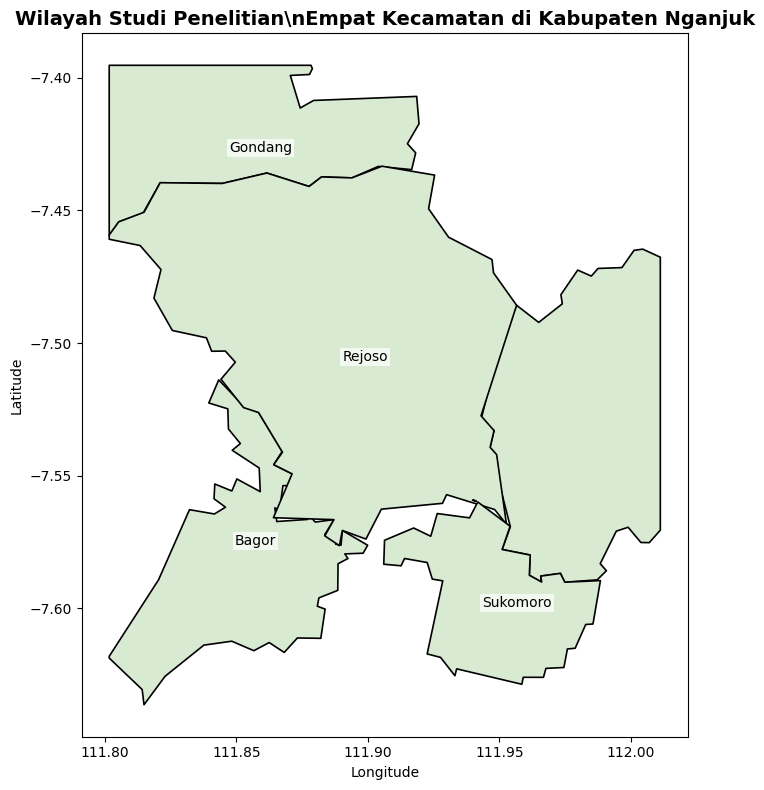

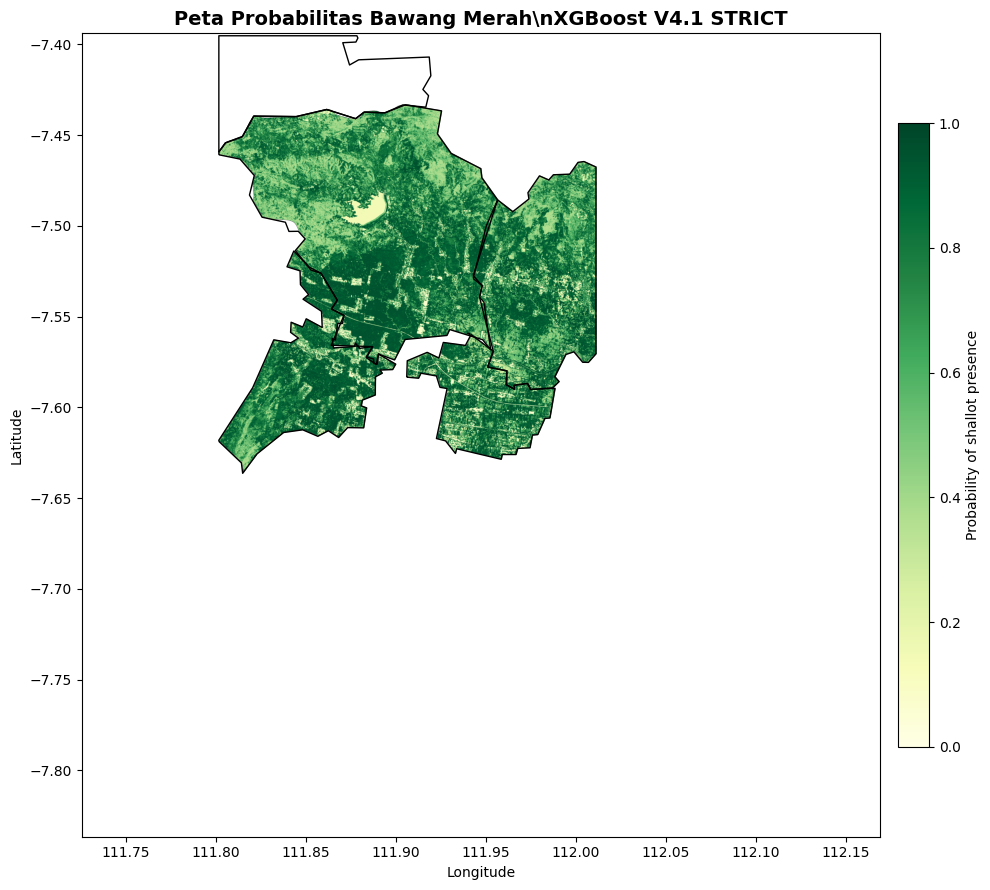

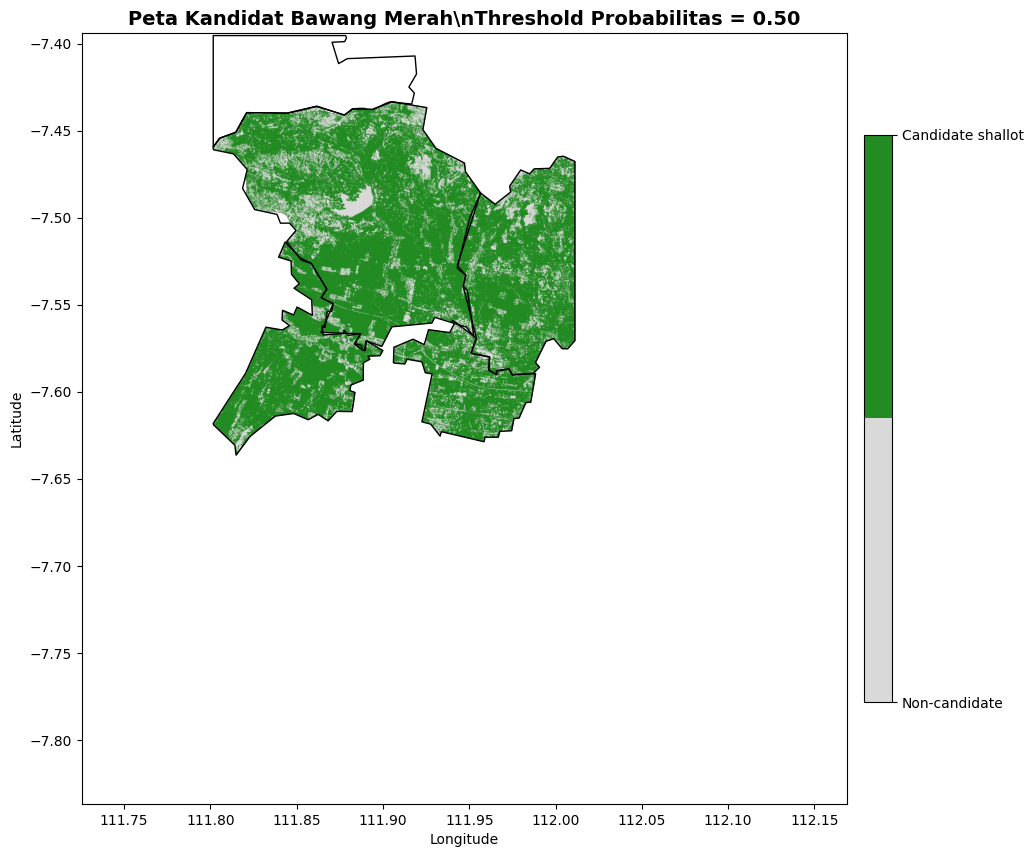

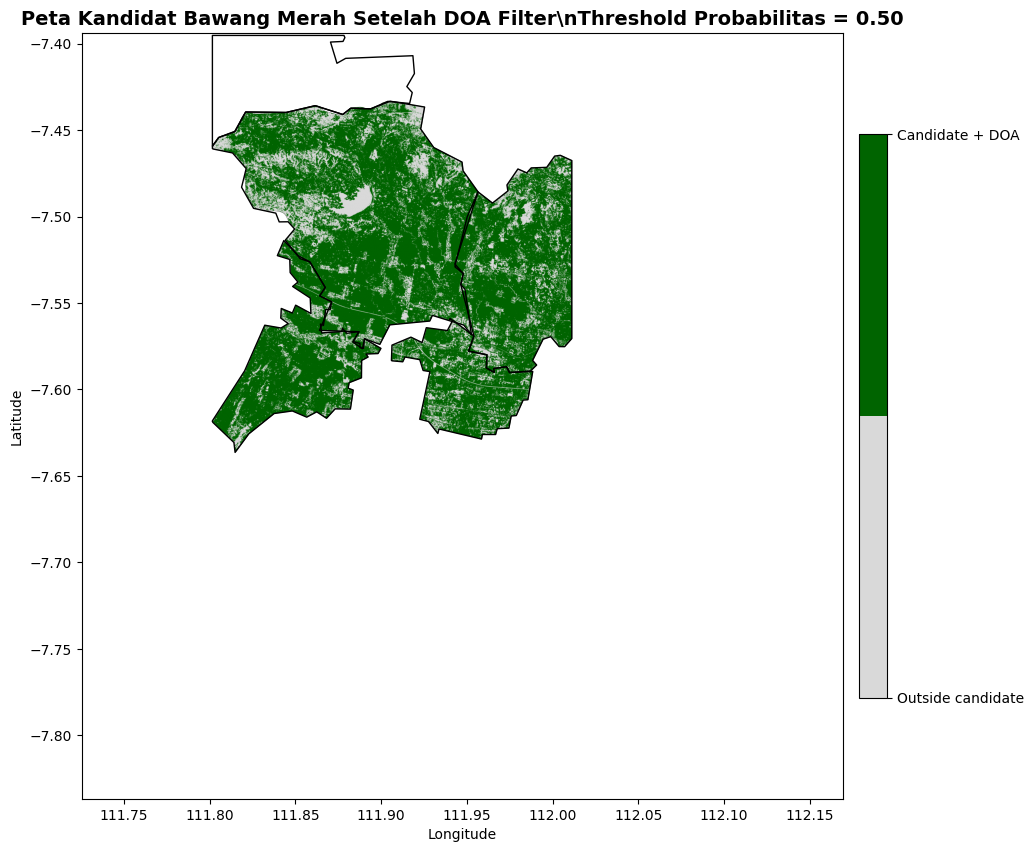

Kolom pada file area DOA:
['Kecamatan', 'Valid_Area_Ha', 'DOA_Support_Area_Ha', 'DOA_Support_Percent', 'XGB_Only_Ha_T0_5', 'DOA_Filtered_Ha_T0_5', 'DOA_Filtered_Percent_T0_5', 'XGB_Only_Ha_T0_6', 'DOA_Filtered_Ha_T0_6', 'DOA_Filtered_Percent_T0_6', 'XGB_Only_Ha_T0_7', 'DOA_Filtered_Ha_T0_7', 'DOA_Filtered_Percent_T0_7']

Data yang akan divisualisasikan:


,Kecamatan,XGB_Only_Ha,XGB_DOA_Ha
0,Bagor,4591.06,4522.18
1,Gondang,6355.45,6203.23
2,Rejoso,12975.04,12477.38
3,Sukomoro,2932.89,2844.53


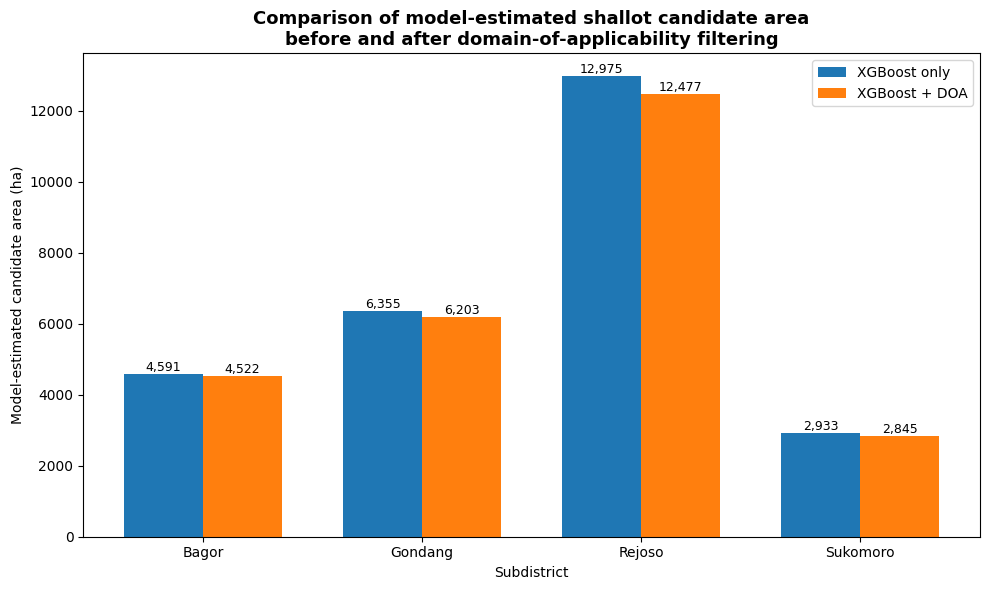


Figure 5 tersimpan:
/content/drive/MyDrive/GEE/XGBOOST_V4_1/FIGURES_PAPER/Figure_5_Area_Comparison_XGB_vs_DOA_T050.png
SEMUA FIGURE TERSIMPAN
Figure 1: /content/drive/MyDrive/GEE/XGBOOST_V4_1/FIGURES_PAPER/Figure_1_Study_Area_4Kecamatan.png
Figure 2: /content/drive/MyDrive/GEE/XGBOOST_V4_1/FIGURES_PAPER/Figure_2_Probability_Map_XGBoost_V4_1_STRICT.png
Figure 3: /content/drive/MyDrive/GEE/XGBOOST_V4_1/FIGURES_PAPER/Figure_3_Binary_Candidate_Map_T050.png
Figure 4: /content/drive/MyDrive/GEE/XGBOOST_V4_1/FIGURES_PAPER/Figure_4_DOA_Filtered_Candidate_Map_T050.png
Figure 5: /content/drive/MyDrive/GEE/XGBOOST_V4_1/FIGURES_PAPER/Figure_5_Area_Comparison_XGB_vs_DOA_T050.png


In [ ]:
# ============================================================
# VISUALISASI HASIL PENELITIAN
# PETA BAWANG MERAH NGANJUK
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT
# ------------------------------------------------------------
import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# ------------------------------------------------------------
# 2. PATH
# ------------------------------------------------------------
BASE_DIR = Path("/content/drive/MyDrive/GEE")
OFFICIAL_DIR = BASE_DIR / "OFFICIAL_DATA_2025"
MODEL_DIR = BASE_DIR / "XGBOOST_V4_1"
FIG_DIR = MODEL_DIR / "FIGURES_PAPER"

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BOUNDARY_PATH = (
    OFFICIAL_DIR /
    "Batas_4_Kecamatan_Nganjuk.geojson"
)

PROBABILITY_RASTER = (
    MODEL_DIR /
    "Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif"
)

BINARY_RASTER = (
    MODEL_DIR /
    "Binary_Bawang_Nganjuk_4Kec_V4_1_STRICT_T050.tif"
)

DOA_BINARY_RASTER = (
    MODEL_DIR /
    "Candidate_Bawang_DOA_T050_V4_1.tif"
)

AREA_XGB_PATH = (
    MODEL_DIR /
    "Area_Bawang_Per_Kecamatan_V4_1_STRICT.csv"
)

AREA_DOA_PATH = (
    MODEL_DIR /
    "Area_Candidate_Bawang_DOA_V4_1.csv"
)


# ------------------------------------------------------------
# 3. VALIDASI FILE
# ------------------------------------------------------------
required_files = {
    "Boundary": BOUNDARY_PATH,
    "Probability raster": PROBABILITY_RASTER,
    "Binary raster": BINARY_RASTER,
    "DOA raster": DOA_BINARY_RASTER,
    "Area XGB": AREA_XGB_PATH,
    "Area DOA": AREA_DOA_PATH,
}

print("==============================================")
print("VALIDASI FILE INPUT")
print("==============================================")

for name, path in required_files.items():
    status = "OK" if path.exists() else "MISSING"
    print(f"{name:22s}: {status} -> {path}")

missing = [
    str(path)
    for path in required_files.values()
    if not path.exists()
]

if len(missing) > 0:
    raise FileNotFoundError(
        "Ada file yang belum tersedia:\\n" + "\\n".join(missing)
    )


# ------------------------------------------------------------
# 4. LOAD BOUNDARY
# ------------------------------------------------------------
boundary = gpd.read_file(BOUNDARY_PATH)
boundary = boundary.to_crs("EPSG:4326")

print("\nKecamatan pada boundary:")
print(boundary["Kecamatan"].tolist())


# ------------------------------------------------------------
# 5. HELPER FUNCTION
# ------------------------------------------------------------
def read_raster_masked(raster_path):
    """
    Membaca raster band 1 dan mengubah nodata menjadi NaN.
    Mengembalikan array, extent, profile, dan transform.
    """
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        transform = src.transform
        bounds = src.bounds
        profile = src.profile

        if nodata is not None:
            arr[arr == nodata] = np.nan

        extent = [
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]

    return arr, extent, profile, transform


def add_kecamatan_labels(ax, gdf, label_col="Kecamatan", fontsize=10):
    """
    Menambahkan label nama kecamatan ke peta.
    """
    for _, row in gdf.iterrows():
        point = row.geometry.representative_point()
        ax.text(
            point.x,
            point.y,
            str(row[label_col]),
            fontsize=fontsize,
            ha="center",
            va="center",
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="none",
                pad=1.5
            )
        )


def style_axes_map(ax):
    """
    Styling umum untuk peta.
    """
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(False)


# ------------------------------------------------------------
# 6. FIGURE 1
# PETA WILAYAH STUDI
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

boundary.plot(
    ax=ax,
    edgecolor="black",
    facecolor="#D9EAD3",
    linewidth=1.2
)

add_kecamatan_labels(
    ax,
    boundary,
    fontsize=10
)

style_axes_map(ax)

ax.set_title(
    "Wilayah Studi Penelitian\\nEmpat Kecamatan di Kabupaten Nganjuk",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

fig_path_1 = FIG_DIR / "Figure_1_Study_Area_4Kecamatan.png"
plt.savefig(
    fig_path_1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. FIGURE 2
# PETA PROBABILITAS BAWANG MERAH
# ------------------------------------------------------------
prob_arr, prob_extent, _, _ = read_raster_masked(PROBABILITY_RASTER)

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(
    prob_arr,
    extent=prob_extent,
    origin="upper",
    cmap="YlGn",
    vmin=0,
    vmax=1
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.0
)

style_axes_map(ax)

ax.set_title(
    "Peta Probabilitas Bawang Merah\\nXGBoost V4.1 STRICT",
    fontsize=14,
    fontweight="bold"
)

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "Probability of shallot presence"
)

plt.tight_layout()

fig_path_2 = FIG_DIR / "Figure_2_Probability_Map_XGBoost_V4_1_STRICT.png"
plt.savefig(
    fig_path_2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. FIGURE 3
# PETA KANDIDAT BAWANG MERAH BINER T=0.50
# ------------------------------------------------------------
bin_arr, bin_extent, _, _ = read_raster_masked(BINARY_RASTER)

bin_cmap = ListedColormap([
    "#D9D9D9",  # bukan kandidat
    "#228B22"   # kandidat bawang
])

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(
    bin_arr,
    extent=bin_extent,
    origin="upper",
    cmap=bin_cmap,
    vmin=0,
    vmax=1
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.0
)

style_axes_map(ax)

ax.set_title(
    "Peta Kandidat Bawang Merah\\nThreshold Probabilitas = 0.50",
    fontsize=14,
    fontweight="bold"
)

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.02,
    ticks=[0, 1]
)

cbar.ax.set_yticklabels([
    "Non-candidate",
    "Candidate shallot"
])

plt.tight_layout()

fig_path_3 = FIG_DIR / "Figure_3_Binary_Candidate_Map_T050.png"
plt.savefig(
    fig_path_3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9. FIGURE 4
# PETA KANDIDAT SETELAH DOA FILTER
# ------------------------------------------------------------
doa_arr, doa_extent, _, _ = read_raster_masked(DOA_BINARY_RASTER)

doa_cmap = ListedColormap([
    "#D9D9D9",  # di luar kandidat
    "#006400"   # kandidat setelah DOA
])

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(
    doa_arr,
    extent=doa_extent,
    origin="upper",
    cmap=doa_cmap,
    vmin=0,
    vmax=1
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.0
)

style_axes_map(ax)

ax.set_title(
    "Peta Kandidat Bawang Merah Setelah DOA Filter\\nThreshold Probabilitas = 0.50",
    fontsize=14,
    fontweight="bold"
)

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.02,
    ticks=[0, 1]
)

cbar.ax.set_yticklabels([
    "Outside candidate",
    "Candidate + DOA"
])

plt.tight_layout()

fig_path_4 = FIG_DIR / "Figure_4_DOA_Filtered_Candidate_Map_T050.png"
plt.savefig(
    fig_path_4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 5
# PERBANDINGAN LUAS KANDIDAT:
# XGBOOST ONLY VS XGBOOST + DOA
# ============================================================

# ------------------------------------------------------------
# 1. LOAD AREA DOA TABLE
# ------------------------------------------------------------

area_doa = pd.read_csv(
    AREA_DOA_PATH
)


print(
    "Kolom pada file area DOA:"
)

print(
    area_doa.columns.tolist()
)


# ------------------------------------------------------------
# 2. HAPUS BARIS TOTAL
# ------------------------------------------------------------

plot_df = (
    area_doa[
        area_doa[
            "Kecamatan"
        ]
        !=
        "TOTAL_4_KECAMATAN"
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. PILIH DATA T0.50
# ------------------------------------------------------------

required_columns = [

    "Kecamatan",

    "XGB_Only_Ha_T0_5",

    "DOA_Filtered_Ha_T0_5"
]


missing_columns = [

    col

    for col in required_columns

    if col not in plot_df.columns
]


if len(
    missing_columns
) > 0:

    raise KeyError(

        "Kolom berikut tidak ditemukan: "
        +
        str(
            missing_columns
        )
        +
        "\nKolom tersedia: "
        +
        str(
            plot_df.columns.tolist()
        )
    )


plot_df = (
    plot_df[
        required_columns
    ]
    .copy()
)


plot_df.columns = [

    "Kecamatan",

    "XGB_Only_Ha",

    "XGB_DOA_Ha"
]


# ------------------------------------------------------------
# 4. URUTKAN KECAMATAN
# ------------------------------------------------------------

district_order = [

    "Bagor",

    "Gondang",

    "Rejoso",

    "Sukomoro"
]


plot_df[
    "Kecamatan"
] = pd.Categorical(

    plot_df[
        "Kecamatan"
    ],

    categories=district_order,

    ordered=True
)


plot_df = (
    plot_df
    .sort_values(
        "Kecamatan"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nData yang akan divisualisasikan:"
)


display(
    plot_df.round(
        2
    )
)


# ------------------------------------------------------------
# 5. BAR CHART
# ------------------------------------------------------------

x = np.arange(
    len(
        plot_df
    )
)


width = (
    0.36
)


fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)


bars_xgb = ax.bar(

    x
    -
    width / 2,

    plot_df[
        "XGB_Only_Ha"
    ],

    width,

    label="XGBoost only"
)


bars_doa = ax.bar(

    x
    +
    width / 2,

    plot_df[
        "XGB_DOA_Ha"
    ],

    width,

    label="XGBoost + DOA"
)


# ------------------------------------------------------------
# 6. LABEL AXIS
# ------------------------------------------------------------

ax.set_xticks(
    x
)


ax.set_xticklabels(

    plot_df[
        "Kecamatan"
    ]
    .astype(str)
)


ax.set_xlabel(
    "Subdistrict"
)


ax.set_ylabel(
    "Model-estimated candidate area (ha)"
)


ax.set_title(

    "Comparison of model-estimated shallot candidate area\n"
    "before and after domain-of-applicability filtering",

    fontsize=13,

    fontweight="bold"
)


ax.legend()


# ------------------------------------------------------------
# 7. ANGKA DI ATAS BAR
# ------------------------------------------------------------

for bar in bars_xgb:

    height = (
        bar.get_height()
    )


    ax.text(

        bar.get_x()
        +
        bar.get_width()
        /
        2,

        height,

        f"{height:,.0f}",

        ha="center",

        va="bottom",

        fontsize=9
    )


for bar in bars_doa:

    height = (
        bar.get_height()
    )


    ax.text(

        bar.get_x()
        +
        bar.get_width()
        /
        2,

        height,

        f"{height:,.0f}",

        ha="center",

        va="bottom",

        fontsize=9
    )


# ------------------------------------------------------------
# 8. FINALIZE
# ------------------------------------------------------------

plt.tight_layout()


fig_path_5 = (

    FIG_DIR

    /

    "Figure_5_Area_Comparison_XGB_vs_DOA_T050.png"
)


plt.savefig(

    fig_path_5,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "\nFigure 5 tersimpan:"
)


print(
    fig_path_5
)

# ------------------------------------------------------------
# 12. RINGKASAN OUTPUT FIGURE
# ------------------------------------------------------------
print("==============================================")
print("SEMUA FIGURE TERSIMPAN")
print("==============================================")
print("Figure 1:", fig_path_1)
print("Figure 2:", fig_path_2)
print("Figure 3:", fig_path_3)
print("Figure 4:", fig_path_4)
print("Figure 5:", fig_path_5)

In [ ]:
import os

path = "/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025/Batas_4_Kecamatan_Nganjuk.geojson"

print("Ada:", os.path.exists(path))
print(path)

Ada: True
/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025/Batas_4_Kecamatan_Nganjuk.geojson


In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/GEE/OFFICIAL_DATA_2025/Batas_4_Kecamatan_Nganjuk.geojson"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== INFORMASI RASTER ===
CRS     : EPSG:4326
Ukuran  : 4940 x 4928
NoData  : -9999.0
Bounds  : BoundingBox(left=111.72535834804154, bottom=-7.836633044073469, right=112.16912609839659, top=-7.393943272059369)

Piksel valid : 3364570
Piksel total : 24344320


/tmp/ipykernel_2227/3268337295.py:133: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(



PNG berhasil dibuat:
/content/probability_map.png

=== LEAFLET BOUNDS ===
[
  [
    -7.836633044073469,
    111.72535834804154
  ],
  [
    -7.393943272059369,
    112.16912609839659
  ]
]

Copy ke map.js:
const RASTER_BOUNDS = [[-7.836633044073469, 111.72535834804154], [-7.393943272059369, 112.16912609839659]];


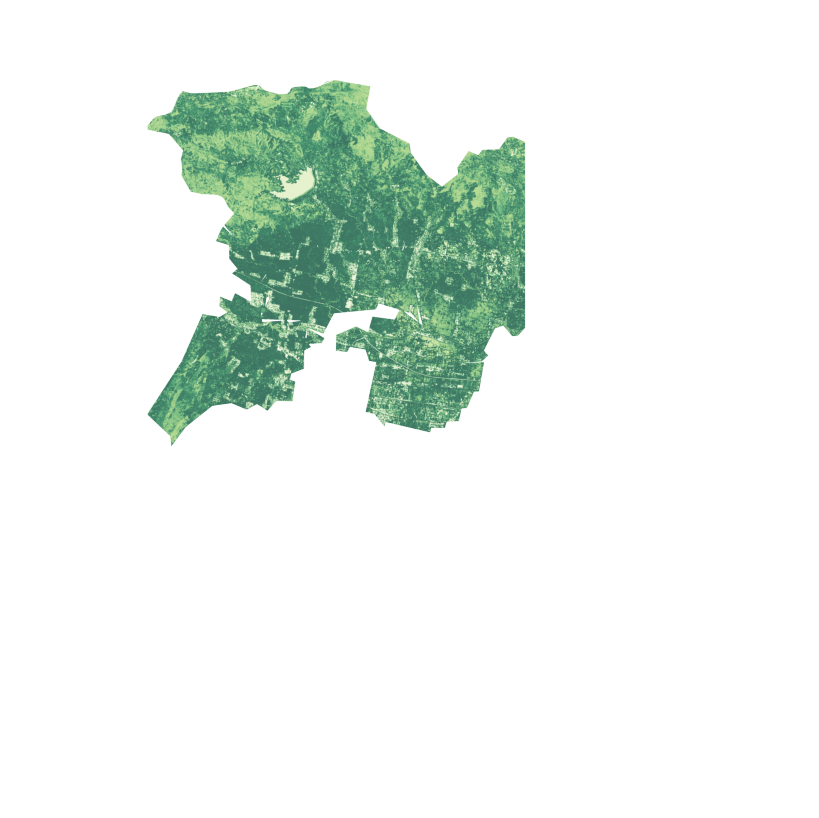

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# EXPORT PROBABILITY MAP UNTUK LEAFLET
# Output: probability_map.png
# ============================================================

!pip install -q rasterio pillow matplotlib

import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt

from PIL import Image
from matplotlib.colors import LinearSegmentedColormap
from google.colab import files


# ------------------------------------------------------------
# 1. PATH
# ------------------------------------------------------------

INPUT_TIF = (
    "/content/drive/MyDrive/GEE/XGBOOST_V4_1/"
    "Probability_Bawang_Nganjuk_4Kec_V4_1_STRICT.tif"
)

OUTPUT_PNG = "/content/probability_map.png"


# ------------------------------------------------------------
# 2. BACA RASTER
# ------------------------------------------------------------

with rasterio.open(INPUT_TIF) as src:
    probability = src.read(1).astype(np.float32)

    bounds = src.bounds
    nodata = src.nodata
    crs = src.crs
    width = src.width
    height = src.height


print("=== INFORMASI RASTER ===")
print("CRS     :", crs)
print("Ukuran  :", width, "x", height)
print("NoData  :", nodata)
print("Bounds  :", bounds)


# ------------------------------------------------------------
# 3. MASK PIKSEL INVALID
# ------------------------------------------------------------

valid_mask = np.isfinite(probability)

if nodata is not None:
    valid_mask &= probability != nodata

# Probabilitas seharusnya 0-1
valid_mask &= probability >= 0
valid_mask &= probability <= 1


print("\nPiksel valid :", int(valid_mask.sum()))
print("Piksel total :", probability.size)

if valid_mask.sum() == 0:
    raise RuntimeError("Tidak ada piksel probabilitas yang valid.")


# ------------------------------------------------------------
# 4. BATASI NILAI KE 0-1
# ------------------------------------------------------------

probability_clean = np.clip(
    probability,
    0.0,
    1.0
)


# ------------------------------------------------------------
# 5. COLORMAP SHALLotWATCH
# ------------------------------------------------------------

colors = [
    "#f5f7e8",
    "#d9edb3",
    "#9dce72",
    "#4da866",
    "#16764d",
    "#0d4938"
]

cmap = LinearSegmentedColormap.from_list(
    "shallotwatch_probability",
    colors,
    N=256
)


# ------------------------------------------------------------
# 6. UBAH PROBABILITAS MENJADI RGBA
# ------------------------------------------------------------

rgba = cmap(
    probability_clean
)

# 0-1 -> 0-255
rgba = (
    rgba * 255
).astype(np.uint8)


# ------------------------------------------------------------
# 7. TRANSPARANSI
# ------------------------------------------------------------

# Area di luar raster valid benar-benar transparan
rgba[..., 3] = np.where(
    valid_mask,
    205,
    0
).astype(np.uint8)


# ------------------------------------------------------------
# 8. SIMPAN PNG
# ------------------------------------------------------------

image = Image.fromarray(
    rgba,
    mode="RGBA"
)

image.save(
    OUTPUT_PNG,
    optimize=True
)


print("\nPNG berhasil dibuat:")
print(OUTPUT_PNG)


# ------------------------------------------------------------
# 9. BOUNDS UNTUK LEAFLET
# ------------------------------------------------------------

leaflet_bounds = [
    [bounds.bottom, bounds.left],
    [bounds.top, bounds.right]
]


print("\n=== LEAFLET BOUNDS ===")
print(
    json.dumps(
        leaflet_bounds,
        indent=2
    )
)


print("\nCopy ke map.js:")
print(
    "const RASTER_BOUNDS = "
    + json.dumps(leaflet_bounds)
    + ";"
)


# ------------------------------------------------------------
# 10. PREVIEW
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 8)
)

plt.imshow(
    rgba
)

plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


# ------------------------------------------------------------
# 11. DOWNLOAD
# ------------------------------------------------------------

files.download(
    OUTPUT_PNG
)

In [ ]:
# ============================================================
# EXPORT CANDIDATE T=0.50 UNTUK LEAFLET
# Output: candidate_t050.png
# ============================================================

!pip install -q rasterio pillow

import os
import numpy as np
import rasterio

from PIL import Image
from google.colab import files


# ============================================================
# 1. PATH
# ============================================================

INPUT_TIF = (
    "/content/drive/MyDrive/GEE/XGBOOST_V4_1/"
    "Binary_Bawang_Nganjuk_4Kec_V4_1_STRICT_T050.tif"
)

OUTPUT_PNG = "/content/candidate_t050.png"


# ============================================================
# 2. CEK FILE
# ============================================================

if not os.path.exists(INPUT_TIF):
    raise FileNotFoundError(
        f"Raster tidak ditemukan:\n{INPUT_TIF}"
    )


# ============================================================
# 3. BACA RASTER
# ============================================================

with rasterio.open(INPUT_TIF) as src:
    candidate = src.read(1)

    bounds = src.bounds
    crs = src.crs
    nodata = src.nodata
    width = src.width
    height = src.height


print("=== INFORMASI RASTER ===")
print("CRS    :", crs)
print("Ukuran :", width, "x", height)
print("NoData :", nodata)
print("Bounds :", bounds)


# ============================================================
# 4. CEK NILAI RASTER
# ============================================================

unique_values = np.unique(candidate)

print("\nNilai raster:")
print(unique_values[:20])


# ============================================================
# 5. MASK KANDIDAT
# ============================================================
#
# Raster binary:
#
# 1 = kandidat bawang merah
# 0 = bukan kandidat
#
# Untuk WebGIS:
# kandidat     -> hijau
# non-kandidat -> transparan
#

candidate_mask = candidate == 1


print(
    "\nJumlah piksel kandidat:",
    int(candidate_mask.sum())
)

print(
    "Jumlah seluruh piksel:",
    candidate.size
)


# ============================================================
# 6. BUAT IMAGE RGBA TRANSPARAN
# ============================================================

rgba = np.zeros(
    (
        height,
        width,
        4
    ),
    dtype=np.uint8
)


# ============================================================
# 7. WARNA KANDIDAT
# ============================================================
#
# Hijau ShallotWatch
# RGB = 47, 133, 90
#
# Alpha 210 agar basemap masih sedikit terlihat.
#

rgba[
    candidate_mask,
    0
] = 47

rgba[
    candidate_mask,
    1
] = 133

rgba[
    candidate_mask,
    2
] = 90

rgba[
    candidate_mask,
    3
] = 210


# ============================================================
# 8. SIMPAN PNG
# ============================================================

image = Image.fromarray(
    rgba,
    mode="RGBA"
)

image.save(
    OUTPUT_PNG,
    optimize=True
)


# ============================================================
# 9. INFORMASI OUTPUT
# ============================================================

print("\nPNG berhasil dibuat:")
print(OUTPUT_PNG)

print(
    "Ukuran PNG:",
    width,
    "x",
    height
)


print("\nBounds Leaflet:")

print([
    [
        bounds.bottom,
        bounds.left
    ],
    [
        bounds.top,
        bounds.right
    ]
])


# ============================================================
# 10. VALIDASI BOUNDS
# ============================================================

EXPECTED_BOUNDS = [
    [-7.836633044073469, 111.72535834804154],
    [-7.393943272059369, 112.16912609839659]
]

actual_bounds = [
    [
        bounds.bottom,
        bounds.left
    ],
    [
        bounds.top,
        bounds.right
    ]
]


if np.allclose(
    np.array(actual_bounds),
    np.array(EXPECTED_BOUNDS),
    atol=1e-8
):
    print("\nBounds cocok dengan probability_map.png.")

else:
    print("\nPERINGATAN:")
    print("Bounds raster candidate berbeda.")
    print("Actual :", actual_bounds)
    print("Expected:", EXPECTED_BOUNDS)


# ============================================================
# 11. DOWNLOAD
# ============================================================

files.download(
    OUTPUT_PNG
)

=== INFORMASI RASTER ===
CRS    : EPSG:4326
Ukuran : 4940 x 4928
NoData : 255.0
Bounds : BoundingBox(left=111.72535834804154, bottom=-7.836633044073469, right=112.16912609839659, top=-7.393943272059369)

Nilai raster:
[  0   1 255]

Jumlah piksel kandidat: 2719077
Jumlah seluruh piksel: 24344320


/tmp/ipykernel_2227/2586213291.py:146: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(



PNG berhasil dibuat:
/content/candidate_t050.png
Ukuran PNG: 4940 x 4928

Bounds Leaflet:
[[-7.836633044073469, 111.72535834804154], [-7.393943272059369, 112.16912609839659]]

Bounds cocok dengan probability_map.png.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>